<a href="https://colab.research.google.com/github/photon2563/Agentic-AI-Based-Dynamic-Tariff-Optimization-for-EV-Charging-Networks/blob/main/EV_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install lightgbm xgboost networkx shap tqdm -q

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from tqdm import tqdm

import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
import lightgbm as lgb

import shap

In [5]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)

plt.style.use('ggplot')
PROJECT_DIR = '/content/drive/MyDrive'

In [6]:
from pathlib import Path

BASE_DIR = Path(PROJECT_DIR)

OUTPUT_DIR = BASE_DIR / 'outputs'
FIG_DIR = BASE_DIR / 'figures'
MODEL_DIR = BASE_DIR / 'models'

OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

In [7]:
adj = pd.read_csv(BASE_DIR / 'adj.csv', index_col=0)
distance = pd.read_csv(BASE_DIR / 'distance.csv', index_col=0)
duration = pd.read_csv(BASE_DIR / 'duration.csv', index_col=0)
information = pd.read_csv(BASE_DIR / 'information.csv')
occupancy = pd.read_csv(BASE_DIR / 'occupancy.csv', index_col=0)
price = pd.read_csv(BASE_DIR / 'price.csv', index_col=0)
stations = pd.read_csv(BASE_DIR / 'stations.csv')
time_df = pd.read_csv(BASE_DIR / 'time.csv')
volume = pd.read_csv(BASE_DIR / 'volume.csv', index_col=0)
acn_sessions = pd.read_excel(BASE_DIR / 'acndata_sessions.json.xlsx')

In [8]:
datasets = {
    'adj': adj,
    'distance': distance,
    'duration': duration,
    'information': information,
    'occupancy': occupancy,
    'price': price,
    'stations': stations,
    'time_df': time_df,
    'volume': volume,
    'acn_sessions': acn_sessions
}

for name, df in datasets.items():
    print('='*70)
    print(name.upper())
    print('='*70)

    print('Shape:', df.shape)
    print('\nColumns:')
    print(df.columns.tolist())

    print('\nHead:')
    display(df.head())
    print('\nMissing values:')
    print(df.isnull().sum().sort_values(ascending=False).head())
    print('\n')

ADJ
Shape: (247, 247)

Columns:
['102', '105', '107', '108', '109', '110', '111', '115', '123', '124', '202', '204', '205', '206', '208', '215', '216', '217', '223', '224', '225', '226', '227', '235', '307', '309', '320', '322', '323', '324', '325', '326', '328', '329', '330', '331', '332', '333', '335', '340', '343', '346', '347', '348', '406', '408', '501', '502', '506', '512', '513', '519', '520', '522', '525', '526', '527', '529', '552', '570', '576', '577', '580', '584', '585', '587', '588', '589', '594', '595', '596', '598', '627', '628', '630', '631', '632', '633', '636', '638', '643', '644', '655', '656', '681', '682', '686', '690', '691', '693', '698', '699', '700', '701', '702', '703', '704', '705', '706', '708', '709', '710', '711', '712', '715', '716', '719', '724', '728', '729', '732', '733', '735', '737', '739', '741', '744', '745', '746', '751', '771', '773', '775', '781', '783', '784', '790', '795', '799', '802', '804', '831', '832', '835', '842', '848', '849', '851', '

,102,105,107,108,109,110,111,115,123,124,202,204,205,206,208,215,216,217,223,224,225,226,227,235,307,309,320,322,323,324,325,326,328,329,330,331,332,333,335,340,343,346,347,348,406,408,501,502,506,512,513,519,520,522,525,526,527,529,552,570,576,577,580,584,585,587,588,589,594,595,596,598,627,628,630,631,632,633,636,638,643,644,655,656,681,682,686,690,691,693,698,699,700,701,702,703,704,705,706,708,...,893,895,897,900,901,902,903,904,937,965,966,967,969,972,974,975,979,982,983,986,987,988,989,991,996,998,1000,1009,1011,1015,1026,1029,1031,1032,1037,1043,1049,1060,1061,1062,1066,1067,1068,1071,1072,1074,1075,1076,1081,1082,1083,1085,1086,1088,1090,1092,1093,1095,1096,1098,1099,1100,1101,1102,1104,1105,1106,1107,1109,1110,1111,1112,1113,1114,1115,1119,1121,1122,1124,1126,1131,1134,1137,1138,1143,1144,1149,1154,1156,1159,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
node_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
102,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
105,0,1,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
107,0,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
108,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
109,0,0,0,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Missing values:
102    0
105    0
107    0
108    0
109    0
dtype: int64


DISTANCE
Shape: (247, 247)

Columns:
['102', '105', '107', '108', '109', '110', '111', '115', '123', '124', '202', '204', '205', '206', '208', '215', '216', '217', '223', '224', '225', '226', '227', '235', '307', '309', '320', '322', '323', '324', '325', '326', '328', '329', '330', '331', '332', '333', '335', '340', '343', '346', '347', '348', '406', '408', '501', '502', '506', '512', '513', '519', '520', '522', '525', '526', '527', '529', '552', '570', '576', '577', '580', '584', '585', '587', '588', '589', '594', '595', '596', '598', '627', '628', '630', '631', '632', '633', '636', '638', '643', '644', '655', '656', '681', '682', '686', '690', '691', '693', '698', '699', '700', '701', '702', '703', '704', '705', '706', '708', '709', '710', '711', '712', '715', '716', '719', '724', '728', '729', '732', '733', '735', '737', '739', '741', '744', '745', '746', '751', '771', '773', '775', '781', '783', '784', '79

,102,105,107,108,109,110,111,115,123,124,202,204,205,206,208,215,216,217,223,224,225,226,227,235,307,309,320,322,323,324,325,326,328,329,330,331,332,333,335,340,343,346,347,348,406,408,501,502,506,512,513,519,520,522,525,526,527,529,552,570,576,577,580,584,585,587,588,589,594,595,596,598,627,628,630,631,632,633,636,638,643,644,655,656,681,682,686,690,691,693,698,699,700,701,702,703,704,705,706,708,...,893,895,897,900,901,902,903,904,937,965,966,967,969,972,974,975,979,982,983,986,987,988,989,991,996,998,1000,1009,1011,1015,1026,1029,1031,1032,1037,1043,1049,1060,1061,1062,1066,1067,1068,1071,1072,1074,1075,1076,1081,1082,1083,1085,1086,1088,1090,1092,1093,1095,1096,1098,1099,1100,1101,1102,1104,1105,1106,1107,1109,1110,1111,1112,1113,1114,1115,1119,1121,1122,1124,1126,1131,1134,1137,1138,1143,1144,1149,1154,1156,1159,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.93143,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,1.216116,1.142223,0.000000,0.000000,1.563217,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.314398,0.0,0.00000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.216116,0.000000,1.021749,0.000000,1.415775,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.142223,1.021749,0.000000,1.608976,1.342053,1.146887,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.


Missing values:
102    0
105    0
107    0
108    0
109    0
dtype: int64


DURATION
Shape: (8640, 247)

Columns:
['102', '105', '107', '108', '109', '110', '111', '115', '123', '124', '202', '204', '205', '206', '208', '215', '216', '217', '223', '224', '225', '226', '227', '235', '307', '309', '320', '322', '323', '324', '325', '326', '328', '329', '330', '331', '332', '333', '335', '340', '343', '346', '347', '348', '406', '408', '501', '502', '506', '512', '513', '519', '520', '522', '525', '526', '527', '529', '552', '570', '576', '577', '580', '584', '585', '587', '588', '589', '594', '595', '596', '598', '627', '628', '630', '631', '632', '633', '636', '638', '643', '644', '655', '656', '681', '682', '686', '690', '691', '693', '698', '699', '700', '701', '702', '703', '704', '705', '706', '708', '709', '710', '711', '712', '715', '716', '719', '724', '728', '729', '732', '733', '735', '737', '739', '741', '744', '745', '746', '751', '771', '773', '775', '781', '783', '784', '7

...


Missing values:
month     0
day       0
year      0
hour      0
minute    0
dtype: int64


VOLUME
Shape: (8640, 247)

Columns:
['102', '105', '107', '108', '109', '110', '111', '115', '123', '124', '202', '204', '205', '206', '208', '215', '216', '217', '223', '224', '225', '226', '227', '235', '307', '309', '320', '322', '323', '324', '325', '326', '328', '329', '330', '331', '332', '333', '335', '340', '343', '346', '347', '348', '406', '408', '501', '502', '506', '512', '513', '519', '520', '522', '525', '526', '527', '529', '552', '570', '576', '577', '580', '584', '585', '587', '588', '589', '594', '595', '596', '598', '627', '628', '630', '631', '632', '633', '636', '638', '643', '644', '655', '656', '681', '682', '686', '690', '691', '693', '698', '699', '700', '701', '702', '703', '704', '705', '706', '708', '709', '710', '711', '712', '715', '716', '719', '724', '728', '729', '732', '733', '735', '737', '739', '741', '744', '745', '746', '751', '771', '773', '775', '781', '78

,102,105,107,108,109,110,111,115,123,124,202,204,205,206,208,215,216,217,223,224,225,226,227,235,307,309,320,322,323,324,325,326,328,329,330,331,332,333,335,340,343,346,347,348,406,408,501,502,506,512,513,519,520,522,525,526,527,529,552,570,576,577,580,584,585,587,588,589,594,595,596,598,627,628,630,631,632,633,636,638,643,644,655,656,681,682,686,690,691,693,698,699,700,701,702,703,704,705,706,708,...,893,895,897,900,901,902,903,904,937,965,966,967,969,972,974,975,979,982,983,986,987,988,989,991,996,998,1000,1009,1011,1015,1026,1029,1031,1032,1037,1043,1049,1060,1061,1062,1066,1067,1068,1071,1072,1074,1075,1076,1081,1082,1083,1085,1086,1088,1090,1092,1093,1095,1096,1098,1099,1100,1101,1102,1104,1105,1106,1107,1109,1110,1111,1112,1113,1114,1115,1119,1121,1122,1124,1126,1131,1134,1137,1138,1143,1144,1149,1154,1156,1159,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2.858333,5.907222,6.478889,5.145,2.286667,3.048889,5.526111,0.381111,0.762222,3.811111,2.286667,1.905556,1.143333,2.667778,1.905556,1.143333,2.286667,6.478889,9.337222,6.288333,1.905556,2.096111,7.622222,5.335556,15.435000,2.286667,0.381111,23.030000,1.524444,4.001667,5.934444,1.905556,11.814444,28.011667,3.048889,8.003333,16.197222,159.358889,30.298333,0.381111,0.0,8.057778,0.381111,28.474444,1.143333,4.954444,9.337222,11.623889,10.671111,5.145,34.681111,61.522222,16.877778,25.915556,9.337222,25.725000,15.816111,4.954444,8.003333,7.241111,352.527778,2.667778,49.816667,5.335556,1.524444,18.483889,20.008333,38.383333,3.43,604.333333,1.905556,1.524444,19.6,16.333333,0.0,1.524444,4.192222,430.220000,8.166667,0.0,0.762222,3.43,0.0,3.43,0.381111,177.543333,3.048889,251.914444,9.908889,46.168889,1.333889,14.373333,7.622222,0.381111,0.762222,25.915556,20.961111,3.92,3.239444,167.743333,...,0.762222,71.866667,1.715,0.762222,0.381111,74.153333,6.097778,4.573333,0.381111,31.060556,34.109444,2.286667,7.241111,11.814444,32.775556,2.286667,1.524444,4.573333,0.381111,17.150000,0.0,6.669444,11.814444,1.333889,23.438333,129.223889,16.197222,20.198889,26.868333,9.527778,188.976667,45.733333,27.140556,0.0,2.667778,6.097778,51.45,0.762222,9.337222,3.048889,3.239444,5.716667,17.748889,10.861667,0.381111,5.335556,2.286667,14.482222,1.905556,0.0,8.003333,5.907222,0.762222,23.383889,0.762222,0.571667,0.0,4.192222,4.382778,31.033333,0.762222,4.573333,0.762222,5.716667,1.715,0.571667,1.143333,0.190556,1.524444,1.905556,4.573333,2.286667,0.0,1.524444,3.811111,4.573333,5.907222,1.524444,105.676667,1.905556,357.808889,2.286667,202.315556,0.762222,0.0,2.858333,4.192222,0.762222,0.0,11.433333,0.0,2.286667,0.381111,12.195556,8.956111,240.236111,5.335556,0.381111,2.286667,2.096111
2,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,5.833333,3.500000,2.916667,1.750000,4.083333,2.916667,1.750000,3.500000,9.916667,14.291667,9.625000,2.916667,3.208333,11.666667,8.166667,23.625000,3.500000,0.583333,35.250000,2.333333,6.125000,9.083333,2.916667,18.083333,42.875000,5.069167,12.250000,24.791667,243.916667,46.375000,0.583333,0.0,12.333333,0.583333,43.583333,1.750000,7.583333,14.291667,17.791667,16.333333,7.875,53.083333,94.166667,25.833333,39.666667,14.291667,39.375000,24.208333,7.583333,12.250000,11.083333,539.583333,4.083333,76.250000,8.166667,2.333333,28.291667,30.625000,58.750000,5.25,925.000000,2.916667,2.333333,30.0,25.000000,0.0,2.333333,6.416667,658.500000,12.500000,0.0,1.166667,5.25,0.0,5.25,0.583333,271.750000,4.666667,385.583333,15.166667,70.666667,2.041667,22.000000,11.666667,0.583333,1.166667,39.666667,32.083333,6.00,4.958333,256.750000,...,1.166667,110.000000,2.625,1.166667,0.583333,113.500000,9.333333,7.000000,0.583333,47.541667,52.208333,3.500000,11.083333,18.083333,50.166667,3.500000,2.333333,7.000000,0.583333,26.250000,0.0,10.208333,18.083333,2.041667


Missing values:
102    0
105    0
107    0
108    0
109    0
dtype: int64


ACN_SESSIONS
Shape: (16304, 27)

Columns:
['_meta', 'end', 'min_kWh', 'site', 'start', '_items', '_id', 'clusterID', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID', 'spaceID', 'stationID', 'timezone', 'userID', 'userInputs', 'WhPerMile', 'kWhRequested', 'milesRequested', 'minutesAvailable', 'modifiedAt', 'paymentRequired', 'requestedDeparture', 'userID.1']

Head:


,_meta,end,min_kWh,site,start,_items,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID.1
0,NaN,NaN,NaN,caltech,NaN,NaN,5bc90cb9f9af8b0d7fe77cd2,39.0,"Wed, 25 Apr 2018 11:08:04 GMT","Wed, 25 Apr 2018 13:20:10 GMT","Wed, 25 Apr 2018 13:21:10 GMT",7.932,2_39_78_362_2018-04-25 11:08:04.400812,2.0,CA-496,2-39-78-362,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd3,39.0,"Wed, 25 Apr 2018 13:45:10 GMT","Thu, 26 Apr 2018 00:56:16 GMT","Wed, 25 Apr 2018 16:44:15 GMT",10.013,2_39_95_27_2018-04-25 13:45:09.617470,2.0,CA-319,2-39-95-27,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd4,39.0,"Wed, 25 Apr 2018 13:45:50 GMT","Wed, 25 Apr 2018 23:04:45 GMT","Wed, 25 Apr 2018 14:51:44 GMT",5.257,2_39_79_380_2018-04-25 13:45:49.962001,2.0,CA-489,2-39-79-380,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd5,39.0,"Wed, 25 Apr 2018 14:37:06 GMT","Wed, 25 Apr 2018 23:55:34 GMT","Wed, 25 Apr 2018 16:05:22 GMT",5.177,2_39_79_379_2018-04-25 14:37:06.460772,2.0,CA-327,2-39-79-379,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd6,39.0,"Wed, 25 Apr 2018 14:40:34 GMT","Wed, 25 Apr 2018 23:03:12 GMT","Wed, 25 Apr 2018 17:40:30 GMT",10.119,2_39_79_381_2018-04-25 14:40:33.638896,2.0,CA-490,2-39-79-381,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values:
_meta      16304
end        16304
min_kWh    16304
start      16304
_items     16304
dtype: int64




In [9]:
print(volume.shape)
print(volume.index[:5])
print(volume.columns[:5])

print()

print(occupancy.shape)
print(duration.shape)
print(price.shape)

(8640, 247)
Index([1, 2, 3, 4, 5], dtype='int64', name='timestamp')
Index(['102', '105', '107', '108', '109'], dtype='object')

(8640, 247)
(8640, 247)
(8640, 247)


In [10]:
print(time_df.head())
print(time_df.columns)
print(time_df.shape)

   month  day  year  hour  minute  second
0      6   19  2022     0       0       0
1      6   19  2022     0       5       0
2      6   19  2022     0      10       0
3      6   19  2022     0      15       0
4      6   19  2022     0      20       0
Index(['month', 'day', 'year', 'hour', 'minute', 'second'], dtype='object')
(8640, 6)


In [11]:
print("VOLUME")
print(volume.shape)
display(volume.head())

print("\nOCCUPANCY")
print(occupancy.shape)
display(occupancy.head())

print("\nDURATION")
print(duration.shape)
display(duration.head())

print("\nPRICE")
print(price.shape)
display(price.head())


VOLUME
(8640, 247)


,102,105,107,108,109,110,111,115,123,124,202,204,205,206,208,215,216,217,223,224,225,226,227,235,307,309,320,322,323,324,325,326,328,329,330,331,332,333,335,340,343,346,347,348,406,408,501,502,506,512,513,519,520,522,525,526,527,529,552,570,576,577,580,584,585,587,588,589,594,595,596,598,627,628,630,631,632,633,636,638,643,644,655,656,681,682,686,690,691,693,698,699,700,701,702,703,704,705,706,708,...,893,895,897,900,901,902,903,904,937,965,966,967,969,972,974,975,979,982,983,986,987,988,989,991,996,998,1000,1009,1011,1015,1026,1029,1031,1032,1037,1043,1049,1060,1061,1062,1066,1067,1068,1071,1072,1074,1075,1076,1081,1082,1083,1085,1086,1088,1090,1092,1093,1095,1096,1098,1099,1100,1101,1102,1104,1105,1106,1107,1109,1110,1111,1112,1113,1114,1115,1119,1121,1122,1124,1126,1131,1134,1137,1138,1143,1144,1149,1154,1156,1159,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2.858333,5.907222,6.478889,5.145,2.286667,3.048889,5.526111,0.381111,0.762222,3.811111,2.286667,1.905556,1.143333,2.667778,1.905556,1.143333,2.286667,6.478889,9.337222,6.288333,1.905556,2.096111,7.622222,5.335556,15.435000,2.286667,0.381111,23.030000,1.524444,4.001667,5.934444,1.905556,11.814444,28.011667,3.048889,8.003333,16.197222,159.358889,30.298333,0.381111,0.0,8.057778,0.381111,28.474444,1.143333,4.954444,9.337222,11.623889,10.671111,5.145,34.681111,61.522222,16.877778,25.915556,9.337222,25.725000,15.816111,4.954444,8.003333,7.241111,352.527778,2.667778,49.816667,5.335556,1.524444,18.483889,20.008333,38.383333,3.43,604.333333,1.905556,1.524444,19.6,16.333333,0.0,1.524444,4.192222,430.220000,8.166667,0.0,0.762222,3.43,0.0,3.43,0.381111,177.543333,3.048889,251.914444,9.908889,46.168889,1.333889,14.373333,7.622222,0.381111,0.762222,25.915556,20.961111,3.92,3.239444,167.743333,...,0.762222,71.866667,1.715,0.762222,0.381111,74.153333,6.097778,4.573333,0.381111,31.060556,34.109444,2.286667,7.241111,11.814444,32.775556,2.286667,1.524444,4.573333,0.381111,17.150000,0.0,6.669444,11.814444,1.333889,23.438333,129.223889,16.197222,20.198889,26.868333,9.527778,188.976667,45.733333,27.140556,0.0,2.667778,6.097778,51.45,0.762222,9.337222,3.048889,3.239444,5.716667,17.748889,10.861667,0.381111,5.335556,2.286667,14.482222,1.905556,0.0,8.003333,5.907222,0.762222,23.383889,0.762222,0.571667,0.0,4.192222,4.382778,31.033333,0.762222,4.573333,0.762222,5.716667,1.715,0.571667,1.143333,0.190556,1.524444,1.905556,4.573333,2.286667,0.0,1.524444,3.811111,4.573333,5.907222,1.524444,105.676667,1.905556,357.808889,2.286667,202.315556,0.762222,0.0,2.858333,4.192222,0.762222,0.0,11.433333,0.0,2.286667,0.381111,12.195556,8.956111,240.236111,5.335556,0.381111,2.286667,2.096111
2,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,5.833333,3.500000,2.916667,1.750000,4.083333,2.916667,1.750000,3.500000,9.916667,14.291667,9.625000,2.916667,3.208333,11.666667,8.166667,23.625000,3.500000,0.583333,35.250000,2.333333,6.125000,9.083333,2.916667,18.083333,42.875000,5.069167,12.250000,24.791667,243.916667,46.375000,0.583333,0.0,12.333333,0.583333,43.583333,1.750000,7.583333,14.291667,17.791667,16.333333,7.875,53.083333,94.166667,25.833333,39.666667,14.291667,39.375000,24.208333,7.583333,12.250000,11.083333,539.583333,4.083333,76.250000,8.166667,2.333333,28.291667,30.625000,58.750000,5.25,925.000000,2.916667,2.333333,30.0,25.000000,0.0,2.333333,6.416667,658.500000,12.500000,0.0,1.166667,5.25,0.0,5.25,0.583333,271.750000,4.666667,385.583333,15.166667,70.666667,2.041667,22.000000,11.666667,0.583333,1.166667,39.666667,32.083333,6.00,4.958333,256.750000,...,1.166667,110.000000,2.625,1.166667,0.583333,113.500000,9.333333,7.000000,0.583333,47.541667,52.208333,3.500000,11.083333,18.083333,50.166667,3.500000,2.333333,7.000000,0.583333,26.250000,0.0,10.208333,18.083333,2.041667


OCCUPANCY
(8640, 247)


,102,105,107,108,109,110,111,115,123,124,202,204,205,206,208,215,216,217,223,224,225,226,227,235,307,309,320,322,323,324,325,326,328,329,330,331,332,333,335,340,343,346,347,348,406,408,501,502,506,512,513,519,520,522,525,526,527,529,552,570,576,577,580,584,585,587,588,589,594,595,596,598,627,628,630,631,632,633,636,638,643,644,655,656,681,682,686,690,691,693,698,699,700,701,702,703,704,705,706,708,...,893,895,897,900,901,902,903,904,937,965,966,967,969,972,974,975,979,982,983,986,987,988,989,991,996,998,1000,1009,1011,1015,1026,1029,1031,1032,1037,1043,1049,1060,1061,1062,1066,1067,1068,1071,1072,1074,1075,1076,1081,1082,1083,1085,1086,1088,1090,1092,1093,1095,1096,1098,1099,1100,1101,1102,1104,1105,1106,1107,1109,1110,1111,1112,1113,1114,1115,1119,1121,1122,1124,1126,1131,1134,1137,1138,1143,1144,1149,1154,1156,1159,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,12,16,24,15,6,8,24,1,2,10,9,5,4,12,5,3,6,17,44,21,5,18,31,14,52,18,3,14,4,24,18,33,47,74,8,21,53,32,90,8,2,43,1,32,4,13,32,28,58,49,94,97,25,75,30,93,46,13,21,19,73,6,6,14,4,51,59,25,9,85,35,4,6,2,1,4,12,91,2,0,2,11,0,9,3,32,8,40,26,19,4,17,28,1,2,120,64,9,12,20,...,4,14,7,2,1,25,18,12,2,75,87,6,21,31,87,6,4,18,2,45,1,23,34,10,64,50,60,63,87,29,42,29,63,2,7,29,127,2,27,15,11,16,59,35,10,21,6,47,5,9,21,22,4,39,2,4,0,13,13,25,2,13,2,18,5,3,3,2,5,5,13,6,3,5,14,18,16,4,27,12,53,6,80,2,0,15,16,2,2,38,0,12,1,38,26,162,10,1,8,15
2,12,16,24,15,6,8,24,1,2,10,9,5,4,12,5,3,6,17,44,21,5,18,31,14,52,18,3,14,4,24,18,33,47,74,9,21,53,32,90,8,2,43,1,32,4,13,32,28,58,49,94,97,25,75,30,93,46,13,21,19,73,6,6,14,4,51,59,25,9,85,35,4,6,2,1,4,12,91,2,0,2,11,0,9,3,32,8,40,26,19,4,17,28,1,2,120,64,9,12,20,...,4,14,7,2,1,25,18,12,2,75,87,6,21,31,87,6,4,18,2,45,1,23,34,10,64,50,60,63,87,29,42,29,63,2,7,29,127,2,27,15,11,16,59,35,10,21,6,47,5,9,21,22,4,39,2,4,0,13,13,25,2,13,2,18,5,3,3,2,5,5,13,6,3,5,14,18,16,4,27,12,53,6,80,2,0,15,16,2,2,38,0,12,1,38,26,162,10,1,8,15
3,12,16,24,15,6,8,24,1,2,10,9,5,4,12,5,3,7,17,44,21,5,18,31,14,52,18,3,17,4,24,18,33,46,74,9,21,53,33,89,8,2,52,1,32,4,13,32,28,58,49,94,97,25,75,30,93,46,13,21,19,74,6,6,14,4,51,59,25,9,87,35,4,7,2,1,4,12,94,2,0,2,11,0,9,3,34,8,44,26,19,4,18,28,1,2,120,63,10,12,21,...,4,17,7,2,1,30,18,12,2,75,88,6,21,31,87,6,4,18,2,46,1,23,35,10,64,52,60,63,88,29,44,29,63,2,7,29,127,2,27,15,11,16,59,36,10,21,6,47,5,9,21,22,4,39,2,4,0,13,13,26,2,13,2,18,5,3,3,2,5,5,13,6,3,5,14,18,15,4,29,12,64,6,85,2,0,15,16,2,2,38,0,12,1,38,26,164,10,1,8,15
4,12,16,24,15,6,8,24,1,2,10,9,5,4,12,5,3,7,17,44,21,5,18,31,14,53,19,3,18,4,24,18,34,45,74,9,21,52,35,89,8,2,55,1,32,4,13,32,28,59,49,94,97,25,75,30,93,46,13,21,19,76,6,7,14,4,52,59,25,9,90,36,4,8,2,1,4,11,98,2,0,2,11,0,9,3,35,8,49,26,19,4,19,28,1,2,120,63,10,12,22,...,3,20,7,2,1,31,18,12,2,76,89,6,21,32,88,6,4,19,2,46,1,23,35,10,65,54,60,63,88,29,46,30,64,2,7,29,127,2,27,15,11,16,59,36,10,21,6,48,5,9,21,22,4,40,2,4,0,13,13,26,2,12,2,18,5,3,3,2,5,5,13,6,3,5,14,18,15,4,31,12,66,6,89,2,0,15,17,2,2,37,0,12,1,38,26,166,10,1,8,15
5,12,16,24,15,6,8,24,1,2,10,9,5,4,12,5,3,7,17,44,21,5,17,31,14,53,19,3,18,4,24,18,34,45,74,9,21,52,36,88,8,2,57,1,32,4,13,32,28,59,49,94,96,25,75,30,93,46,13,21,19,76,6,8,14,5,52,59,25,9,91,36,4,10,2,1,5,11,100,2,0,2,11,0,9,3,36,8,51,26,19,4,20,28,1,2,120,62,10,12,22,...,3,23,7,2,1,33,18,12,2,76,90,6,21,32,88,6,4,19,2,47,1,23,35,10,65,56,60,63,88,29,46,31,64,2,7,29,127,2,27,15,11,16,59,37,10,21,6,48,5,9,21,22,4,40,2,4,0,13,13,27,2,12,2,18,5,3,3,2,5,5,13,6,3,5,14,18,15,4,31,12,70,6,92,2,0,15,17,2,2,37,0,12,1,38,26,168,10,1,8,15



DURATION
(8640, 247)


,102,105,107,108,109,110,111,115,123,124,202,204,205,206,208,215,216,217,223,224,225,226,227,235,307,309,320,322,323,324,325,326,328,329,330,331,332,333,335,340,343,346,347,348,406,408,501,502,506,512,513,519,520,522,525,526,527,529,552,570,576,577,580,584,585,587,588,589,594,595,596,598,627,628,630,631,632,633,636,638,643,644,655,656,681,682,686,690,691,693,698,699,700,701,702,703,704,705,706,708,...,893,895,897,900,901,902,903,904,937,965,966,967,969,972,974,975,979,982,983,986,987,988,989,991,996,998,1000,1009,1011,1015,1026,1029,1031,1032,1037,1043,1049,1060,1061,1062,1066,1067,1068,1071,1072,1074,1075,1076,1081,1082,1083,1085,1086,1088,1090,1092,1093,1095,1096,1098,1099,1100,1101,1102,1104,1105,1106,1107,1109,1110,1111,1112,1113,1114,1115,1119,1121,1122,1124,1126,1131,1134,1137,1138,1143,1144,1149,1154,1156,1159,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.49,0.871111,0.98,0.762222,0.326667,0.381111,0.98,0.054444,0.108889,0.544444,0.326667,0.272222,0.163333,0.381111,0.272222,0.163333,0.326667,0.925556,2.232222,0.98,0.272222,0.435556,1.088889,0.762222,2.504444,0.435556,0.054444,0.653333,0.217778,0.598889,0.435556,0.326667,1.851111,3.920000,0.435556,1.143333,2.504444,1.633333,4.464444,0.108889,0.0,0.272222,0.054444,1.197778,0.217778,0.707778,1.633333,1.197778,1.524444,0.925556,4.954444,2.123333,0.762222,3.702222,1.633333,3.756667,1.96,0.707778,1.143333,1.034444,3.702222,0.326667,0.326667,0.762222,0.217778,2.722222,2.94,1.197778,0.49,4.083333,0.272222,0.217778,0.326667,0.108889,0.0,0.217778,0.598889,4.518889,0.054444,0.0,0.108889,0.49,0.0,0.49,0.054444,1.633333,0.435556,2.014444,1.415556,1.034444,0.217778,0.816667,1.143333,0.054444,0.108889,3.702222,3.212222,0.381111,0.653333,1.088889,...,0.108889,0.598889,0.272222,0.108889,0.054444,0.925556,0.925556,0.653333,0.054444,4.028889,4.736667,0.326667,1.034444,1.687778,4.682222,0.326667,0.217778,0.653333,0.054444,2.450000,0.0,1.143333,1.796667,0.217778,3.375556,2.722222,3.157778,3.157778,4.246667,1.361111,2.286667,0.381111,2.885556,0.0,0.381111,1.143333,6.805556,0.108889,1.361111,0.435556,0.544444,0.816667,2.341111,1.687778,0.108889,0.762222,0.326667,2.450000,0.272222,0.0,1.143333,0.980000,0.108889,1.470000,0.108889,0.163333,0.0,0.598889,0.653333,0.653333,0.108889,0.653333,0.108889,0.816667,0.272222,0.108889,0.163333,0.054444,0.217778,0.272222,0.653333,0.326667,0.0,0.217778,0.544444,0.653333,0.871111,0.217778,1.034444,0.326667,2.068889,0.326667,3.321111,0.108889,0.0,0.435556,0.598889,0.108889,0.0,1.905556,0.0,0.326667,0.054444,1.905556,1.306667,8.493333,0.544444,0.054444,0.435556,0.326667
2,0.75,1.333333,1.50,1.166667,0.500000,0.583333,1.50,0.083333,0.166667,0.833333,0.500000,0.416667,0.250000,0.583333,0.416667,0.250000,0.500000,1.416667,3.416667,1.50,0.416667,0.666667,1.666667,1.166667,3.833333,0.666667,0.083333,1.000000,0.333333,0.916667,0.666667,0.500000,2.833333,6.000000,0.724167,1.750000,3.833333,2.500000,6.833333,0.166667,0.0,0.416667,0.083333,1.833333,0.333333,1.083333,2.500000,1.833333,2.333333,1.416667,7.583333,3.250000,1.166667,5.666667,2.500000,5.750000,3.00,1.083333,1.750000,1.583333,5.666667,0.500000,0.500000,1.166667,0.333333,4.166667,4.50,1.833333,0.75,6.250000,0.416667,0.333333,0.500000,0.166667,0.0,0.333333,0.916667,6.916667,0.083333,0.0,0.166667,0.75,0.0,0.75,0.083333,2.500000,0.666667,3.083333,2.166667,1.583333,0.333333,1.250000,1.750000,0.083333,0.166667,5.666667,4.916667,0.583333,1.000000,1.666667,...,0.166667,0.916667,0.416667,0.166667,0.083333,1.416667,1.416667,1.000000,0.083333,6.166667,7.250000,0.500000,1.583333,2.583333,7.166667,0.500000,0.333333,1.000000,0.083333,3.750000,0.0,1.750000,2.750000,0.333333,5.166667,4.166667,4.833333,4.833333,6.500000,2.083333,3.500000,0.583333,4.416667,0.0,0.583333,1.750000,10.416667,0.166667,2.083333,0.666667


PRICE
(8640, 247)


,102,105,107,108,109,110,111,115,123,124,202,204,205,206,208,215,216,217,223,224,225,226,227,235,307,309,320,322,323,324,325,326,328,329,330,331,332,333,335,340,343,346,347,348,406,408,501,502,506,512,513,519,520,522,525,526,527,529,552,570,576,577,580,584,585,587,588,589,594,595,596,598,627,628,630,631,632,633,636,638,643,644,655,656,681,682,686,690,691,693,698,699,700,701,702,703,704,705,706,708,...,893,895,897,900,901,902,903,904,937,965,966,967,969,972,974,975,979,982,983,986,987,988,989,991,996,998,1000,1009,1011,1015,1026,1029,1031,1032,1037,1043,1049,1060,1061,1062,1066,1067,1068,1071,1072,1074,1075,1076,1081,1082,1083,1085,1086,1088,1090,1092,1093,1095,1096,1098,1099,1100,1101,1102,1104,1105,1106,1107,1109,1110,1111,1112,1113,1114,1115,1119,1121,1122,1124,1126,1131,1134,1137,1138,1143,1144,1149,1154,1156,1159,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.924,1.124167,0.926364,0.99,1.004,1.015,1.111818,1.15,0.543333,1.02,1.075556,1.01125,1.17,1.05061,1.35,1,0.863333,0.989,1.082463,1.057727,1.09,0.999625,0.74559,0.775,1.025333,0.951,0.985,0.75,1.2,1.0362,0.98335,1.038182,0.928571,0.910526,0.96,0.7,0.882814,0.861429,1.0376,1.18,0.76,0.67988,0.99,0.505,1,1.1,0.928,1.034,1.003333,1.029917,0.815,0.846373,0.67,0.833325,0.98625,1.17,1.17,0.72,0.87775,0.8,0.647143,1.2,0.633333,1.075,0.8,1.146667,0.8074,0.77373,0.7981,0.2705,0.71,1.28,0.31,0.3,0.3029,0.923333,0.933333,0.4894,0.39,1,0.95,0.906667,1.2,1.2,0.72,0.755,1.014286,0.755,0.72,0.55776,0.8,0.831878,1.003333,1.25,0.7,0.982667,0.9325,1.028571,1.004333,0.776667,...,1.3,0.3,1.183333,0.725,1.175,0.7675,1.1,0.783333,0.86,0.94,0.8465,0.94,1.126,1.024,0.76994,0.9,1,0.865,0.81,0.6396,1.0028,0.992667,1.038,0.64,0.90125,0.8978,0.894267,0.948615,0.88619,1.1,0.901333,0.25,0.726218,1.2,0.72,0.9,0.775775,1.18,0.9975,1.103571,1.16625,1.0875,0.977778,1.14,0.821,1.0925,1.34,0.902857,1.03,0.858,0.865,1.093333,1.155,0.8084,1.26,0.75,1.2,1.186,1.113333,1.034444,0.79,1.002857,0.993333,0.980714,0.973333,1.0025,1.05875,1.2,1.06,1.16,0.85,0.9,1.047778,1.013333,0.938,0.98055,0.892,0.98375,0.866,1.333333,0.485,1.0375,0.938938,0.88,0.846667,0.991429,0.975,0.9,1.112,0.96,0.69,0.905,0.7,0.956875,1.04,0.753185,0.906667,1.2,1.038,1.0425
2,0.924,1.124167,0.926364,0.99,1.004,1.015,1.111818,1.15,0.543333,1.02,1.075556,1.01125,1.17,1.05061,1.35,1,0.863333,0.989,1.082463,1.057727,1.09,0.999625,0.74559,0.775,1.025333,0.951,0.985,0.75,1.2,1.0362,0.98335,1.038182,0.928571,0.910526,0.96,0.7,0.882814,0.861429,1.0376,1.18,0.76,0.67988,0.99,0.505,1,1.1,0.928,1.034,1.003333,1.029917,0.815,0.846373,0.67,0.833325,0.98625,1.17,1.17,0.72,0.87775,0.8,0.647143,1.2,0.633333,1.075,0.8,1.146667,0.8074,0.77373,0.7981,0.2705,0.71,1.28,0.31,0.3,0.3029,0.923333,0.933333,0.4894,0.39,1,0.95,0.906667,1.2,1.2,0.72,0.755,1.014286,0.755,0.72,0.55776,0.8,0.831878,1.003333,1.25,0.7,0.982667,0.9325,1.028571,1.004333,0.776667,...,1.3,0.3,1.183333,0.725,1.175,0.7675,1.1,0.783333,0.86,0.94,0.8465,0.94,1.126,1.024,0.76994,0.9,1,0.865,0.81,0.6396,1.0028,0.992667,1.038,0.64,0.90125,0.8978,0.894267,0.948615,0.88619,1.1,0.901333,0.25,0.726218,1.2,0.72,0.9,0.775775,1.18,0.9975,1.103571,1.16625,1.0875,0.977778,1.14,0.821,1.0925,1.34,0.902857,1.03,0.858,0.865,1.093333,1.155,0.8084,1.26,0.75,1.2,1.186,1.113333,1.034444,0.79,1.002857,0.993333,0.980714,0.973333,1.0025,1.05875,1.2,1.06,1.16,0.85,0.9,1.047778,1.013333,0.938,0.98055,0.892,0.98375,0.866,1.333333,0.485,1.0375,0.938938,0.88,0.846667,0.991429,0.975,0.9,1.112,0.96,0.69,0.905,0.7,0.956875,1.04,0.753185,0.906667,1.2,1.038,1.0425
3,0.924,1.124167,0.926364,0.99,1.004,1.015,1.111818,1.15,0.543333,1.02,1.075556,1.01125,1.17,1.05061,1.35,1,0.863333,0.989,1.082463,1.057727,1.09,0.999625,0.74559,0.775,1.025333,0.951,0.985,0.75,1.2,1.0362,0.98335,1.038182,0.928571,0.910526,0.96,0.7,0.8828

In [12]:
print(time_df.shape)
display(time_df.head(10))
print(time_df.columns)

(8640, 6)


,month,day,year,hour,minute,second
0,6,19,2022,0,0,0
1,6,19,2022,0,5,0
2,6,19,2022,0,10,0
3,6,19,2022,0,15,0
4,6,19,2022,0,20,0
5,6,19,2022,0,25,0
6,6,19,2022,0,30,0
7,6,19,2022,0,35,0
8,6,19,2022,0,40,0
9,6,19,2022,0,45,0


Index(['month', 'day', 'year', 'hour', 'minute', 'second'], dtype='object')


In [13]:
print(information.shape)
display(information.head())
print(information.columns)
print(stations.shape)
display(stations.head())

print(stations.columns)

(247, 10)


,num,grid,count,fast_count,slow_count,area,lon,la,CBD,dynamic_pricing
0,1,102,30,3,27,0.71,114.1030,22.54041,0,0
1,3,105,93,0,93,0.77,114.1208,22.55127,0,0
2,5,107,88,2,86,0.89,114.1304,22.54486,0,0
3,6,108,39,0,39,1.26,114.1315,22.55403,0,0
4,7,109,39,0,39,3.15,114.1430,22.56388,0,0


Index(['num', 'grid', 'count', 'fast_count', 'slow_count', 'area', 'lon', 'la',
       'CBD', 'dynamic_pricing'],
      dtype='object')
(1706, 6)


,station_id,latitude,longitude,fast,slow,count
0,1,22.716272,113.826349,5,5,10
1,2,22.678851,114.049721,20,0,20
2,3,22.509541,114.058510,0,8,8
3,4,22.605970,114.122110,0,6,6
4,5,22.732771,113.816951,0,55,55


Index(['station_id', 'latitude', 'longitude', 'fast', 'slow', 'count'], dtype='object')


In [14]:
print(adj.shape)
display(adj.iloc[:5, :5])

print(distance.shape)
display(distance.iloc[:5, :5])

(247, 247)


,102,105,107,108,109
node_id,,,,,
102,1,0,0,0,0
105,0,1,1,1,0
107,0,1,1,1,0
108,0,1,1,1,1
109,0,0,0,1,1


(247, 247)


,102,105,107,108,109
0,0.0,0.000000,0.000000,0.000000,0.000000
1,0.0,0.000000,1.216116,1.142223,0.000000
2,0.0,1.216116,0.000000,1.021749,0.000000
3,0.0,1.142223,1.021749,0.000000,1.608976
4,0.0,0.000000,0.000000,1.608976,0.000000


In [15]:
for name, df in datasets.items():
    print("="*60)
    print(name)

    print("\nMissing values:")
    print(df.isnull().sum().sum())

    print("\nDuplicate rows:")
    print(df.duplicated().sum())

    print("\n")

adj

Missing values:
0

Duplicate rows:
5


distance

Missing values:
0

Duplicate rows:
6


duration

Missing values:
0

Duplicate rows:
576


information

Missing values:
0

Duplicate rows:
0


occupancy

Missing values:
0

Duplicate rows:
0


price

Missing values:
0

Duplicate rows:
8500


stations

Missing values:
0

Duplicate rows:
0


time_df

Missing values:
0

Duplicate rows:
0


volume

Missing values:
0

Duplicate rows:
575


acn_sessions

Missing values:
244698

Duplicate rows:
22




In [16]:
volume.head()
occupancy.head()
duration.head()
price.head()

,102,105,107,108,109,110,111,115,123,124,202,204,205,206,208,215,216,217,223,224,225,226,227,235,307,309,320,322,323,324,325,326,328,329,330,331,332,333,335,340,343,346,347,348,406,408,501,502,506,512,513,519,520,522,525,526,527,529,552,570,576,577,580,584,585,587,588,589,594,595,596,598,627,628,630,631,632,633,636,638,643,644,655,656,681,682,686,690,691,693,698,699,700,701,702,703,704,705,706,708,...,893,895,897,900,901,902,903,904,937,965,966,967,969,972,974,975,979,982,983,986,987,988,989,991,996,998,1000,1009,1011,1015,1026,1029,1031,1032,1037,1043,1049,1060,1061,1062,1066,1067,1068,1071,1072,1074,1075,1076,1081,1082,1083,1085,1086,1088,1090,1092,1093,1095,1096,1098,1099,1100,1101,1102,1104,1105,1106,1107,1109,1110,1111,1112,1113,1114,1115,1119,1121,1122,1124,1126,1131,1134,1137,1138,1143,1144,1149,1154,1156,1159,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.924,1.124167,0.926364,0.99,1.004,1.015,1.111818,1.15,0.543333,1.02,1.075556,1.01125,1.17,1.05061,1.35,1,0.863333,0.989,1.082463,1.057727,1.09,0.999625,0.74559,0.775,1.025333,0.951,0.985,0.75,1.2,1.0362,0.98335,1.038182,0.928571,0.910526,0.96,0.7,0.882814,0.861429,1.0376,1.18,0.76,0.67988,0.99,0.505,1,1.1,0.928,1.034,1.003333,1.029917,0.815,0.846373,0.67,0.833325,0.98625,1.17,1.17,0.72,0.87775,0.8,0.647143,1.2,0.633333,1.075,0.8,1.146667,0.8074,0.77373,0.7981,0.2705,0.71,1.28,0.31,0.3,0.3029,0.923333,0.933333,0.4894,0.39,1,0.95,0.906667,1.2,1.2,0.72,0.755,1.014286,0.755,0.72,0.55776,0.8,0.831878,1.003333,1.25,0.7,0.982667,0.9325,1.028571,1.004333,0.776667,...,1.3,0.3,1.183333,0.725,1.175,0.7675,1.1,0.783333,0.86,0.94,0.8465,0.94,1.126,1.024,0.76994,0.9,1,0.865,0.81,0.6396,1.0028,0.992667,1.038,0.64,0.90125,0.8978,0.894267,0.948615,0.88619,1.1,0.901333,0.25,0.726218,1.2,0.72,0.9,0.775775,1.18,0.9975,1.103571,1.16625,1.0875,0.977778,1.14,0.821,1.0925,1.34,0.902857,1.03,0.858,0.865,1.093333,1.155,0.8084,1.26,0.75,1.2,1.186,1.113333,1.034444,0.79,1.002857,0.993333,0.980714,0.973333,1.0025,1.05875,1.2,1.06,1.16,0.85,0.9,1.047778,1.013333,0.938,0.98055,0.892,0.98375,0.866,1.333333,0.485,1.0375,0.938938,0.88,0.846667,0.991429,0.975,0.9,1.112,0.96,0.69,0.905,0.7,0.956875,1.04,0.753185,0.906667,1.2,1.038,1.0425
2,0.924,1.124167,0.926364,0.99,1.004,1.015,1.111818,1.15,0.543333,1.02,1.075556,1.01125,1.17,1.05061,1.35,1,0.863333,0.989,1.082463,1.057727,1.09,0.999625,0.74559,0.775,1.025333,0.951,0.985,0.75,1.2,1.0362,0.98335,1.038182,0.928571,0.910526,0.96,0.7,0.882814,0.861429,1.0376,1.18,0.76,0.67988,0.99,0.505,1,1.1,0.928,1.034,1.003333,1.029917,0.815,0.846373,0.67,0.833325,0.98625,1.17,1.17,0.72,0.87775,0.8,0.647143,1.2,0.633333,1.075,0.8,1.146667,0.8074,0.77373,0.7981,0.2705,0.71,1.28,0.31,0.3,0.3029,0.923333,0.933333,0.4894,0.39,1,0.95,0.906667,1.2,1.2,0.72,0.755,1.014286,0.755,0.72,0.55776,0.8,0.831878,1.003333,1.25,0.7,0.982667,0.9325,1.028571,1.004333,0.776667,...,1.3,0.3,1.183333,0.725,1.175,0.7675,1.1,0.783333,0.86,0.94,0.8465,0.94,1.126,1.024,0.76994,0.9,1,0.865,0.81,0.6396,1.0028,0.992667,1.038,0.64,0.90125,0.8978,0.894267,0.948615,0.88619,1.1,0.901333,0.25,0.726218,1.2,0.72,0.9,0.775775,1.18,0.9975,1.103571,1.16625,1.0875,0.977778,1.14,0.821,1.0925,1.34,0.902857,1.03,0.858,0.865,1.093333,1.155,0.8084,1.26,0.75,1.2,1.186,1.113333,1.034444,0.79,1.002857,0.993333,0.980714,0.973333,1.0025,1.05875,1.2,1.06,1.16,0.85,0.9,1.047778,1.013333,0.938,0.98055,0.892,0.98375,0.866,1.333333,0.485,1.0375,0.938938,0.88,0.846667,0.991429,0.975,0.9,1.112,0.96,0.69,0.905,0.7,0.956875,1.04,0.753185,0.906667,1.2,1.038,1.0425
3,0.924,1.124167,0.926364,0.99,1.004,1.015,1.111818,1.15,0.543333,1.02,1.075556,1.01125,1.17,1.05061,1.35,1,0.863333,0.989,1.082463,1.057727,1.09,0.999625,0.74559,0.775,1.025333,0.951,0.985,0.75,1.2,1.0362,0.98335,1.038182,0.928571,0.910526,0.96,0.7,0.8828

In [17]:
print(volume.shape)
print(occupancy.shape)
print(duration.shape)
print(price.shape)

(8640, 247)
(8640, 247)
(8640, 247)
(8640, 247)


In [18]:
display(time_df.head())
print(time_df.columns)
print(time_df.shape)

,month,day,year,hour,minute,second
0,6,19,2022,0,0,0
1,6,19,2022,0,5,0
2,6,19,2022,0,10,0
3,6,19,2022,0,15,0
4,6,19,2022,0,20,0


Index(['month', 'day', 'year', 'hour', 'minute', 'second'], dtype='object')
(8640, 6)


In [19]:
display(information.head())
print(information.columns)

display(stations.head())
print(stations.columns)

display(adj.iloc[:5, :5])
display(distance.iloc[:5, :5])

,num,grid,count,fast_count,slow_count,area,lon,la,CBD,dynamic_pricing
0,1,102,30,3,27,0.71,114.1030,22.54041,0,0
1,3,105,93,0,93,0.77,114.1208,22.55127,0,0
2,5,107,88,2,86,0.89,114.1304,22.54486,0,0
3,6,108,39,0,39,1.26,114.1315,22.55403,0,0
4,7,109,39,0,39,3.15,114.1430,22.56388,0,0


Index(['num', 'grid', 'count', 'fast_count', 'slow_count', 'area', 'lon', 'la',
       'CBD', 'dynamic_pricing'],
      dtype='object')


,station_id,latitude,longitude,fast,slow,count
0,1,22.716272,113.826349,5,5,10
1,2,22.678851,114.049721,20,0,20
2,3,22.509541,114.058510,0,8,8
3,4,22.605970,114.122110,0,6,6
4,5,22.732771,113.816951,0,55,55


Index(['station_id', 'latitude', 'longitude', 'fast', 'slow', 'count'], dtype='object')


,102,105,107,108,109
node_id,,,,,
102,1,0,0,0,0
105,0,1,1,1,0
107,0,1,1,1,0
108,0,1,1,1,1
109,0,0,0,1,1


,102,105,107,108,109
0,0.0,0.000000,0.000000,0.000000,0.000000
1,0.0,0.000000,1.216116,1.142223,0.000000
2,0.0,1.216116,0.000000,1.021749,0.000000
3,0.0,1.142223,1.021749,0.000000,1.608976
4,0.0,0.000000,0.000000,1.608976,0.000000


In [20]:
for name, df in datasets.items():
    print(name)
    print(df.isnull().sum().sum())
    print()

adj
0

distance
0

duration
0

information
0

occupancy
0

price
0

stations
0

time_df
0

volume
0

acn_sessions
244698



In [21]:
print("="*80)
print("VOLUME")
print("="*80)
print(volume.shape)
display(volume.head())

print("="*80)
print("OCCUPANCY")
print("="*80)
print(occupancy.shape)
display(occupancy.head())

print("="*80)
print("DURATION")
print("="*80)
print(duration.shape)
display(duration.head())

print("="*80)
print("PRICE")
print("="*80)
print(price.shape)
display(price.head())
print("="*80)
print("TIME")
print("="*80)

print(time_df.shape)

display(time_df.head(10))

print(time_df.columns)

VOLUME
(8640, 247)


,102,105,107,108,109,110,111,115,123,124,202,204,205,206,208,215,216,217,223,224,225,226,227,235,307,309,320,322,323,324,325,326,328,329,330,331,332,333,335,340,343,346,347,348,406,408,501,502,506,512,513,519,520,522,525,526,527,529,552,570,576,577,580,584,585,587,588,589,594,595,596,598,627,628,630,631,632,633,636,638,643,644,655,656,681,682,686,690,691,693,698,699,700,701,702,703,704,705,706,708,...,893,895,897,900,901,902,903,904,937,965,966,967,969,972,974,975,979,982,983,986,987,988,989,991,996,998,1000,1009,1011,1015,1026,1029,1031,1032,1037,1043,1049,1060,1061,1062,1066,1067,1068,1071,1072,1074,1075,1076,1081,1082,1083,1085,1086,1088,1090,1092,1093,1095,1096,1098,1099,1100,1101,1102,1104,1105,1106,1107,1109,1110,1111,1112,1113,1114,1115,1119,1121,1122,1124,1126,1131,1134,1137,1138,1143,1144,1149,1154,1156,1159,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2.858333,5.907222,6.478889,5.145,2.286667,3.048889,5.526111,0.381111,0.762222,3.811111,2.286667,1.905556,1.143333,2.667778,1.905556,1.143333,2.286667,6.478889,9.337222,6.288333,1.905556,2.096111,7.622222,5.335556,15.435000,2.286667,0.381111,23.030000,1.524444,4.001667,5.934444,1.905556,11.814444,28.011667,3.048889,8.003333,16.197222,159.358889,30.298333,0.381111,0.0,8.057778,0.381111,28.474444,1.143333,4.954444,9.337222,11.623889,10.671111,5.145,34.681111,61.522222,16.877778,25.915556,9.337222,25.725000,15.816111,4.954444,8.003333,7.241111,352.527778,2.667778,49.816667,5.335556,1.524444,18.483889,20.008333,38.383333,3.43,604.333333,1.905556,1.524444,19.6,16.333333,0.0,1.524444,4.192222,430.220000,8.166667,0.0,0.762222,3.43,0.0,3.43,0.381111,177.543333,3.048889,251.914444,9.908889,46.168889,1.333889,14.373333,7.622222,0.381111,0.762222,25.915556,20.961111,3.92,3.239444,167.743333,...,0.762222,71.866667,1.715,0.762222,0.381111,74.153333,6.097778,4.573333,0.381111,31.060556,34.109444,2.286667,7.241111,11.814444,32.775556,2.286667,1.524444,4.573333,0.381111,17.150000,0.0,6.669444,11.814444,1.333889,23.438333,129.223889,16.197222,20.198889,26.868333,9.527778,188.976667,45.733333,27.140556,0.0,2.667778,6.097778,51.45,0.762222,9.337222,3.048889,3.239444,5.716667,17.748889,10.861667,0.381111,5.335556,2.286667,14.482222,1.905556,0.0,8.003333,5.907222,0.762222,23.383889,0.762222,0.571667,0.0,4.192222,4.382778,31.033333,0.762222,4.573333,0.762222,5.716667,1.715,0.571667,1.143333,0.190556,1.524444,1.905556,4.573333,2.286667,0.0,1.524444,3.811111,4.573333,5.907222,1.524444,105.676667,1.905556,357.808889,2.286667,202.315556,0.762222,0.0,2.858333,4.192222,0.762222,0.0,11.433333,0.0,2.286667,0.381111,12.195556,8.956111,240.236111,5.335556,0.381111,2.286667,2.096111
2,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,5.833333,3.500000,2.916667,1.750000,4.083333,2.916667,1.750000,3.500000,9.916667,14.291667,9.625000,2.916667,3.208333,11.666667,8.166667,23.625000,3.500000,0.583333,35.250000,2.333333,6.125000,9.083333,2.916667,18.083333,42.875000,5.069167,12.250000,24.791667,243.916667,46.375000,0.583333,0.0,12.333333,0.583333,43.583333,1.750000,7.583333,14.291667,17.791667,16.333333,7.875,53.083333,94.166667,25.833333,39.666667,14.291667,39.375000,24.208333,7.583333,12.250000,11.083333,539.583333,4.083333,76.250000,8.166667,2.333333,28.291667,30.625000,58.750000,5.25,925.000000,2.916667,2.333333,30.0,25.000000,0.0,2.333333,6.416667,658.500000,12.500000,0.0,1.166667,5.25,0.0,5.25,0.583333,271.750000,4.666667,385.583333,15.166667,70.666667,2.041667,22.000000,11.666667,0.583333,1.166667,39.666667,32.083333,6.00,4.958333,256.750000,...,1.166667,110.000000,2.625,1.166667,0.583333,113.500000,9.333333,7.000000,0.583333,47.541667,52.208333,3.500000,11.083333,18.083333,50.166667,3.500000,2.333333,7.000000,0.583333,26.250000,0.0,10.208333,18.083333,2.041667

OCCUPANCY
(8640, 247)


,102,105,107,108,109,110,111,115,123,124,202,204,205,206,208,215,216,217,223,224,225,226,227,235,307,309,320,322,323,324,325,326,328,329,330,331,332,333,335,340,343,346,347,348,406,408,501,502,506,512,513,519,520,522,525,526,527,529,552,570,576,577,580,584,585,587,588,589,594,595,596,598,627,628,630,631,632,633,636,638,643,644,655,656,681,682,686,690,691,693,698,699,700,701,702,703,704,705,706,708,...,893,895,897,900,901,902,903,904,937,965,966,967,969,972,974,975,979,982,983,986,987,988,989,991,996,998,1000,1009,1011,1015,1026,1029,1031,1032,1037,1043,1049,1060,1061,1062,1066,1067,1068,1071,1072,1074,1075,1076,1081,1082,1083,1085,1086,1088,1090,1092,1093,1095,1096,1098,1099,1100,1101,1102,1104,1105,1106,1107,1109,1110,1111,1112,1113,1114,1115,1119,1121,1122,1124,1126,1131,1134,1137,1138,1143,1144,1149,1154,1156,1159,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,12,16,24,15,6,8,24,1,2,10,9,5,4,12,5,3,6,17,44,21,5,18,31,14,52,18,3,14,4,24,18,33,47,74,8,21,53,32,90,8,2,43,1,32,4,13,32,28,58,49,94,97,25,75,30,93,46,13,21,19,73,6,6,14,4,51,59,25,9,85,35,4,6,2,1,4,12,91,2,0,2,11,0,9,3,32,8,40,26,19,4,17,28,1,2,120,64,9,12,20,...,4,14,7,2,1,25,18,12,2,75,87,6,21,31,87,6,4,18,2,45,1,23,34,10,64,50,60,63,87,29,42,29,63,2,7,29,127,2,27,15,11,16,59,35,10,21,6,47,5,9,21,22,4,39,2,4,0,13,13,25,2,13,2,18,5,3,3,2,5,5,13,6,3,5,14,18,16,4,27,12,53,6,80,2,0,15,16,2,2,38,0,12,1,38,26,162,10,1,8,15
2,12,16,24,15,6,8,24,1,2,10,9,5,4,12,5,3,6,17,44,21,5,18,31,14,52,18,3,14,4,24,18,33,47,74,9,21,53,32,90,8,2,43,1,32,4,13,32,28,58,49,94,97,25,75,30,93,46,13,21,19,73,6,6,14,4,51,59,25,9,85,35,4,6,2,1,4,12,91,2,0,2,11,0,9,3,32,8,40,26,19,4,17,28,1,2,120,64,9,12,20,...,4,14,7,2,1,25,18,12,2,75,87,6,21,31,87,6,4,18,2,45,1,23,34,10,64,50,60,63,87,29,42,29,63,2,7,29,127,2,27,15,11,16,59,35,10,21,6,47,5,9,21,22,4,39,2,4,0,13,13,25,2,13,2,18,5,3,3,2,5,5,13,6,3,5,14,18,16,4,27,12,53,6,80,2,0,15,16,2,2,38,0,12,1,38,26,162,10,1,8,15
3,12,16,24,15,6,8,24,1,2,10,9,5,4,12,5,3,7,17,44,21,5,18,31,14,52,18,3,17,4,24,18,33,46,74,9,21,53,33,89,8,2,52,1,32,4,13,32,28,58,49,94,97,25,75,30,93,46,13,21,19,74,6,6,14,4,51,59,25,9,87,35,4,7,2,1,4,12,94,2,0,2,11,0,9,3,34,8,44,26,19,4,18,28,1,2,120,63,10,12,21,...,4,17,7,2,1,30,18,12,2,75,88,6,21,31,87,6,4,18,2,46,1,23,35,10,64,52,60,63,88,29,44,29,63,2,7,29,127,2,27,15,11,16,59,36,10,21,6,47,5,9,21,22,4,39,2,4,0,13,13,26,2,13,2,18,5,3,3,2,5,5,13,6,3,5,14,18,15,4,29,12,64,6,85,2,0,15,16,2,2,38,0,12,1,38,26,164,10,1,8,15
4,12,16,24,15,6,8,24,1,2,10,9,5,4,12,5,3,7,17,44,21,5,18,31,14,53,19,3,18,4,24,18,34,45,74,9,21,52,35,89,8,2,55,1,32,4,13,32,28,59,49,94,97,25,75,30,93,46,13,21,19,76,6,7,14,4,52,59,25,9,90,36,4,8,2,1,4,11,98,2,0,2,11,0,9,3,35,8,49,26,19,4,19,28,1,2,120,63,10,12,22,...,3,20,7,2,1,31,18,12,2,76,89,6,21,32,88,6,4,19,2,46,1,23,35,10,65,54,60,63,88,29,46,30,64,2,7,29,127,2,27,15,11,16,59,36,10,21,6,48,5,9,21,22,4,40,2,4,0,13,13,26,2,12,2,18,5,3,3,2,5,5,13,6,3,5,14,18,15,4,31,12,66,6,89,2,0,15,17,2,2,37,0,12,1,38,26,166,10,1,8,15
5,12,16,24,15,6,8,24,1,2,10,9,5,4,12,5,3,7,17,44,21,5,17,31,14,53,19,3,18,4,24,18,34,45,74,9,21,52,36,88,8,2,57,1,32,4,13,32,28,59,49,94,96,25,75,30,93,46,13,21,19,76,6,8,14,5,52,59,25,9,91,36,4,10,2,1,5,11,100,2,0,2,11,0,9,3,36,8,51,26,19,4,20,28,1,2,120,62,10,12,22,...,3,23,7,2,1,33,18,12,2,76,90,6,21,32,88,6,4,19,2,47,1,23,35,10,65,56,60,63,88,29,46,31,64,2,7,29,127,2,27,15,11,16,59,37,10,21,6,48,5,9,21,22,4,40,2,4,0,13,13,27,2,12,2,18,5,3,3,2,5,5,13,6,3,5,14,18,15,4,31,12,70,6,92,2,0,15,17,2,2,37,0,12,1,38,26,168,10,1,8,15


DURATION
(8640, 247)


...

PRICE
(8640, 247)


,102,105,107,108,109,110,111,115,123,124,202,204,205,206,208,215,216,217,223,224,225,226,227,235,307,309,320,322,323,324,325,326,328,329,330,331,332,333,335,340,343,346,347,348,406,408,501,502,506,512,513,519,520,522,525,526,527,529,552,570,576,577,580,584,585,587,588,589,594,595,596,598,627,628,630,631,632,633,636,638,643,644,655,656,681,682,686,690,691,693,698,699,700,701,702,703,704,705,706,708,...,893,895,897,900,901,902,903,904,937,965,966,967,969,972,974,975,979,982,983,986,987,988,989,991,996,998,1000,1009,1011,1015,1026,1029,1031,1032,1037,1043,1049,1060,1061,1062,1066,1067,1068,1071,1072,1074,1075,1076,1081,1082,1083,1085,1086,1088,1090,1092,1093,1095,1096,1098,1099,1100,1101,1102,1104,1105,1106,1107,1109,1110,1111,1112,1113,1114,1115,1119,1121,1122,1124,1126,1131,1134,1137,1138,1143,1144,1149,1154,1156,1159,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.924,1.124167,0.926364,0.99,1.004,1.015,1.111818,1.15,0.543333,1.02,1.075556,1.01125,1.17,1.05061,1.35,1,0.863333,0.989,1.082463,1.057727,1.09,0.999625,0.74559,0.775,1.025333,0.951,0.985,0.75,1.2,1.0362,0.98335,1.038182,0.928571,0.910526,0.96,0.7,0.882814,0.861429,1.0376,1.18,0.76,0.67988,0.99,0.505,1,1.1,0.928,1.034,1.003333,1.029917,0.815,0.846373,0.67,0.833325,0.98625,1.17,1.17,0.72,0.87775,0.8,0.647143,1.2,0.633333,1.075,0.8,1.146667,0.8074,0.77373,0.7981,0.2705,0.71,1.28,0.31,0.3,0.3029,0.923333,0.933333,0.4894,0.39,1,0.95,0.906667,1.2,1.2,0.72,0.755,1.014286,0.755,0.72,0.55776,0.8,0.831878,1.003333,1.25,0.7,0.982667,0.9325,1.028571,1.004333,0.776667,...,1.3,0.3,1.183333,0.725,1.175,0.7675,1.1,0.783333,0.86,0.94,0.8465,0.94,1.126,1.024,0.76994,0.9,1,0.865,0.81,0.6396,1.0028,0.992667,1.038,0.64,0.90125,0.8978,0.894267,0.948615,0.88619,1.1,0.901333,0.25,0.726218,1.2,0.72,0.9,0.775775,1.18,0.9975,1.103571,1.16625,1.0875,0.977778,1.14,0.821,1.0925,1.34,0.902857,1.03,0.858,0.865,1.093333,1.155,0.8084,1.26,0.75,1.2,1.186,1.113333,1.034444,0.79,1.002857,0.993333,0.980714,0.973333,1.0025,1.05875,1.2,1.06,1.16,0.85,0.9,1.047778,1.013333,0.938,0.98055,0.892,0.98375,0.866,1.333333,0.485,1.0375,0.938938,0.88,0.846667,0.991429,0.975,0.9,1.112,0.96,0.69,0.905,0.7,0.956875,1.04,0.753185,0.906667,1.2,1.038,1.0425
2,0.924,1.124167,0.926364,0.99,1.004,1.015,1.111818,1.15,0.543333,1.02,1.075556,1.01125,1.17,1.05061,1.35,1,0.863333,0.989,1.082463,1.057727,1.09,0.999625,0.74559,0.775,1.025333,0.951,0.985,0.75,1.2,1.0362,0.98335,1.038182,0.928571,0.910526,0.96,0.7,0.882814,0.861429,1.0376,1.18,0.76,0.67988,0.99,0.505,1,1.1,0.928,1.034,1.003333,1.029917,0.815,0.846373,0.67,0.833325,0.98625,1.17,1.17,0.72,0.87775,0.8,0.647143,1.2,0.633333,1.075,0.8,1.146667,0.8074,0.77373,0.7981,0.2705,0.71,1.28,0.31,0.3,0.3029,0.923333,0.933333,0.4894,0.39,1,0.95,0.906667,1.2,1.2,0.72,0.755,1.014286,0.755,0.72,0.55776,0.8,0.831878,1.003333,1.25,0.7,0.982667,0.9325,1.028571,1.004333,0.776667,...,1.3,0.3,1.183333,0.725,1.175,0.7675,1.1,0.783333,0.86,0.94,0.8465,0.94,1.126,1.024,0.76994,0.9,1,0.865,0.81,0.6396,1.0028,0.992667,1.038,0.64,0.90125,0.8978,0.894267,0.948615,0.88619,1.1,0.901333,0.25,0.726218,1.2,0.72,0.9,0.775775,1.18,0.9975,1.103571,1.16625,1.0875,0.977778,1.14,0.821,1.0925,1.34,0.902857,1.03,0.858,0.865,1.093333,1.155,0.8084,1.26,0.75,1.2,1.186,1.113333,1.034444,0.79,1.002857,0.993333,0.980714,0.973333,1.0025,1.05875,1.2,1.06,1.16,0.85,0.9,1.047778,1.013333,0.938,0.98055,0.892,0.98375,0.866,1.333333,0.485,1.0375,0.938938,0.88,0.846667,0.991429,0.975,0.9,1.112,0.96,0.69,0.905,0.7,0.956875,1.04,0.753185,0.906667,1.2,1.038,1.0425
3,0.924,1.124167,0.926364,0.99,1.004,1.015,1.111818,1.15,0.543333,1.02,1.075556,1.01125,1.17,1.05061,1.35,1,0.863333,0.989,1.082463,1.057727,1.09,0.999625,0.74559,0.775,1.025333,0.951,0.985,0.75,1.2,1.0362,0.98335,1.038182,0.928571,0.910526,0.96,0.7,0.8828

TIME
(8640, 6)


,month,day,year,hour,minute,second
0,6,19,2022,0,0,0
1,6,19,2022,0,5,0
2,6,19,2022,0,10,0
3,6,19,2022,0,15,0
4,6,19,2022,0,20,0
5,6,19,2022,0,25,0
6,6,19,2022,0,30,0
7,6,19,2022,0,35,0
8,6,19,2022,0,40,0
9,6,19,2022,0,45,0


Index(['month', 'day', 'year', 'hour', 'minute', 'second'], dtype='object')


In [22]:
print("="*80)
print("INFORMATION")
print("="*80)

print(information.shape)

display(information.head())

print(information.columns)

INFORMATION
(247, 10)


,num,grid,count,fast_count,slow_count,area,lon,la,CBD,dynamic_pricing
0,1,102,30,3,27,0.71,114.1030,22.54041,0,0
1,3,105,93,0,93,0.77,114.1208,22.55127,0,0
2,5,107,88,2,86,0.89,114.1304,22.54486,0,0
3,6,108,39,0,39,1.26,114.1315,22.55403,0,0
4,7,109,39,0,39,3.15,114.1430,22.56388,0,0


Index(['num', 'grid', 'count', 'fast_count', 'slow_count', 'area', 'lon', 'la',
       'CBD', 'dynamic_pricing'],
      dtype='object')


In [23]:
print("="*80)
print("STATIONS")
print("="*80)

print(stations.shape)

display(stations.head())

print(stations.columns)

STATIONS
(1706, 6)


,station_id,latitude,longitude,fast,slow,count
0,1,22.716272,113.826349,5,5,10
1,2,22.678851,114.049721,20,0,20
2,3,22.509541,114.058510,0,8,8
3,4,22.605970,114.122110,0,6,6
4,5,22.732771,113.816951,0,55,55


Index(['station_id', 'latitude', 'longitude', 'fast', 'slow', 'count'], dtype='object')


In [24]:
print("="*80)
print("ADJACENCY")
print("="*80)

print(adj.shape)

display(adj.iloc[:5, :5])

print("="*80)
print("DISTANCE")
print("="*80)

print(distance.shape)

display(distance.iloc[:5, :5])

ADJACENCY
(247, 247)


,102,105,107,108,109
node_id,,,,,
102,1,0,0,0,0
105,0,1,1,1,0
107,0,1,1,1,0
108,0,1,1,1,1
109,0,0,0,1,1


DISTANCE
(247, 247)


,102,105,107,108,109
0,0.0,0.000000,0.000000,0.000000,0.000000
1,0.0,0.000000,1.216116,1.142223,0.000000
2,0.0,1.216116,0.000000,1.021749,0.000000
3,0.0,1.142223,1.021749,0.000000,1.608976
4,0.0,0.000000,0.000000,1.608976,0.000000


In [25]:
for name, df in datasets.items():

    print("="*60)
    print(name)

    print("\nTOTAL MISSING VALUES:")
    print(df.isnull().sum().sum())

    print("\nDUPLICATE ROWS:")
    print(df.duplicated().sum())

    print("\n")

adj

TOTAL MISSING VALUES:
0

DUPLICATE ROWS:
5


distance

TOTAL MISSING VALUES:
0

DUPLICATE ROWS:
6


duration

TOTAL MISSING VALUES:
0

DUPLICATE ROWS:
576


information

TOTAL MISSING VALUES:
0

DUPLICATE ROWS:
0


occupancy

TOTAL MISSING VALUES:
0

DUPLICATE ROWS:
0


price

TOTAL MISSING VALUES:
0

DUPLICATE ROWS:
8500


stations

TOTAL MISSING VALUES:
0

DUPLICATE ROWS:
0


time_df

TOTAL MISSING VALUES:
0

DUPLICATE ROWS:
0


volume

TOTAL MISSING VALUES:
0

DUPLICATE ROWS:
575


acn_sessions

TOTAL MISSING VALUES:
244698

DUPLICATE ROWS:
22




In [26]:
def melt_station_time_matrix(df, value_name):
    temp = df.copy()
    temp['time_index'] = temp.index
    long_df = temp.melt(
        id_vars='time_index',
        var_name='station_id',
        value_name=value_name
    )

    return long_df

In [27]:
volume_long = melt_station_time_matrix(volume, 'volume')
occupancy_long = melt_station_time_matrix(occupancy, 'occupancy')
duration_long = melt_station_time_matrix(duration, 'duration')
price_long = melt_station_time_matrix(price, 'price')

In [28]:
display(volume_long.head())
display(occupancy_long.head())
display(duration_long.head())
display(price_long.head())

,time_index,station_id,volume
0,1,102,2.858333
1,2,102,4.375000
2,3,102,4.375000
3,4,102,4.375000
4,5,102,4.375000


,time_index,station_id,occupancy
0,1,102,12
1,2,102,12
2,3,102,12
3,4,102,12
4,5,102,12


,time_index,station_id,duration
0,1,102,0.49
1,2,102,0.75
2,3,102,0.75
3,4,102,0.75
4,5,102,0.75


,time_index,station_id,price
0,1,102,0.924
1,2,102,0.924
2,3,102,0.924
3,4,102,0.924
4,5,102,0.924


In [29]:
master_df = volume_long.merge(
    occupancy_long,
    on=['time_index', 'station_id'],
    how='left'
)

master_df = master_df.merge(
    duration_long,
    on=['time_index', 'station_id'],
    how='left'
)

master_df = master_df.merge(
    price_long,
    on=['time_index', 'station_id'],
    how='left'
)

In [30]:
print(master_df.shape)
display(master_df.head())

(2134080, 6)


,time_index,station_id,volume,occupancy,duration,price
0,1,102,2.858333,12,0.49,0.924
1,2,102,4.375000,12,0.75,0.924
2,3,102,4.375000,12,0.75,0.924
3,4,102,4.375000,12,0.75,0.924
4,5,102,4.375000,12,0.75,0.924


In [31]:
display(time_df.head(10))
print(time_df.columns)

,month,day,year,hour,minute,second
0,6,19,2022,0,0,0
1,6,19,2022,0,5,0
2,6,19,2022,0,10,0
3,6,19,2022,0,15,0
4,6,19,2022,0,20,0
5,6,19,2022,0,25,0
6,6,19,2022,0,30,0
7,6,19,2022,0,35,0
8,6,19,2022,0,40,0
9,6,19,2022,0,45,0


Index(['month', 'day', 'year', 'hour', 'minute', 'second'], dtype='object')


In [32]:
master_df['timestamp'] = ...


In [33]:
time_datetime = pd.to_datetime(time_df[['year', 'month', 'day', 'hour', 'minute', 'second']])

time_mapping_df = pd.DataFrame({
    'time_index': time_df.index + 1,
    'timestamp_full': time_datetime
})

master_df = master_df.merge(
    time_mapping_df,
    on='time_index',
    how='left'
)

master_df['timestamp'] = master_df['timestamp_full']
master_df.drop(columns=['timestamp_full'], inplace=True)

master_df['hour'] = master_df['timestamp'].dt.hour
master_df['dayofweek'] = master_df['timestamp'].dt.dayofweek
master_df['is_weekend'] = (
    master_df['dayofweek'] >= 5
).astype(int)
master_df['month'] = master_df['timestamp'].dt.month

In [34]:
def classify_period(hour):

    if 0 <= hour < 6:
        return 'low_night'
    elif 6 <= hour < 10:
        return 'morning_peak'
    elif 10 <= hour < 16:
        return 'midday'
    elif 16 <= hour < 21:
        return 'evening_peak'
    else:
        return 'late_evening'
master_df['time_regime'] = master_df['hour'].apply(classify_period)

In [35]:
print(information.columns)
display(information.head())

Index(['num', 'grid', 'count', 'fast_count', 'slow_count', 'area', 'lon', 'la',
       'CBD', 'dynamic_pricing'],
      dtype='object')


,num,grid,count,fast_count,slow_count,area,lon,la,CBD,dynamic_pricing
0,1,102,30,3,27,0.71,114.1030,22.54041,0,0
1,3,105,93,0,93,0.77,114.1208,22.55127,0,0
2,5,107,88,2,86,0.89,114.1304,22.54486,0,0
3,6,108,39,0,39,1.26,114.1315,22.55403,0,0
4,7,109,39,0,39,3.15,114.1430,22.56388,0,0


In [36]:
master_df['station_id'] = master_df['station_id'].astype(int)
master_df = master_df.merge(
    information,
    left_on='station_id',
    right_on='num',
    how='left'
)
master_df.drop(columns=['num'], inplace=True)

In [37]:
print(master_df.shape)

display(master_df.head())

print(master_df.columns)

(2134080, 21)


,time_index,station_id,volume,occupancy,duration,price,timestamp,hour,dayofweek,is_weekend,month,time_regime,grid,count,fast_count,slow_count,area,lon,la,CBD,dynamic_pricing
0,1,102,2.858333,12,0.49,0.924,2022-06-19 00:00:00,0,6,1,6,low_night,594.0,38.0,0.0,38.0,2.04,113.7945,22.72746,0.0,1.0
1,2,102,4.375000,12,0.75,0.924,2022-06-19 00:05:00,0,6,1,6,low_night,594.0,38.0,0.0,38.0,2.04,113.7945,22.72746,0.0,1.0
2,3,102,4.375000,12,0.75,0.924,2022-06-19 00:10:00,0,6,1,6,low_night,594.0,38.0,0.0,38.0,2.04,113.7945,22.72746,0.0,1.0
3,4,102,4.375000,12,0.75,0.924,2022-06-19 00:15:00,0,6,1,6,low_night,594.0,38.0,0.0,38.0,2.04,113.7945,22.72746,0.0,1.0
4,5,102,4.375000,12,0.75,0.924,2022-06-19 00:20:00,0,6,1,6,low_night,594.0,38.0,0.0,38.0,2.04,113.7945,22.72746,0.0,1.0


Index(['time_index', 'station_id', 'volume', 'occupancy', 'duration', 'price',
       'timestamp', 'hour', 'dayofweek', 'is_weekend', 'month', 'time_regime',
       'grid', 'count', 'fast_count', 'slow_count', 'area', 'lon', 'la', 'CBD',
       'dynamic_pricing'],
      dtype='object')


In [38]:
master_df = master_df.sort_values(
    ['station_id', 'timestamp']
).reset_index(drop=True)

In [39]:
LAGS = [1, 2, 3, 6, 12]

for lag in LAGS:

    master_df[f'volume_lag_{lag}'] = (
        master_df
        .groupby('station_id')['volume']
        .shift(lag)
    )

    master_df[f'occupancy_lag_{lag}'] = (
        master_df
        .groupby('station_id')['occupancy']
        .shift(lag)
    )

In [40]:
WINDOWS = [3, 6, 12, 24]

for w in WINDOWS:

    master_df[f'volume_roll_mean_{w}'] = (
        master_df
        .groupby('station_id')['volume']
        .transform(
            lambda x: x.rolling(w).mean()
        )
    )

    master_df[f'volume_roll_std_{w}'] = (
        master_df
        .groupby('station_id')['volume']
        .transform(
            lambda x: x.rolling(w).std()
        )
    )

    master_df[f'occupancy_roll_mean_{w}'] = (
        master_df
        .groupby('station_id')['occupancy']
        .transform(
            lambda x: x.rolling(w).mean()
        )
    )

In [41]:
master_df['congestion_index'] = (
    master_df['occupancy'] *
    master_df['volume']
)

master_df['demand_pressure'] = (
    master_df['volume'] /
    (master_df['duration'] + 1)
)

In [42]:
def utilization_regime(x):

    if x < 0.2:
        return 'idle'

    elif x < 0.4:
        return 'offpeak'

    elif x < 0.7:
        return 'balanced'

    elif x < 0.9:
        return 'peak'

    else:
        return 'critical'


master_df['utilization_regime'] = (
    master_df['occupancy']
    .apply(utilization_regime)
)

In [43]:
master_df['volume_change'] = (
    master_df
    .groupby('station_id')['volume']
    .pct_change()
)

master_df['occupancy_change'] = (
    master_df
    .groupby('station_id')['occupancy']
    .pct_change()
)

In [44]:
master_df['hour_sin'] = np.sin(
    2 * np.pi * master_df['hour'] / 24
)

master_df['hour_cos'] = np.cos(
    2 * np.pi * master_df['hour'] / 24
)

master_df['dow_sin'] = np.sin(
    2 * np.pi * master_df['dayofweek'] / 7
)

master_df['dow_cos'] = np.cos(
    2 * np.pi * master_df['dayofweek'] / 7
)

In [45]:
adj.columns = adj.columns.astype(int)
G = nx.from_pandas_adjacency(adj)
degree_centrality = nx.degree_centrality(G)

betweenness = nx.betweenness_centrality(G)

clustering = nx.clustering(G)

In [46]:
graph_features = pd.DataFrame({
    'station_id': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'betweenness': list(betweenness.values()),
    'clustering_coeff': list(clustering.values())
})

In [47]:
master_df = master_df.merge(
    graph_features,
    on='station_id',
    how='left'
)

In [48]:
# Prepare matrices
adj_matrix = adj.values.astype(np.float32)
occupancy_matrix = occupancy.values.astype(np.float32)

print("Adjacency shape:", adj_matrix.shape)
print("Occupancy shape:", occupancy_matrix.shape)

# Normalize adjacency matrix
row_sums = adj_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1

adj_norm = adj_matrix / row_sums

# Compute neighbor pressure
neighbor_pressure_matrix = occupancy_matrix @ adj_norm.T

# Convert to dataframe
neighbor_pressure_df = pd.DataFrame(
    neighbor_pressure_matrix,
    index=occupancy.index,
    columns=occupancy.columns
)

# Convert to long format
neighbor_pressure_long = (
    neighbor_pressure_df
    .reset_index()
    .melt(
        id_vars='timestamp',
        var_name='station_id',
        value_name='neighbor_pressure'
    )
    .rename(columns={'timestamp': 'time_index'})
)

# Ensure matching dtypes before merge
neighbor_pressure_long['station_id'] = (
    neighbor_pressure_long['station_id'].astype(str)
)

master_df['station_id'] = (
    master_df['station_id'].astype(str)
)

# Check if 'neighbor_pressure' column already exists in master_df and drop it
if 'neighbor_pressure' in master_df.columns:
    master_df = master_df.drop(columns=['neighbor_pressure'])

# Merge into master dataframe
master_df = master_df.merge(
    neighbor_pressure_long,
    on=['time_index', 'station_id'],
    how='left'
)

print(master_df.shape)

display(
    master_df[
        [
            'station_id',
            'timestamp',
            'occupancy',
            'neighbor_pressure'
        ]
    ].head()
)


Adjacency shape: (247, 247)
Occupancy shape: (8640, 247)
(2134080, 56)


,station_id,timestamp,occupancy,neighbor_pressure
0,102,2022-06-19 00:00:00,12,8.0
1,102,2022-06-19 00:05:00,12,8.0
2,102,2022-06-19 00:10:00,12,8.0
3,102,2022-06-19 00:15:00,12,8.0
4,102,2022-06-19 00:20:00,12,8.0


In [49]:
# STAGE 2.1 — TEMPORAL DEMAND INTELLIGENCE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Safety checks
assert 'timestamp' in master_df.columns, "master_df must contain timestamp"
assert 'volume' in master_df.columns, "master_df must contain volume"
assert 'occupancy' in master_df.columns, "master_df must contain occupancy"

master_df['timestamp'] = pd.to_datetime(master_df['timestamp'], errors='coerce')
master_df = master_df.dropna(subset=['timestamp']).copy()
master_df = master_df.sort_values(['station_id', 'timestamp']).reset_index(drop=True)

# If not already present, create temporal fields
if 'hour' not in master_df.columns:
    master_df['hour'] = master_df['timestamp'].dt.hour
if 'dayofweek' not in master_df.columns:
    master_df['dayofweek'] = master_df['timestamp'].dt.dayofweek
if 'is_weekend' not in master_df.columns:
    master_df['is_weekend'] = (master_df['dayofweek'] >= 5).astype(int)

# Create a clean regime label if needed
if 'time_regime' not in master_df.columns:
    def classify_period(hour):
        if 0 <= hour < 6:
            return 'low_night'
        elif 6 <= hour < 10:
            return 'morning_peak'
        elif 10 <= hour < 16:
            return 'midday'
        elif 16 <= hour < 21:
            return 'evening_peak'
        else:
            return 'late_evening'
    master_df['time_regime'] = master_df['hour'].apply(classify_period)

print("Master DF shape:", master_df.shape)
display(master_df.head())

Master DF shape: (2134080, 56)


,time_index,station_id,volume,occupancy,duration,price,timestamp,hour,dayofweek,is_weekend,month,time_regime,grid,count,fast_count,slow_count,area,lon,la,CBD,dynamic_pricing,volume_lag_1,occupancy_lag_1,volume_lag_2,occupancy_lag_2,volume_lag_3,occupancy_lag_3,volume_lag_6,occupancy_lag_6,volume_lag_12,occupancy_lag_12,volume_roll_mean_3,volume_roll_std_3,occupancy_roll_mean_3,volume_roll_mean_6,volume_roll_std_6,occupancy_roll_mean_6,volume_roll_mean_12,volume_roll_std_12,occupancy_roll_mean_12,volume_roll_mean_24,volume_roll_std_24,occupancy_roll_mean_24,congestion_index,demand_pressure,utilization_regime,volume_change,occupancy_change,hour_sin,hour_cos,dow_sin,dow_cos,degree_centrality,betweenness,clustering_coeff,neighbor_pressure
0,1,1000,16.197222,60,3.157778,0.894267,2022-06-19 00:00:00,0,6,1,6,low_night,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,971.833333,3.895644,critical,NaN,NaN,0.0,1.0,-0.781831,0.62349,0.028455,0.001147,0.3,38.166668
1,2,1000,24.791667,60,4.833333,0.894267,2022-06-19 00:05:00,0,6,1,6,low_night,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.197222,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1487.500000,4.250000,critical,0.530612,0.0,0.0,1.0,-0.781831,0.62349,0.028455,0.001147,0.3,38.166668
2,3,1000,24.791667,60,4.833333,0.894267,2022-06-19 00:10:00,0,6,1,6,low_night,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.791667,60.0,16.197222,60.0,NaN,NaN,NaN,NaN,NaN,NaN,21.926852,4.962005,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1487.500000,4.250000,critical,0.000000,0.0,0.0,1.0,-0.781831,0.62349,0.028455,0.001147,0.3,38.666668
3,4,1000,24.791667,60,4.833333,0.894267,2022-06-19 00:15:00,0,6,1,6,low_night,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.791667,60.0,24.791667,60.0,16.197222,60.0,NaN,NaN,NaN,NaN,24.791667,0.000000,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1487.500000,4.250000,critical,0.000000,0.0,0.0,1.0,-0.781831,0.62349,0.028455,0.001147,0.3,39.333336
4,5,1000,24.791667,60,4.833333,0.894267,2022-06-19 00:20:00,0,6,1,6,low_night,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.791667,60.0,24.791667,60.0,24.791667,60.0,NaN,NaN,NaN,NaN,24.791667,0.000000,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1487.500000,4.250000,critical,0.000000,0.0,0.0,1.0,-0.781831,0.62349,0.028455,0.001147,0.3,39.666668


,timestamp,total_volume,avg_occupancy,avg_duration,avg_price
0,2022-06-19 00:00:00,6214.985778,24.352227,1.097045,0.911018
1,2022-06-19 00:05:00,9513.135833,24.356275,1.679383,0.911018
2,2022-06-19 00:10:00,9903.051667,24.643725,1.689265,0.911018
3,2022-06-19 00:15:00,11002.392222,24.923077,1.726874,0.911018
4,2022-06-19 00:20:00,11473.318056,25.072874,1.743640,0.911018


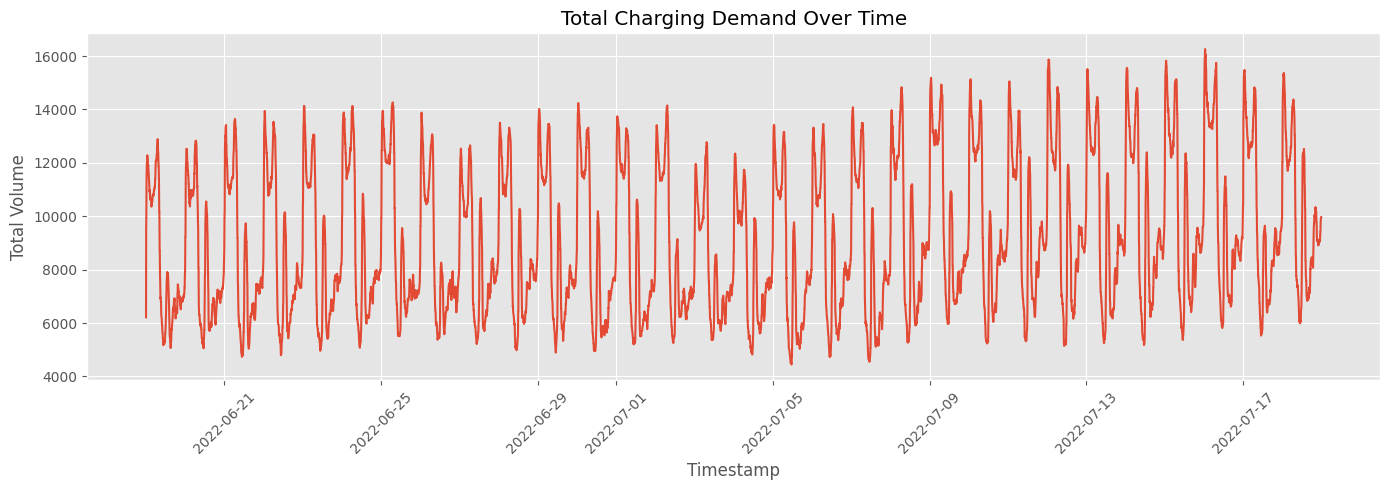

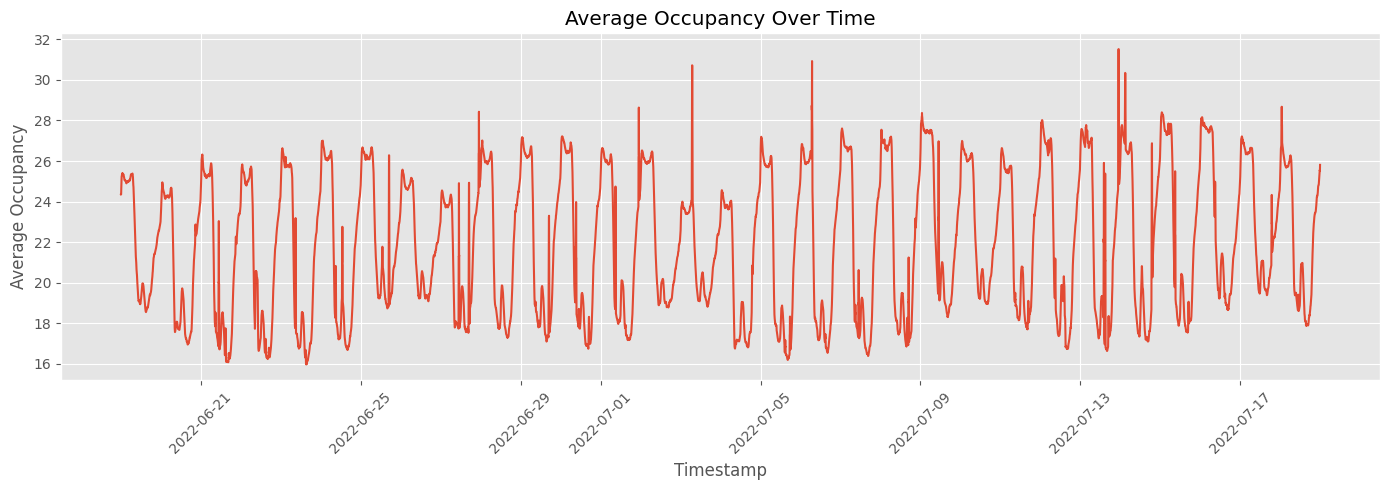

In [50]:
# Aggregate network-wide demand by timestamp
ts_summary = (
    master_df.groupby('timestamp', as_index=False)
    .agg(
        total_volume=('volume', 'sum'),
        avg_occupancy=('occupancy', 'mean'),
        avg_duration=('duration', 'mean'),
        avg_price=('price', 'mean')
    )
    .sort_values('timestamp')
)

display(ts_summary.head())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_summary['timestamp'], ts_summary['total_volume'])
ax.set_title('Total Charging Demand Over Time')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Total Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_summary['timestamp'], ts_summary['avg_occupancy'])
ax.set_title('Average Occupancy Over Time')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Average Occupancy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,hour,mean_volume,mean_occupancy,mean_duration,mean_price
0,0,51.776935,26.197672,1.831078,0.910361
1,1,53.809960,26.427440,1.858528,0.910363
2,2,48.357208,26.021964,1.821387,0.910386
3,3,46.466703,25.871244,1.805250,0.910418
4,4,46.661535,25.818522,1.802852,0.910493
5,5,49.153806,25.945243,1.813330,0.910492
6,6,54.280116,26.093691,1.825486,0.910492
7,7,51.767002,23.774674,1.642501,0.931812
8,8,33.408332,20.304971,1.332924,0.962817
9,9,25.876760,19.230229,1.238221,0.978920


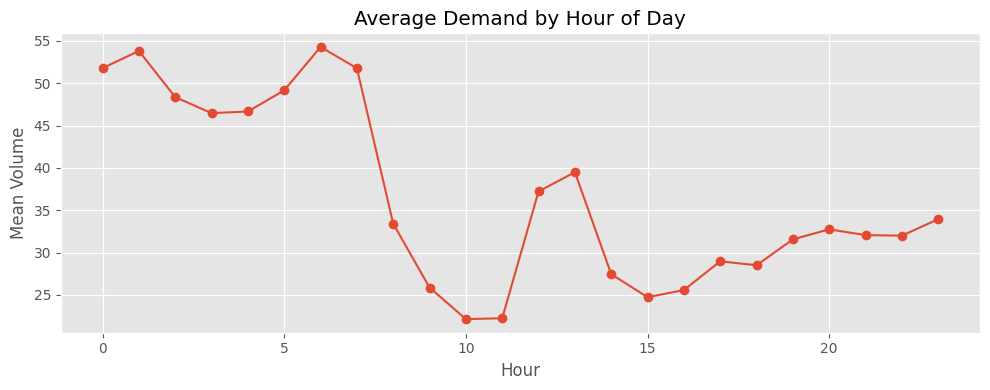

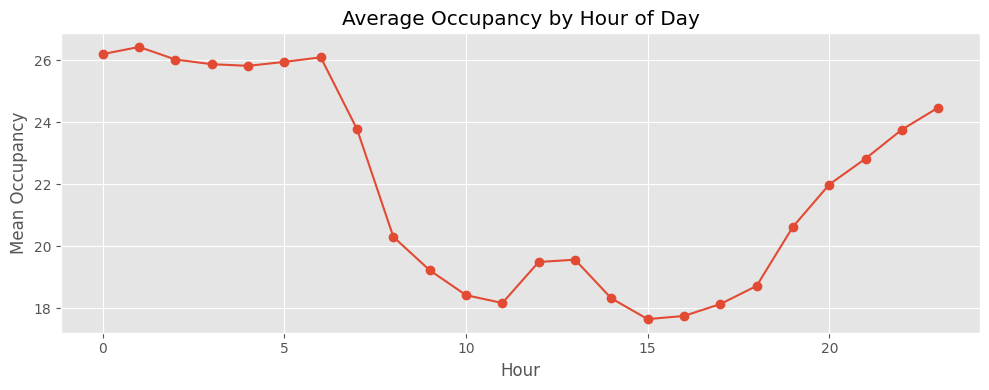

In [51]:
hourly_summary = (
    master_df.groupby('hour', as_index=False)
    .agg(
        mean_volume=('volume', 'mean'),
        mean_occupancy=('occupancy', 'mean'),
        mean_duration=('duration', 'mean'),
        mean_price=('price', 'mean')
    )
    .sort_values('hour')
)

display(hourly_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_summary['hour'], hourly_summary['mean_volume'], marker='o')
ax.set_title('Average Demand by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Mean Volume')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_summary['hour'], hourly_summary['mean_occupancy'], marker='o')
ax.set_title('Average Occupancy by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Mean Occupancy')
plt.tight_layout()
plt.show()

,dayofweek,mean_volume,mean_occupancy,mean_duration
0,0,36.317352,21.469281,1.441790
1,1,35.959231,21.540338,1.435469
2,2,36.322753,21.706703,1.440669
3,3,36.260659,21.720149,1.449559
4,4,37.680025,21.916530,1.477869
5,5,38.517234,22.700152,1.549782
6,6,35.961413,22.275883,1.511318


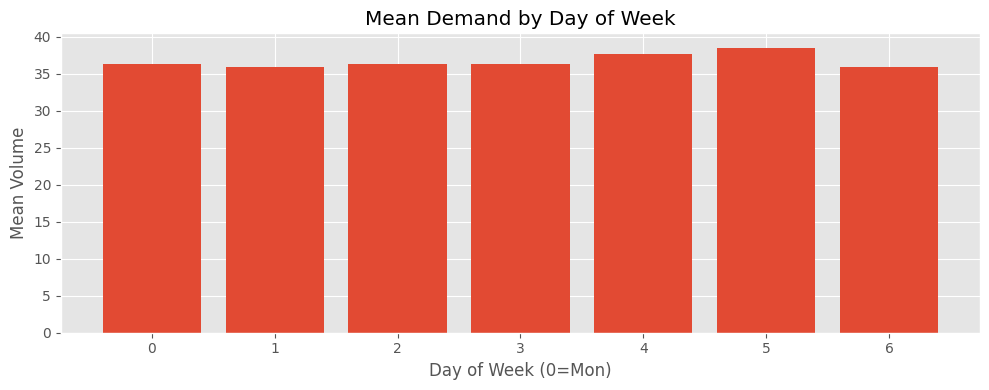

,is_weekend,mean_volume,mean_occupancy,mean_duration
0,0,36.498925,21.661014,1.448725
1,1,37.097333,22.464447,1.528413


In [52]:
dow_summary = (
    master_df.groupby('dayofweek', as_index=False)
    .agg(
        mean_volume=('volume', 'mean'),
        mean_occupancy=('occupancy', 'mean'),
        mean_duration=('duration', 'mean')
    )
    .sort_values('dayofweek')
)

display(dow_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(dow_summary['dayofweek'], dow_summary['mean_volume'])
ax.set_title('Mean Demand by Day of Week')
ax.set_xlabel('Day of Week (0=Mon)')
ax.set_ylabel('Mean Volume')
plt.tight_layout()
plt.show()

weekend_summary = (
    master_df.groupby('is_weekend', as_index=False)
    .agg(
        mean_volume=('volume', 'mean'),
        mean_occupancy=('occupancy', 'mean'),
        mean_duration=('duration', 'mean')
    )
)

display(weekend_summary)

,time_regime,mean_volume,mean_occupancy,std_volume,std_occupancy
2,low_night,49.371024,26.047014,135.217526,29.364874
4,morning_peak,41.333052,22.350891,118.868482,24.899828
3,midday,28.886671,18.608485,75.954195,20.161502
0,evening_peak,29.477078,19.449604,75.033669,21.464993
1,late_evening,32.672991,23.688154,78.452065,26.805766


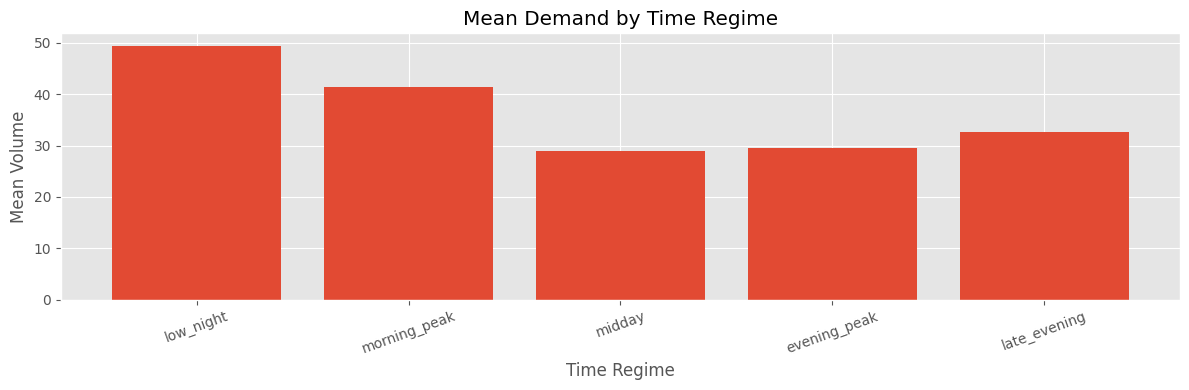

In [53]:
regime_summary = (
    master_df.groupby('time_regime', as_index=False)
    .agg(
        mean_volume=('volume', 'mean'),
        mean_occupancy=('occupancy', 'mean'),
        std_volume=('volume', 'std'),
        std_occupancy=('occupancy', 'std')
    )
)

# Keep a useful order
regime_order = ['low_night', 'morning_peak', 'midday', 'evening_peak', 'late_evening']
regime_summary['time_regime'] = pd.Categorical(regime_summary['time_regime'], categories=regime_order, ordered=True)
regime_summary = regime_summary.sort_values('time_regime')

display(regime_summary)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(regime_summary['time_regime'].astype(str), regime_summary['mean_volume'])
ax.set_title('Mean Demand by Time Regime')
ax.set_xlabel('Time Regime')
ax.set_ylabel('Mean Volume')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [54]:
top_hours = hourly_summary.sort_values('mean_volume', ascending=False).head(5)
display(top_hours)

print("Top demand hours:")
for _, row in top_hours.iterrows():
    print(f"Hour {int(row['hour'])}: mean volume = {row['mean_volume']:.3f}")

,hour,mean_volume,mean_occupancy,mean_duration,mean_price
6,6,54.280116,26.093691,1.825486,0.910492
1,1,53.809960,26.427440,1.858528,0.910363
0,0,51.776935,26.197672,1.831078,0.910361
7,7,51.767002,23.774674,1.642501,0.931812
5,5,49.153806,25.945243,1.813330,0.910492


Top demand hours:
Hour 6: mean volume = 54.280
Hour 1: mean volume = 53.810
Hour 0: mean volume = 51.777
Hour 7: mean volume = 51.767
Hour 5: mean volume = 49.154


In [55]:
ts_summary.to_csv(OUTPUT_DIR / 'temporal_ts_summary.csv', index=False)
hourly_summary.to_csv(OUTPUT_DIR / 'hourly_summary.csv', index=False)
dow_summary.to_csv(OUTPUT_DIR / 'dow_summary.csv', index=False)
regime_summary.to_csv(OUTPUT_DIR / 'regime_summary.csv', index=False)

print("Saved temporal summaries to outputs/")

Saved temporal summaries to outputs/


Detected metadata columns:
CBD: None
AREA: area
FAST: fast_count
SLOW: slow_count
LAT: None
LON: lon
DYNAMIC: dynamic_pricing


,station_id,volume_mean,volume_std,volume_max,volume_sum,occupancy_mean,occupancy_std,occupancy_max,duration_mean,duration_std,duration_max,price_mean,price_std,price_max,neighbor_pressure_mean,neighbor_pressure_std,congestion_index_mean,congestion_index_std,estimated_revenue_mean,estimated_revenue_sum,obs_count
0,1000,20.264916,6.850285,33.541667,175088.877640,50.396181,16.534449,90,3.940004,1.349604,6.500000,0.900614,0.005236,0.904933,32.265415,9.353972,1131.200861,666.673640,18.252549,157702.026623,8640
1,1009,27.476211,9.006125,45.208333,237394.466944,56.520139,16.681725,95,4.184235,1.401783,6.916667,0.955939,0.006042,0.960923,53.321102,14.329782,1698.577473,952.474915,26.269017,226964.305967,8640
2,1011,37.141907,9.588327,55.416667,320906.077916,78.168866,18.991303,123,5.694046,1.462928,8.500000,0.886190,0.000000,0.886190,55.042980,14.608726,3075.084301,1394.179999,32.914804,284383.909939,8640
3,1015,9.252280,3.952983,16.333333,79939.698611,16.792014,6.795316,33,1.321754,0.564712,2.333333,1.100000,0.000000,1.100000,18.005171,4.732360,181.685419,129.551207,10.177508,87933.668472,8640
4,102,5.336029,1.153703,9.625000,46103.288194,16.586921,3.925406,24,0.863161,0.177470,1.500000,1.023616,0.078945,1.123000,10.692419,2.144220,91.634700,35.725909,5.473919,47294.658008,8640


,station_id,volume_mean,volume_std,volume_max,volume_sum,occupancy_mean,occupancy_std,occupancy_max,duration_mean,duration_std,duration_max,price_mean,price_std,price_max,neighbor_pressure_mean,neighbor_pressure_std,congestion_index_mean,congestion_index_std,estimated_revenue_mean,estimated_revenue_sum,obs_count,area,fast_count,slow_count,lon,dynamic_pricing
0,1000,20.264916,6.850285,33.541667,175088.877640,50.396181,16.534449,90,3.940004,1.349604,6.500000,0.900614,0.005236,0.904933,32.265415,9.353972,1131.200861,666.673640,18.252549,157702.026623,8640,NaN,NaN,NaN,NaN,NaN
1,1009,27.476211,9.006125,45.208333,237394.466944,56.520139,16.681725,95,4.184235,1.401783,6.916667,0.955939,0.006042,0.960923,53.321102,14.329782,1698.577473,952.474915,26.269017,226964.305967,8640,NaN,NaN,NaN,NaN,NaN
2,1011,37.141907,9.588327,55.416667,320906.077916,78.168866,18.991303,123,5.694046,1.462928,8.500000,0.886190,0.000000,0.886190,55.042980,14.608726,3075.084301,1394.179999,32.914804,284383.909939,8640,NaN,NaN,NaN,NaN,NaN
3,1015,9.252280,3.952983,16.333333,79939.698611,16.792014,6.795316,33,1.321754,0.564712,2.333333,1.100000,0.000000,1.100000,18.005171,4.732360,181.685419,129.551207,10.177508,87933.668472,8640,NaN,NaN,NaN,NaN,NaN
4,102,5.336029,1.153703,9.625000,46103.288194,16.586921,3.925406,24,0.863161,0.177470,1.500000,1.023616,0.078945,1.123000,10.692419,2.144220,91.634700,35.725909,5.473919,47294.658008,8640,2.04,0.0,38.0,113.7945,1.0



Top overloaded stations:


,station_id,occupancy_mean,volume_mean,obs_count
77,1167,138.049653,497.286254,8640
169,703,98.767014,32.254468,8640
11,1049,91.651505,55.843452,8640
63,1137,91.193171,388.334273,8640
112,335,90.076736,46.714499,8640
125,519,80.029630,71.775148,8640
124,513,79.133681,45.278414,8640
2,1011,78.168866,37.141907,8640
129,526,77.911806,32.733379,8640
110,332,74.242245,32.996747,8640



Top underutilized stations:


,station_id,occupancy_mean,volume_mean,obs_count
79,1170,0.821528,0.475806,8640
168,702,0.998727,0.582056,8640
72,1160,1.169329,0.486128,8640
148,630,1.271644,5.922737,8640
64,1138,1.409144,0.814656,8640
68,115,1.420255,0.647816,8640
241,987,1.488773,0.198070,8640
74,1163,1.638542,0.949576,8640
35,1093,1.695139,0.987202,8640
147,628,1.748264,21.652059,8640


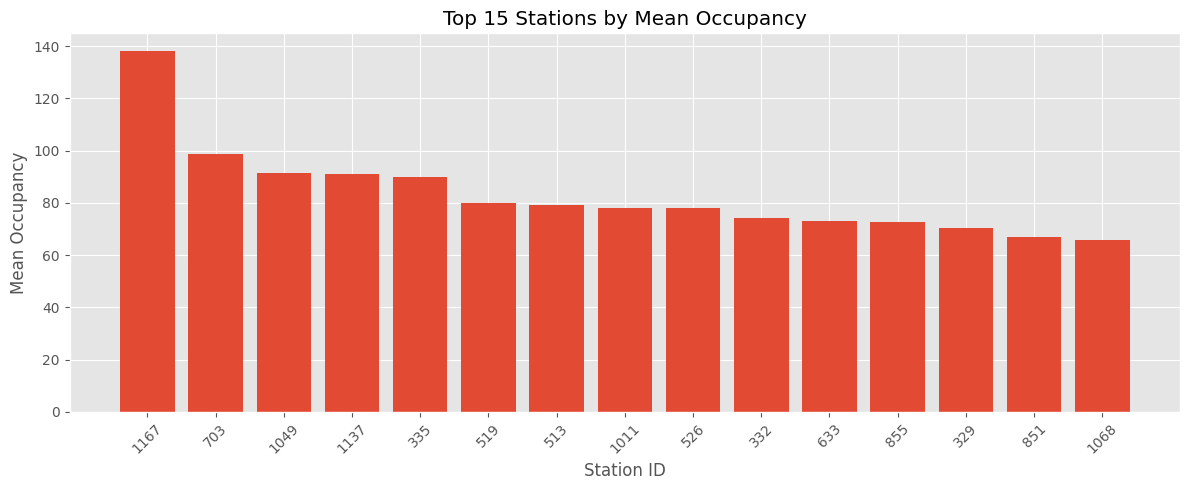

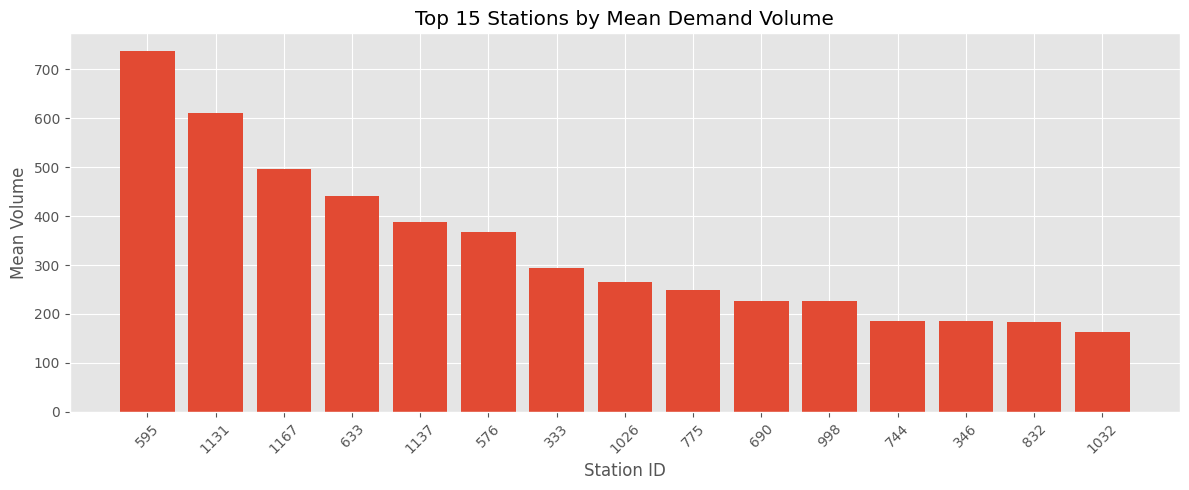

,station_id,fast_count,slow_count,occupancy_mean,volume_mean
0,1000,NaN,NaN,50.396181,20.264916
1,1009,NaN,NaN,56.520139,27.476211
2,1011,NaN,NaN,78.168866,37.141907
3,1015,NaN,NaN,16.792014,9.252280
4,102,0.0,38.0,16.586921,5.336029


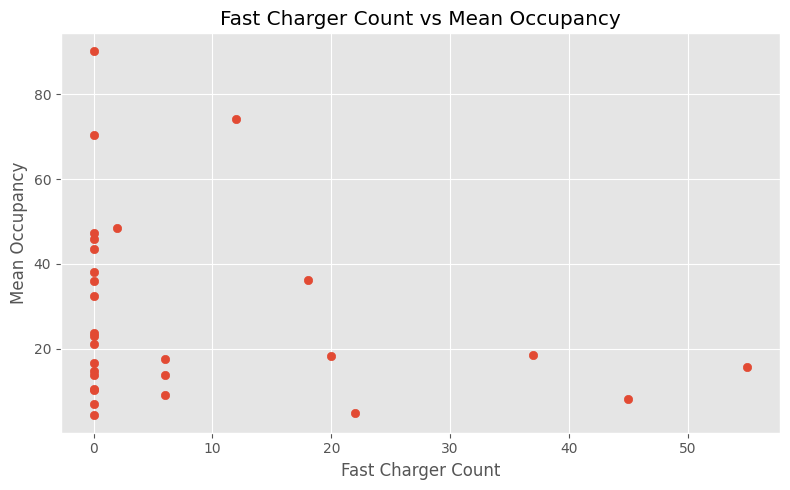

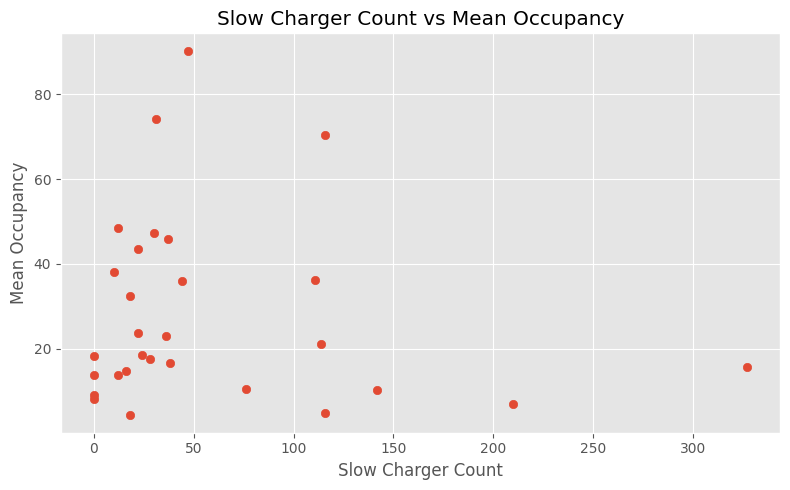

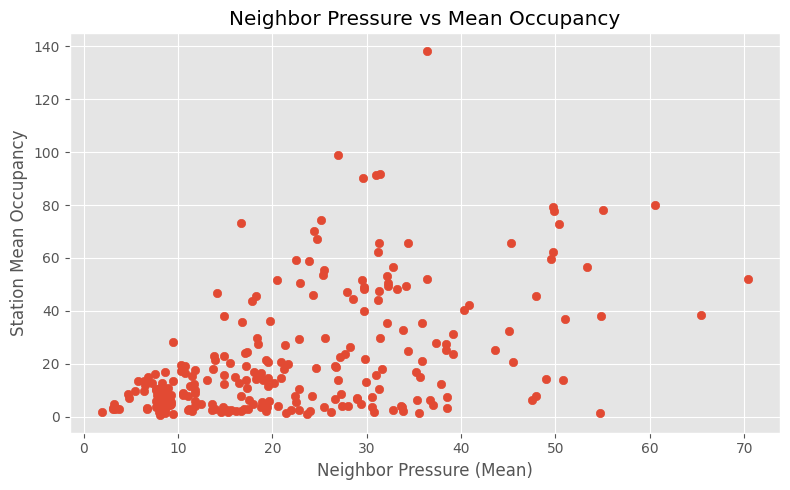

Saved station-level summaries to outputs/


In [56]:
# STAGE 2.2 — SPATIAL + STATION-LEVEL INTELLIGENCE----------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) SAFETY CHECKS
required_cols = ['station_id', 'timestamp', 'volume', 'occupancy', 'duration', 'price']
missing_req = [c for c in required_cols if c not in master_df.columns]
if missing_req:
    raise ValueError(f"master_df is missing required columns: {missing_req}")

master_df['timestamp'] = pd.to_datetime(master_df['timestamp'], errors='coerce')
master_df = master_df.dropna(subset=['timestamp']).copy()

# Standardize station_id as string for safe merging
master_df['station_id'] = master_df['station_id'].astype(str)

# Calculate estimated_revenue before aggregation
master_df['estimated_revenue'] = master_df['price'] * master_df['volume']

# 1) HELPER: FIND A COLUMN IF ITS NAME VARIES A BIT
def find_first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# Possible metadata columns (the file names may vary a little)
cbd_col = find_first_existing(master_df, ['cbd', 'is_cbd', 'central_business_district', 'cbd_flag'])
area_col = find_first_existing(master_df, ['area', 'region', 'zone', 'location_type'])
fast_col = find_first_existing(master_df, ['fast_count', 'fast_charger_count', 'num_fast', 'fast'])
slow_col = find_first_existing(master_df, ['slow_count', 'slow_charger_count', 'num_slow', 'slow'])
lat_col = find_first_existing(master_df, ['lat', 'latitude', 'y'])
lon_col = find_first_existing(master_df, ['lon', 'lng', 'longitude', 'x'])
dyn_col = find_first_existing(master_df, ['dynamic_pricing', 'dynamic_pricing_flag', 'pricing_flag'])

print("Detected metadata columns:")
print("CBD:", cbd_col)
print("AREA:", area_col)
print("FAST:", fast_col)
print("SLOW:", slow_col)
print("LAT:", lat_col)
print("LON:", lon_col)
print("DYNAMIC:", dyn_col)

# 2) STATION-LEVEL AGGREGATION
agg_dict = {
    'volume': ['mean', 'std', 'max', 'sum'],
    'occupancy': ['mean', 'std', 'max'],
    'duration': ['mean', 'std', 'max'],
    'price': ['mean', 'std', 'max'],
    'neighbor_pressure': ['mean', 'std'] if 'neighbor_pressure' in master_df.columns else ['mean'],
    'congestion_index': ['mean', 'std'] if 'congestion_index' in master_df.columns else ['mean'],
    'estimated_revenue': ['mean', 'sum'] if 'estimated_revenue' in master_df.columns else ['mean']
}

station_summary = master_df.groupby('station_id').agg(agg_dict)

# flatten multiindex columns
station_summary.columns = [
    '_'.join([c for c in col if c]).strip('_')
    for col in station_summary.columns.to_flat_index()
]
station_summary = station_summary.reset_index()

# number of observations per station
obs_count = master_df.groupby('station_id').size().reset_index(name='obs_count')
station_summary = station_summary.merge(obs_count, on='station_id', how='left')

display(station_summary.head())

# 3) MERGE STATION METADATA IF PRESENT
metadata_cols = ['station_id']
for c in [cbd_col, area_col, fast_col, slow_col, lat_col, lon_col, dyn_col]:
    if c is not None:
        metadata_cols.append(c)

# Keep unique station metadata rows if possible
station_meta = None
if len(metadata_cols) > 1:
    station_meta = (
        master_df[metadata_cols]
        .drop_duplicates(subset=['station_id'])
        .copy()
    )
    station_summary = station_summary.merge(station_meta, on='station_id', how='left')

display(station_summary.head())

# 4) OVERLOADED / UNDERUTILIZED STATIONS
# Use occupancy mean as the main utilization proxy
if 'occupancy_mean' in station_summary.columns:
    q75 = station_summary['occupancy_mean'].quantile(0.75)
    q25 = station_summary['occupancy_mean'].quantile(0.25)

    overloaded = station_summary[station_summary['occupancy_mean'] >= q75].sort_values(
        'occupancy_mean', ascending=False
    )
    underutilized = station_summary[station_summary['occupancy_mean'] <= q25].sort_values(
        'occupancy_mean', ascending=True
    )

    print("\nTop overloaded stations:")
    display(overloaded[['station_id', 'occupancy_mean', 'volume_mean', 'obs_count']].head(10))

    print("\nTop underutilized stations:")
    display(underutilized[['station_id', 'occupancy_mean', 'volume_mean', 'obs_count']].head(10))

# 5) VISUALIZE TOP STATIONS
if 'occupancy_mean' in station_summary.columns:
    top_occ = station_summary.sort_values('occupancy_mean', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(top_occ['station_id'].astype(str), top_occ['occupancy_mean'])
    ax.set_title('Top 15 Stations by Mean Occupancy')
    ax.set_xlabel('Station ID')
    ax.set_ylabel('Mean Occupancy')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if 'volume_mean' in station_summary.columns:
    top_vol = station_summary.sort_values('volume_mean', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(top_vol['station_id'].astype(str), top_vol['volume_mean'])
    ax.set_title('Top 15 Stations by Mean Demand Volume')
    ax.set_xlabel('Station ID')
    ax.set_ylabel('Mean Volume')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 6) CBD VS NON-CBD COMPARISON
if cbd_col is not None:
    # normalize cbd values to 0/1 if possible
    cbd_tmp = station_summary[[cbd_col, 'occupancy_mean', 'volume_mean']].copy()

    # attempt safe mapping
    cbd_tmp[cbd_col] = cbd_tmp[cbd_col].astype(str).str.lower().str.strip()
    cbd_tmp['cbd_group'] = cbd_tmp[cbd_col].map({
        '1': 'CBD',
        'true': 'CBD',
        'yes': 'CBD',
        'y': 'CBD',
        'cbd': 'CBD',
        '0': 'Non-CBD',
        'false': 'Non-CBD',
        'no': 'Non-CBD',
        'n': 'Non-CBD'
    })

    # fallback if mapping did not work
    cbd_tmp['cbd_group'] = cbd_tmp['cbd_group'].fillna('Unknown')

    cbd_summary = (
        cbd_tmp.groupby('cbd_group', as_index=False)
        .agg(
            mean_occupancy=('occupancy_mean', 'mean'),
            mean_volume=('volume_mean', 'mean'),
            stations=('occupancy_mean', 'count')
        )
    )

    display(cbd_summary)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(cbd_summary['cbd_group'], cbd_summary['mean_occupancy'])
    ax.set_title('Mean Occupancy: CBD vs Non-CBD')
    ax.set_xlabel('Group')
    ax.set_ylabel('Mean Occupancy')
    plt.tight_layout()
    plt.show()

# 7) FAST VS SLOW CHARGER PROFILE
if fast_col is not None or slow_col is not None:
    charger_cols = [c for c in [fast_col, slow_col] if c is not None]
    charger_view = station_summary[['station_id'] + charger_cols + ['occupancy_mean', 'volume_mean']].copy()

    for c in charger_cols:
        charger_view[c] = pd.to_numeric(charger_view[c], errors='coerce')

    display(charger_view.head())

    if fast_col is not None and slow_col is not None:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.scatter(charger_view[fast_col], charger_view['occupancy_mean'])
        ax.set_title('Fast Charger Count vs Mean Occupancy')
        ax.set_xlabel('Fast Charger Count')
        ax.set_ylabel('Mean Occupancy')
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.scatter(charger_view[slow_col], charger_view['occupancy_mean'])
        ax.set_title('Slow Charger Count vs Mean Occupancy')
        ax.set_xlabel('Slow Charger Count')
        ax.set_ylabel('Mean Occupancy')
        plt.tight_layout()
        plt.show()

# 8) NETWORK PRESSURE ANALYSIS
if 'neighbor_pressure_mean' in station_summary.columns and 'occupancy_mean' in station_summary.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(station_summary['neighbor_pressure_mean'], station_summary['occupancy_mean'])
    ax.set_title('Neighbor Pressure vs Mean Occupancy')
    ax.set_xlabel('Neighbor Pressure (Mean)')
    ax.set_ylabel('Station Mean Occupancy')
    plt.tight_layout()
    plt.show()

# 9) SAVE OUTPUTS
station_summary.to_csv(OUTPUT_DIR / 'station_summary.csv', index=False)

if 'occupancy_mean' in station_summary.columns:
    if 'overloaded' in locals():
        overloaded.to_csv(OUTPUT_DIR / 'overloaded_stations.csv', index=False)
    if 'underutilized' in locals():
        underutilized.to_csv(OUTPUT_DIR / 'underutilized_stations.csv', index=False)

print("Saved station-level summaries to outputs/")

Nodes: 247
Edges: 750
Graph Density: 0.02468648168263059
Connected Components: 12
Largest Component Size: 183


,station_id,degree_centrality,betweenness_centrality,closeness_centrality,eigenvector_centrality,clustering_coeff
0,102,0.012195,0.000000,0.056528,NaN,0.000000
1,105,0.024390,0.006745,0.066102,NaN,0.333333
2,107,0.020325,0.000095,0.065587,NaN,0.666667
3,108,0.028455,0.008563,0.071584,NaN,0.500000
4,109,0.032520,0.038557,0.078513,NaN,0.266667


Number of communities: 23


,station_id,community_id
0,332,0
1,226,0
2,1111,0
3,323,0
4,320,0


,station_id,node_degree,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coeff,community_id
0,102,3,0.012195,0.000000,0.056528,0.000000,7
1,105,6,0.024390,0.006745,0.066102,0.333333,7
2,107,5,0.020325,0.000095,0.065587,0.666667,7
3,108,7,0.028455,0.008563,0.071584,0.500000,7
4,109,8,0.032520,0.038557,0.078513,0.266667,7


...

,time_index,station_id,distance_weighted_neighbor_pressure
0,1,102,13.043478
1,2,102,13.043478
2,3,102,13.086957
3,4,102,13.086957
4,5,102,13.043478


(2134080, 63)
TOP DEGREE CENTRALITY STATIONS


,station_id,node_degree,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coeff,community_id
31,326,13,0.052846,0.045745,0.094359,0.254545,0
36,332,12,0.048780,0.108493,0.114988,0.244444,0
84,681,12,0.048780,0.292556,0.140701,0.177778,11
186,1062,10,0.040650,0.018036,0.095025,0.321429,1
239,1163,10,0.040650,0.031869,0.085276,0.321429,2
124,783,10,0.040650,0.212446,0.112490,0.214286,2
121,773,10,0.040650,0.103848,0.094624,0.178571,2
92,700,9,0.036585,0.121220,0.134114,0.333333,5
97,705,9,0.036585,0.013012,0.116379,0.428571,5
96,704,9,0.036585,0.023334,0.121088,0.428571,5


TOP BETWEENNESS STATIONS


,station_id,node_degree,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coeff,community_id
84,681,12,0.048780,0.292556,0.140701,0.177778,11
118,746,7,0.028455,0.232200,0.127752,0.300000,5
177,1026,6,0.024390,0.232118,0.120331,0.333333,8
124,783,10,0.040650,0.212446,0.112490,0.214286,2
38,335,8,0.032520,0.171059,0.135873,0.266667,11
37,333,7,0.028455,0.154804,0.125607,0.300000,0
41,346,8,0.032520,0.127961,0.130097,0.266667,11
92,700,9,0.036585,0.121220,0.134114,0.333333,5
23,235,9,0.036585,0.121172,0.130475,0.238095,11
180,1032,5,0.020325,0.120424,0.115779,0.000000,4


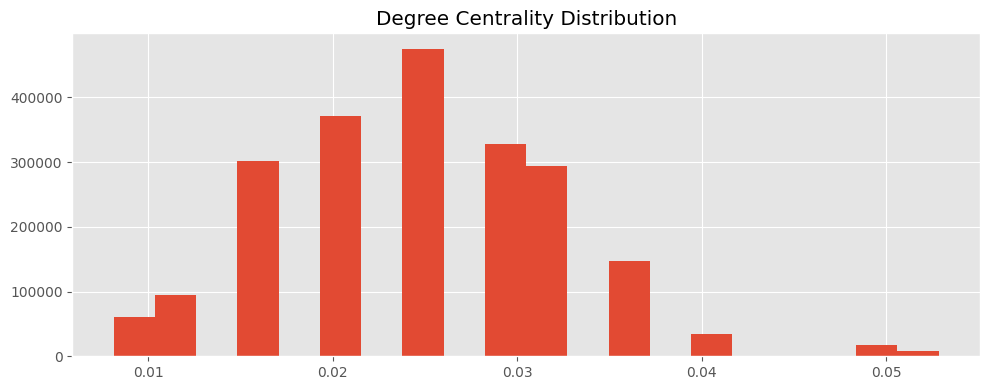

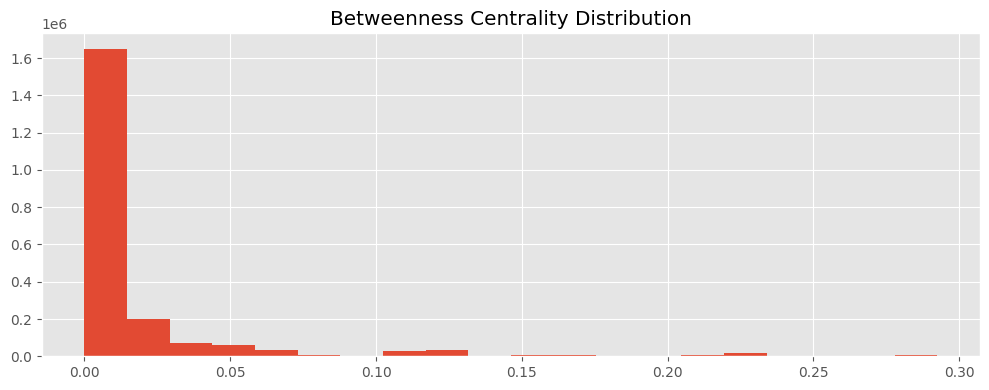

,community_id,occupancy,volume,network_health_score,distance_weighted_neighbor_pressure
0,0,23.922797,25.343601,0.382506,14.264704
1,1,11.598860,5.556846,0.377317,14.469114
2,2,31.343070,81.517651,0.398611,14.962208
3,3,33.047459,35.126220,0.291356,NaN
4,4,41.814617,45.030281,0.334942,NaN
5,5,28.516714,24.827638,0.382694,NaN
6,6,19.522739,8.842220,0.326888,NaN
7,7,11.376513,4.915064,0.316886,14.601980
8,8,19.004605,65.640680,0.334160,NaN
9,9,26.280187,118.423554,0.280971,NaN


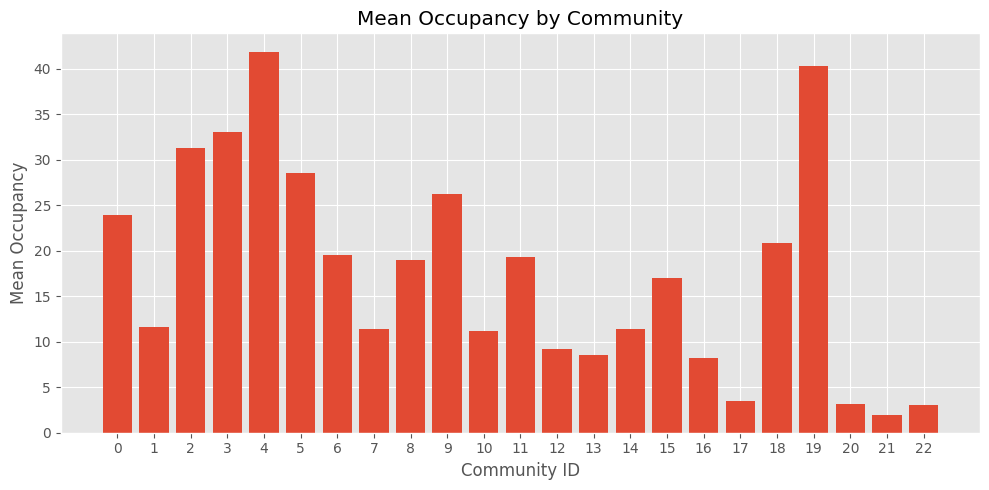

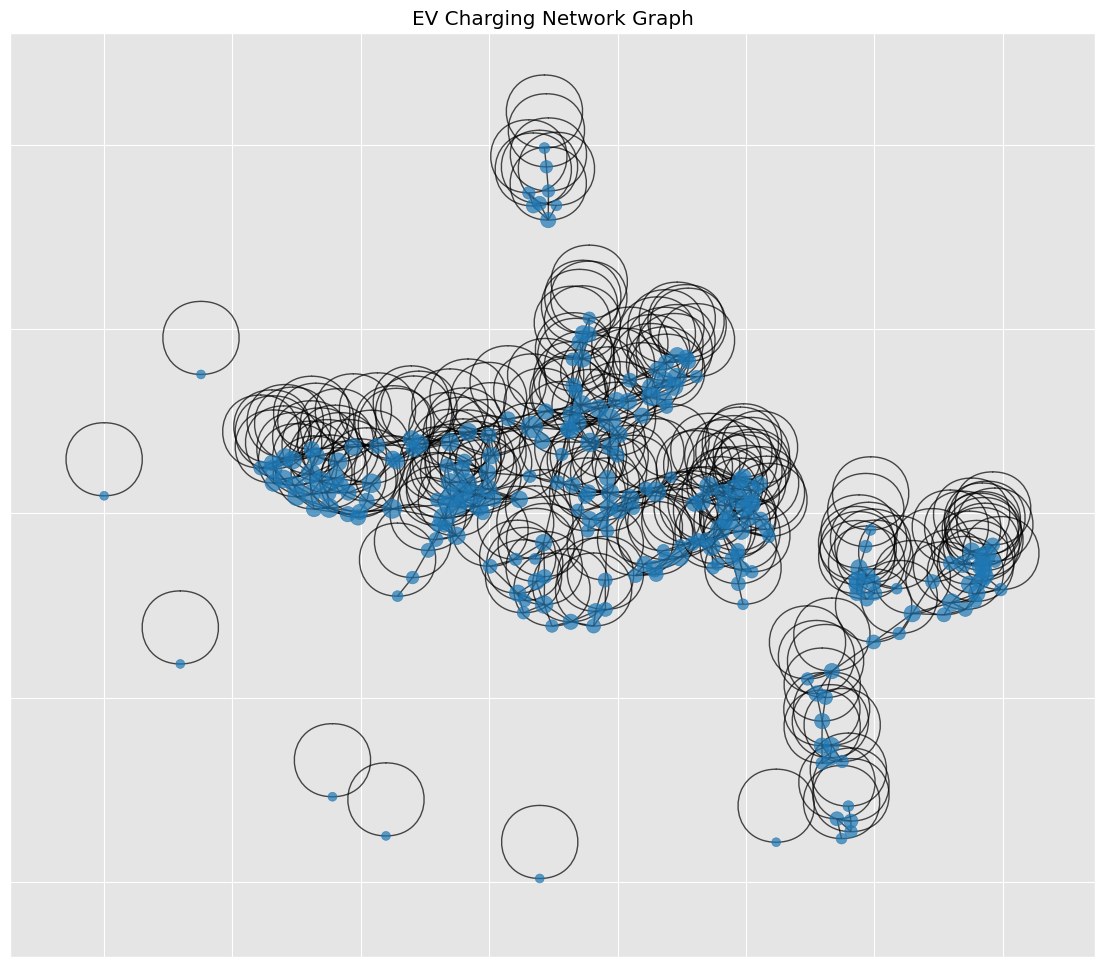

Stage 2.3 completed successfully.


In [57]:
# STAGE 2.3 — COMPLETE GRAPH + NETWORK INTELLIGENCE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
# 0. SAFETY CHECKS

master_df['station_id'] = (
    master_df['station_id']
    .astype(str)
)

# Copy adjacency and distance matrices
adj_df = adj.copy()
dist_df = distance.copy()

adj_df.index = adj_df.index.astype(str)
adj_df.columns = adj_df.columns.astype(str)

dist_df.index = dist_df.index.astype(str)
dist_df.columns = dist_df.columns.astype(str)
# 1. BUILD NETWORK GRAPH

G = nx.from_pandas_adjacency(adj_df)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
# 2. BASIC GRAPH STATISTICS

graph_density = nx.density(G)

num_components = nx.number_connected_components(G)

largest_cc = max(
    nx.connected_components(G),
    key=len
)

largest_cc_size = len(largest_cc)

print("Graph Density:", graph_density)
print("Connected Components:", num_components)
print("Largest Component Size:", largest_cc_size)
# 3. CENTRALITY FEATURES

degree_centrality = nx.degree_centrality(G)

betweenness_centrality = nx.betweenness_centrality(
    G,
    normalized=True
)

closeness_centrality = nx.closeness_centrality(G)

try:

    eigenvector_centrality = (
        nx.eigenvector_centrality_numpy(G)
    )

except:

    eigenvector_centrality = {
        n: np.nan for n in G.nodes()
    }

clustering_coeff = nx.clustering(G)

# ============================================================
# 4. CENTRALITY DATAFRAME
# ============================================================

centrality_df = pd.DataFrame({

    'station_id': list(G.nodes()),

    'degree_centrality': [
        degree_centrality.get(n, np.nan)
        for n in G.nodes()
    ],

    'betweenness_centrality': [
        betweenness_centrality.get(n, np.nan)
        for n in G.nodes()
    ],

    'closeness_centrality': [
        closeness_centrality.get(n, np.nan)
        for n in G.nodes()
    ],

    'eigenvector_centrality': [
        eigenvector_centrality.get(n, np.nan)
        for n in G.nodes()
    ],

    'clustering_coeff': [
        clustering_coeff.get(n, np.nan)
        for n in G.nodes()
    ]
})

display(centrality_df.head())

# ============================================================
# 5. COMMUNITY DETECTION
# ============================================================

from networkx.algorithms.community import (
    greedy_modularity_communities
)

communities = list(
    greedy_modularity_communities(G)
)

print("Number of communities:", len(communities))

community_map = {}

for cid, community in enumerate(communities):

    for node in community:

        community_map[str(node)] = cid

community_df = pd.DataFrame({

    'station_id': list(community_map.keys()),

    'community_id': list(community_map.values())
})

display(community_df.head())

# ============================================================
# 6. NODE DEGREE
# ============================================================

node_degree = dict(G.degree())

graph_attr_df = pd.DataFrame({

    'station_id': list(G.nodes()),

    'node_degree': [
        node_degree.get(n, np.nan)
        for n in G.nodes()
    ],

    'degree_centrality': [
        degree_centrality.get(n, np.nan)
        for n in G.nodes()
    ],

    'betweenness_centrality': [
        betweenness_centrality.get(n, np.nan)
        for n in G.nodes()
    ],

    'closeness_centrality': [
        closeness_centrality.get(n, np.nan)
        for n in G.nodes()
    ],

    'clustering_coeff': [
        clustering_coeff.get(n, np.nan)
        for n in G.nodes()
    ]
})

graph_attr_df = graph_attr_df.merge(
    community_df,
    on='station_id',
    how='left'
)

display(graph_attr_df.head())

# ============================================================
# 7. MERGE GRAPH FEATURES INTO MASTER TABLE
# ============================================================

# Define all graph-related column names that might exist in master_df
# This includes columns from graph_attr_df and graph_features (merged earlier)
all_graph_feature_names = [
    'node_degree',
    'degree_centrality',
    'betweenness_centrality',
    'closeness_centrality',
    'clustering_coeff',
    'community_id',
    'betweenness' # From graph_features
]

# Identify and remove all existing graph-related columns, including suffixed ones
existing_graph_cols_to_drop = []
for col in master_df.columns:
    for gf_name in all_graph_feature_names:
        if col == gf_name or col.startswith(f'{gf_name}_') or col.endswith('_x') or col.endswith('_y'):
            existing_graph_cols_to_drop.append(col)
            break # Move to the next column in master_df once a match is found

# Drop unique columns to avoid errors if some already exist multiple times
existing_graph_cols_to_drop = list(set(existing_graph_cols_to_drop))

master_df = master_df.drop(columns=existing_graph_cols_to_drop, errors='ignore')

# Merge the comprehensive graph_attr_df
master_df = master_df.merge(
    graph_attr_df,
    on='station_id',
    how='left'
)

print(master_df.shape)

# ============================================================
# 8. DISTANCE-BASED SPATIAL FEATURES
# ============================================================

dist_numeric = dist_df.apply(
    pd.to_numeric,
    errors='coerce'
)

# Remove self-distance
np.fill_diagonal(
    dist_numeric.values,
    np.nan
)

nearest_neighbor_distance = (
    dist_numeric.min(axis=1)
)

mean_neighbor_distance = (
    dist_numeric.mean(axis=1)
)

spatial_df = pd.DataFrame({

    'station_id': dist_numeric.index.astype(str),

    'nearest_neighbor_distance':
        nearest_neighbor_distance.values,

    'mean_neighbor_distance':
        mean_neighbor_distance.values
})

display(spatial_df.head())

# ============================================================
# MERGE SPATIAL FEATURES
# ============================================================
# Remove old spatial columns if they already exist to avoid duplicates
spatial_feature_names = [
    'nearest_neighbor_distance',
    'mean_neighbor_distance'
]
existing_spatial_cols_to_drop = []
for col in master_df.columns:
    for sf_name in spatial_feature_names:
        if col == sf_name or col.startswith(f'{sf_name}_') or col.endswith('_x') or col.endswith('_y'):
            existing_spatial_cols_to_drop.append(col)
            break

existing_spatial_cols_to_drop = list(set(existing_spatial_cols_to_drop))
master_df = master_df.drop(columns=existing_spatial_cols_to_drop, errors='ignore')

master_df = master_df.merge(
    spatial_df,
    on='station_id',
    how='left'
)

print(master_df.shape)

display(master_df.head())

print(master_df.shape)

# ============================================================
# 9. DISTANCE-WEIGHTED NEIGHBOR PRESSURE
# SAFE + BOUNDED VERSION
# ============================================================

occ_mat = occupancy.copy()
occ_mat.columns = occ_mat.columns.astype(str)

aligned_stations = [
    s for s in dist_numeric.index.astype(str)
    if s in occ_mat.columns
]

dist_aligned = dist_numeric.loc[aligned_stations, aligned_stations].copy()
occ_aligned = occ_mat[aligned_stations].copy()

# Clip tiny distances so inverse does not explode
dist_values = dist_aligned.astype(float).clip(lower=0.5)

# Convert distance to similarity in a bounded way
similarity_matrix = 1.0 / dist_values

# Remove self influence
np.fill_diagonal(similarity_matrix.values, 0.0)

# Normalize row-wise
row_sums = similarity_matrix.sum(axis=1)
row_sums[row_sums == 0] = 1
similarity_norm = similarity_matrix.div(row_sums, axis=0)

# Weighted neighbor pressure
neighbor_pressure_matrix = occ_aligned.values @ similarity_norm.T.values

neighbor_pressure_df = pd.DataFrame(
    neighbor_pressure_matrix,
    index=occ_aligned.index,
    columns=occ_aligned.columns
)

# ============================================================
# 10. CONVERT TO LONG FORMAT (FIXED VERSION)
# ============================================================

neighbor_pressure_reset = neighbor_pressure_df.reset_index()
time_col = neighbor_pressure_reset.columns[0]

neighbor_pressure_long = (
    neighbor_pressure_reset
    .melt(
        id_vars=time_col,
        var_name='station_id',
        value_name='distance_weighted_neighbor_pressure'
    )
    .rename(columns={time_col: 'time_index'})
)

display(neighbor_pressure_long.head())


# ============================================================
# 11. MERGE INTO MASTER TABLE
# ============================================================

neighbor_pressure_long['station_id'] = (

    neighbor_pressure_long['station_id']
    .astype(str)
)

master_df['station_id'] = (
    master_df['station_id']
    .astype(str)
)

# Remove old 'distance_weighted_neighbor_pressure' if it exists
if 'distance_weighted_neighbor_pressure' in master_df.columns:
    master_df = master_df.drop(columns=['distance_weighted_neighbor_pressure'], errors='ignore')

master_df = master_df.merge(

    neighbor_pressure_long,

    on=['time_index', 'station_id'],

    how='left'
)

print(master_df.shape)

# ============================================================
# 12. NETWORK HEALTH SCORE
# NORMALIZED VERSION
# ============================================================

# Normalize raw node degree first
degree_norm = master_df['node_degree'] / (master_df['node_degree'].max() + 1e-6)

master_df['network_health_score'] = (
    0.35 * master_df['degree_centrality'].fillna(0) +
    0.35 * master_df['betweenness_centrality'].fillna(0) +
    0.15 * (1 - master_df['clustering_coeff'].fillna(0)) +
    0.15 * degree_norm.fillna(0)
)

# Final min-max scaling to [0, 1]
mh_min = master_df['network_health_score'].min()
mh_max = master_df['network_health_score'].max()

master_df['network_health_score'] = (
    (master_df['network_health_score'] - mh_min) / (mh_max - mh_min + 1e-6)
)

# ============================================================
# 13. TOP NETWORK HUBS
# ============================================================

top_degree = (

    graph_attr_df

    .sort_values(
        'degree_centrality',
        ascending=False
    )

    .head(10)
)

top_between = (

    graph_attr_df

    .sort_values(
        'betweenness_centrality',
        ascending=False
    )

    .head(10)
)

print("TOP DEGREE CENTRALITY STATIONS")
display(top_degree)

print("TOP BETWEENNESS STATIONS")
display(top_between)

# ============================================================
# 14. CENTRALITY DISTRIBUTIONS
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    master_df['degree_centrality']
    .dropna(),
    bins=20
)

ax.set_title(
    'Degree Centrality Distribution'
)

plt.tight_layout()

plt.show()

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    master_df['betweenness_centrality']
    .dropna(),
    bins=20
)

ax.set_title(
    'Betweenness Centrality Distribution'
)

plt.tight_layout()

plt.show()

# ============================================================
# 15. COMMUNITY CONGESTION ANALYSIS
# ============================================================

community_congestion = (

    master_df

    .groupby('community_id')

    .agg({

        'occupancy': 'mean',

        'volume': 'mean',

        'network_health_score': 'mean',

        'distance_weighted_neighbor_pressure':
            'mean'
    })

    .reset_index()
)

display(community_congestion)

# ============================================================
# 16. COMMUNITY VISUALIZATION
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(

    community_congestion['community_id']
    .astype(str),

    community_congestion['occupancy']
)

ax.set_title(
    'Mean Occupancy by Community'
)

ax.set_xlabel('Community ID')

ax.set_ylabel('Mean Occupancy')

plt.tight_layout()

plt.show()

# ============================================================
# 17. NETWORK GRAPH VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 12))

pos = nx.spring_layout(
    G,
    seed=42
)

node_sizes = [

    degree_centrality[n] * 5000

    for n in G.nodes()
]

nx.draw_networkx(

    G,

    pos=pos,

    with_labels=False,

    node_size=node_sizes,

    alpha=0.7
)

plt.title(
    'EV Charging Network Graph'
)

plt.show()

# ============================================================
# 18. SAVE OUTPUTS
# ============================================================

centrality_df.to_csv(
    OUTPUT_DIR / 'centrality_features.csv',
    index=False
)
community_df.to_csv(
    OUTPUT_DIR / 'community_features.csv',
    index=False
)
graph_attr_df.to_csv(
    OUTPUT_DIR / 'graph_attributes.csv',
    index=False
)

spatial_df.to_csv(
    OUTPUT_DIR / 'distance_spatial_features.csv',
    index=False
)

community_congestion.to_csv(
    OUTPUT_DIR / 'community_congestion.csv',
    index=False
)

print("Stage 2.3 completed successfully.")

In [58]:
# ============================================================
# STAGE 3.1 — FORECAST TARGET CREATION
# ============================================================

FORECAST_HORIZON = 1

master_df = master_df.sort_values(
    ['station_id', 'timestamp']
)

master_df['target_volume'] = (

    master_df

    .groupby('station_id')['volume']

    .shift(-FORECAST_HORIZON)
)

In [59]:
master_df = master_df.dropna(
    subset=['target_volume']
)

print(master_df.shape)

(2133833, 65)


In [60]:
feature_cols = [

    # --------------------------------------------------------
    # TEMPORAL FEATURES
    # --------------------------------------------------------

    'hour',
    'dayofweek',
    'month',
    'is_weekend',

    'hour_sin',
    'hour_cos',

    'dow_sin',
    'dow_cos',

    # --------------------------------------------------------
    # CURRENT STATE
    # --------------------------------------------------------

    'volume',
    'occupancy',
    'duration',
    'price',
    'count',

    # --------------------------------------------------------
    # LAG FEATURES
    # --------------------------------------------------------

    'volume_lag_1',
    'volume_lag_2',
    'volume_lag_3',
    'volume_lag_6',
    'volume_lag_12',

    'occupancy_lag_1',
    'occupancy_lag_2',
    'occupancy_lag_3',

    # --------------------------------------------------------
    # ROLLING FEATURES
    # --------------------------------------------------------

    'volume_roll_mean_3',
    'volume_roll_mean_6',
    'volume_roll_mean_12',

    'volume_roll_std_3',
    'volume_roll_std_6',

    'occupancy_roll_mean_3',
    'occupancy_roll_mean_6',

    # --------------------------------------------------------
    # CONGESTION FEATURES
    # --------------------------------------------------------

    'congestion_index',
    'demand_pressure',

    'neighbor_pressure',

    'distance_weighted_neighbor_pressure',

    # --------------------------------------------------------
    # NETWORK FEATURES
    # --------------------------------------------------------

    'degree_centrality',

    'betweenness_centrality',

    'closeness_centrality',

    'clustering_coeff',

    'node_degree',

    'network_health_score',

    # --------------------------------------------------------
    # SPATIAL FEATURES
    # --------------------------------------------------------

    'nearest_neighbor_distance',

    'mean_neighbor_distance'
]

# Keep only columns that actually exist
feature_cols = [

    c for c in feature_cols
    if c in master_df.columns
]

print("Number of features:", len(feature_cols))

print(feature_cols)

Number of features: 40
['hour', 'dayofweek', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'volume', 'occupancy', 'duration', 'price', 'count', 'volume_lag_1', 'volume_lag_2', 'volume_lag_3', 'volume_lag_6', 'volume_lag_12', 'occupancy_lag_1', 'occupancy_lag_2', 'occupancy_lag_3', 'volume_roll_mean_3', 'volume_roll_mean_6', 'volume_roll_mean_12', 'volume_roll_std_3', 'volume_roll_std_6', 'occupancy_roll_mean_3', 'occupancy_roll_mean_6', 'congestion_index', 'demand_pressure', 'neighbor_pressure', 'distance_weighted_neighbor_pressure', 'degree_centrality', 'betweenness_centrality', 'closeness_centrality', 'clustering_coeff', 'node_degree', 'network_health_score', 'nearest_neighbor_distance', 'mean_neighbor_distance']


In [61]:
model_df = master_df[

    feature_cols + [
        'target_volume',
        'timestamp',
        'station_id',
        'time_regime'
    ]

].copy()

print(model_df.shape)

display(model_df.head())

(2133833, 44)


,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,volume,occupancy,duration,price,count,volume_lag_1,volume_lag_2,volume_lag_3,volume_lag_6,volume_lag_12,occupancy_lag_1,occupancy_lag_2,occupancy_lag_3,volume_roll_mean_3,volume_roll_mean_6,volume_roll_mean_12,volume_roll_std_3,volume_roll_std_6,occupancy_roll_mean_3,occupancy_roll_mean_6,congestion_index,demand_pressure,neighbor_pressure,distance_weighted_neighbor_pressure,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coeff,node_degree,network_health_score,nearest_neighbor_distance,mean_neighbor_distance,target_volume,timestamp,station_id,time_regime
0,0,6,6,1,0.0,1.0,-0.781831,0.62349,16.197222,60,3.157778,0.894267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,971.833333,3.895644,38.166668,NaN,0.028455,0.001147,0.033842,0.3,7,0.437999,NaN,NaN,24.791667,2022-06-19 00:00:00,1000,low_night
1,0,6,6,1,0.0,1.0,-0.781831,0.62349,24.791667,60,4.833333,0.894267,NaN,16.197222,NaN,NaN,NaN,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1487.500000,4.250000,38.166668,NaN,0.028455,0.001147,0.033842,0.3,7,0.437999,NaN,NaN,24.791667,2022-06-19 00:05:00,1000,low_night
2,0,6,6,1,0.0,1.0,-0.781831,0.62349,24.791667,60,4.833333,0.894267,NaN,24.791667,16.197222,NaN,NaN,NaN,60.0,60.0,NaN,21.926852,NaN,NaN,4.962005,NaN,60.0,NaN,1487.500000,4.250000,38.666668,NaN,0.028455,0.001147,0.033842,0.3,7,0.437999,NaN,NaN,24.791667,2022-06-19 00:10:00,1000,low_night
3,0,6,6,1,0.0,1.0,-0.781831,0.62349,24.791667,60,4.833333,0.894267,NaN,24.791667,24.791667,16.197222,NaN,NaN,60.0,60.0,60.0,24.791667,NaN,NaN,0.000000,NaN,60.0,NaN,1487.500000,4.250000,39.333336,NaN,0.028455,0.001147,0.033842,0.3,7,0.437999,NaN,NaN,24.791667,2022-06-19 00:15:00,1000,low_night
4,0,6,6,1,0.0,1.0,-0.781831,0.62349,24.791667,60,4.833333,0.894267,NaN,24.791667,24.791667,24.791667,NaN,NaN,60.0,60.0,60.0,24.791667,NaN,NaN,0.000000,NaN,60.0,NaN,1487.500000,4.250000,39.666668,NaN,0.028455,0.001147,0.033842,0.3,7,0.437999,NaN,NaN,24.791667,2022-06-19 00:20:00,1000,low_night


In [62]:
model_df = model_df.fillna(method='ffill')

model_df = model_df.fillna(method='bfill')

model_df = model_df.fillna(0)

In [63]:
model_df = model_df.sort_values(
    'timestamp'
).reset_index(drop=True)

In [64]:
n = len(model_df)

train_end = int(n * 0.70)

valid_end = int(n * 0.85)

print(train_end, valid_end, n)

1493683 1813758 2133833


In [65]:
train_df = model_df.iloc[:train_end]

valid_df = model_df.iloc[
    train_end:valid_end
]

test_df = model_df.iloc[valid_end:]

print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

(1493683, 44)
(320075, 44)
(320075, 44)


In [66]:
X_train = train_df[feature_cols]

y_train = train_df['target_volume']

X_valid = valid_df[feature_cols]

y_valid = valid_df['target_volume']

X_test = test_df[feature_cols]

y_test = test_df['target_volume']

In [67]:
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

print(y_train.shape)
print(y_valid.shape)
print(y_test.shape)

(1493683, 40)
(320075, 40)
(320075, 40)
(1493683,)
(320075,)
(320075,)


In [68]:
corrs = (

    model_df[
        feature_cols + ['target_volume']
    ]

    .corr()['target_volume']

    .sort_values(ascending=False)
)

display(corrs.head(20))

,target_volume
target_volume,1.000000
volume,0.998002
volume_roll_mean_3,0.995007
volume_lag_1,0.994230
volume_lag_2,0.989936
volume_roll_mean_6,0.989387
volume_lag_3,0.984850
volume_roll_mean_12,0.976316
volume_lag_6,0.967404
volume_lag_12,0.929289


In [69]:
train_df.to_csv(
    OUTPUT_DIR / 'train_forecasting.csv',
    index=False
)

valid_df.to_csv(
    OUTPUT_DIR / 'valid_forecasting.csv',
    index=False
)

test_df.to_csv(
    OUTPUT_DIR / 'test_forecasting.csv',
    index=False
)

print("Forecasting datasets saved.")

Forecasting datasets saved.


In [70]:
# IMPORT EVALUATION METRICS
from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    r2_score
)

import numpy as np

In [71]:
# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_forecast(y_true, y_pred, name='Model'):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Stable MAPE: protects against near-zero true values
    mape = np.mean(
        np.abs(
            (y_true - y_pred) / np.maximum(np.abs(y_true), 1.0)
        )
    ) * 100

    print("="*60)
    print(name)
    print("="*60)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.2f}%")

    return {
        'model': name,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'mape': mape
    }

In [72]:
# FAST RANDOM FOREST BASELINE

from sklearn.ensemble import (
    RandomForestRegressor
)

rf_model = RandomForestRegressor(

    # MUCH SMALLER
    n_estimators=25,

    # CONTROL TREE SIZE
    max_depth=8,

    # SPEED BOOST
    max_samples=0.3,

    # FEWER FEATURES PER SPLIT
    max_features='sqrt',

    random_state=42,

    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_results = evaluate_forecast(

    y_test,

    rf_pred,

    'Random Forest Fast'
)

Random Forest Fast
MAE  : 2.3035
RMSE : 8.2897
R²   : 0.9938
MAPE : 7.43%


In [73]:
# XGBoost
import xgboost as xgb
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)
xgb_pred = xgb_model.predict(
    X_test
)
xgb_results = evaluate_forecast(
    y_test,
    xgb_pred,
    'XGBoost'
)

XGBoost
MAE  : 1.5479
RMSE : 6.1146
R²   : 0.9966
MAPE : 3.25%


In [74]:
# LIGHTGBM
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

lgb_model.fit(

    X_train,

    y_train,

    eval_set=[(X_valid, y_valid)]
)

lgb_pred = lgb_model.predict(
    X_test
)

lgb_results = evaluate_forecast(

    y_test,

    lgb_pred,

    'LightGBM'
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.101905 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6420
[LightGBM] [Info] Number of data points in the train set: 1493683, number of used features: 39
[LightGBM] [Info] Start training from score 35.144447
LightGBM
MAE  : 1.5184
RMSE : 6.0069
R²   : 0.9968
MAPE : 3.93%


In [75]:
# MODEL COMPARISON
results_df = pd.DataFrame([

    rf_results,

    xgb_results,

    lgb_results
])

display(results_df)

,model,mae,rmse,r2,mape
0,Random Forest Fast,2.303469,8.289709,0.993832,7.432277
1,XGBoost,1.547925,6.114628,0.996644,3.251356
2,LightGBM,1.518430,6.006933,0.996761,3.925928


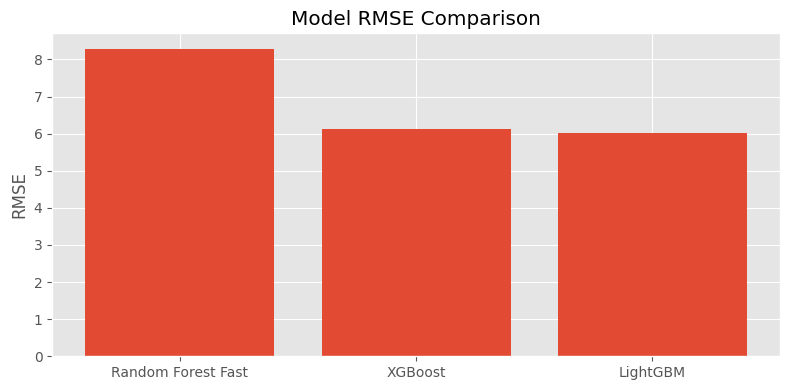

In [76]:
# RMSE COMPARISON
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(

    results_df['model'],

    results_df['rmse']
)

ax.set_title(
    'Model RMSE Comparison'
)

ax.set_ylabel('RMSE')

plt.tight_layout()

plt.show()

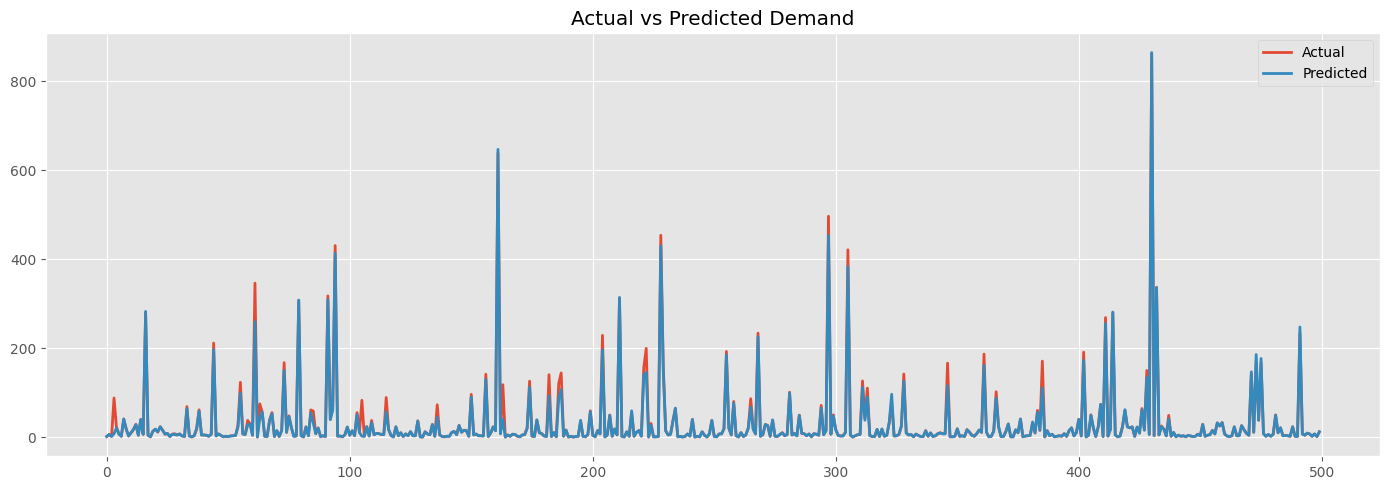

In [77]:
# ACTUAL VS PREDICTED

sample_size = 500
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    y_test.values[:sample_size],
    label='Actual',
    linewidth=2
)
ax.plot(
    xgb_pred[:sample_size],
    label='Predicted',
    linewidth=2
)
ax.set_title(
    'Actual vs Predicted Demand'
)

ax.legend()

plt.tight_layout()

plt.show()

In [78]:
importance_df = pd.DataFrame({

    'feature': X_train.columns,

    'importance':
        xgb_model.feature_importances_
})

importance_df = (

    importance_df

    .sort_values(
        'importance',
        ascending=False
    )
)

display(
    importance_df.head(20)
)

,feature,importance
8,volume,0.583776
21,volume_roll_mean_3,0.346770
11,price,0.038678
14,volume_lag_2,0.013139
33,betweenness_centrality,0.006026
12,count,0.001587
28,congestion_index,0.001557
29,demand_pressure,0.000947
10,duration,0.000830
18,occupancy_lag_1,0.000714


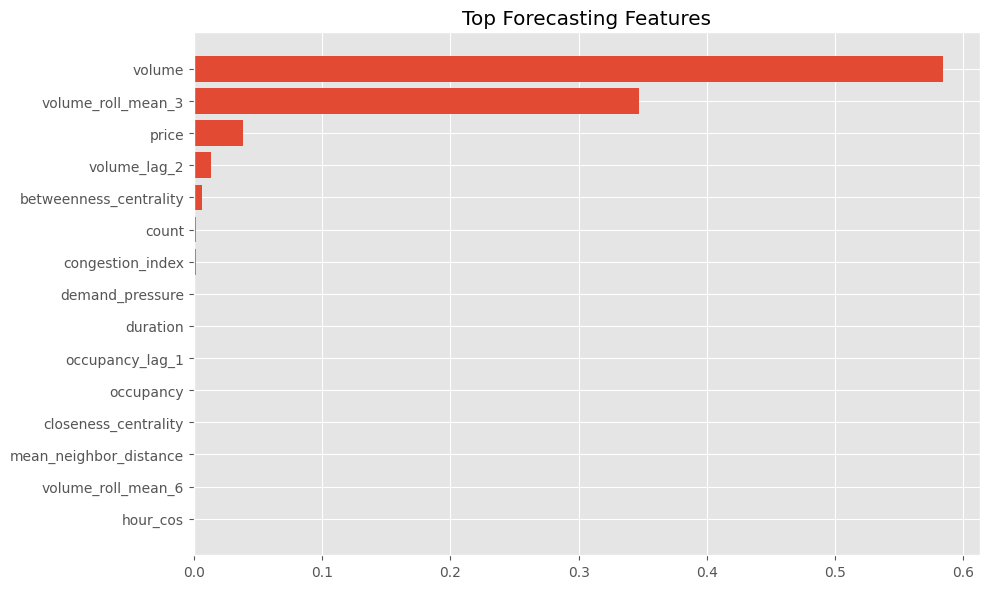

In [79]:
# ============================================================
# TOP FEATURES
# ============================================================

top_features = (
    importance_df
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(

    top_features['feature'],

    top_features['importance']
)

ax.set_title(
    'Top Forecasting Features'
)

ax.invert_yaxis()

plt.tight_layout()

plt.show()

In [80]:
# PEAK HOUR PERFORMANCE
peak_mask = (
    test_df['hour']
    .isin([7,8,9,17,18,19,20])
)

peak_actual = y_test[peak_mask]

peak_pred = xgb_pred[peak_mask]

peak_results = evaluate_forecast(

    peak_actual,

    peak_pred,

    'XGBoost Peak Hours'
)

XGBoost Peak Hours
MAE  : 1.6014
RMSE : 6.0598
R²   : 0.9961
MAPE : 3.93%


In [81]:
# HIGH CONGESTION PERFORMANCE
congestion_mask = (
    test_df['occupancy'] > 0.8
)

cong_actual = y_test[
    congestion_mask
]

cong_pred = xgb_pred[
    congestion_mask
]

cong_results = evaluate_forecast(

    cong_actual,

    cong_pred,

    'XGBoost High Congestion'
)

XGBoost High Congestion
MAE  : 1.5757
RMSE : 6.1739
R²   : 0.9966
MAPE : 3.10%


In [82]:
# SAVE MODELS
import joblib

joblib.dump(

    rf_model,

    MODEL_DIR / 'random_forest.pkl'
)

joblib.dump(

    xgb_model,

    MODEL_DIR / 'xgboost.pkl'
)

joblib.dump(

    lgb_model,

    MODEL_DIR / 'lightgbm.pkl'
)

print("Models saved successfully.")

Models saved successfully.


In [83]:
# ============================================================
# SAVE RESULTS
# ============================================================

results_df.to_csv(

    OUTPUT_DIR / 'forecast_results.csv',

    index=False
)

importance_df.to_csv(

    OUTPUT_DIR / 'feature_importance.csv',

    index=False
)

print("Forecasting outputs saved.")

Forecasting outputs saved.


In [84]:
# ============================================================
# ENSEMBLE FORECAST
# ============================================================

ensemble_pred = (

    0.50 * xgb_pred +

    0.35 * lgb_pred +

    0.15 * rf_pred
)

In [85]:
# ============================================================
# ENSEMBLE EVALUATION
# ============================================================

ensemble_results = evaluate_forecast(

    y_test,

    ensemble_pred,

    'Ensemble Forecast'
)

Ensemble Forecast
MAE  : 1.5122
RMSE : 5.9498
R²   : 0.9968
MAPE : 3.82%


In [86]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame([

    rf_results,

    xgb_results,

    lgb_results,

    ensemble_results
])

display(results_df)

,model,mae,rmse,r2,mape
0,Random Forest Fast,2.303469,8.289709,0.993832,7.432277
1,XGBoost,1.547925,6.114628,0.996644,3.251356
2,LightGBM,1.518430,6.006933,0.996761,3.925928
3,Ensemble Forecast,1.512246,5.949809,0.996823,3.824514


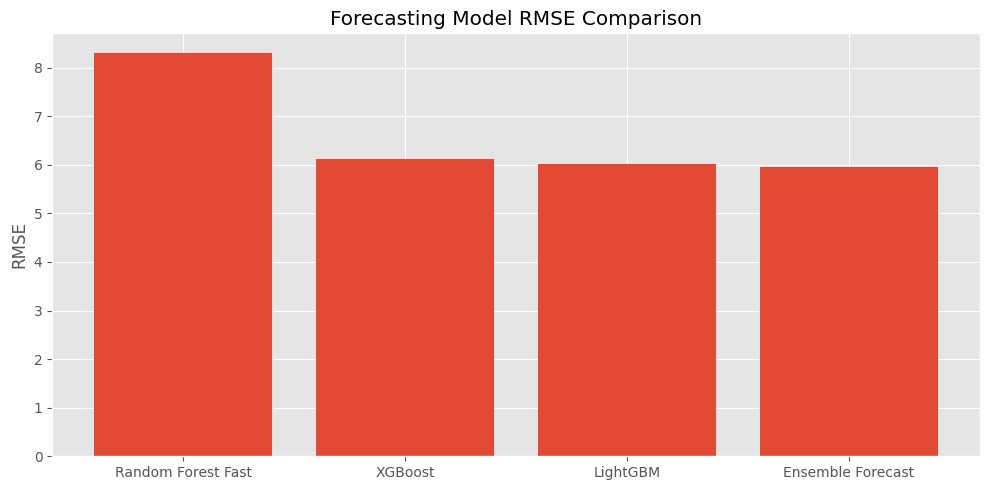

In [87]:
# ============================================================
# MODEL COMPARISON VISUALIZATION
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(

    results_df['model'],

    results_df['rmse']
)

ax.set_title(
    'Forecasting Model RMSE Comparison'
)

ax.set_ylabel('RMSE')

plt.tight_layout()

plt.show()

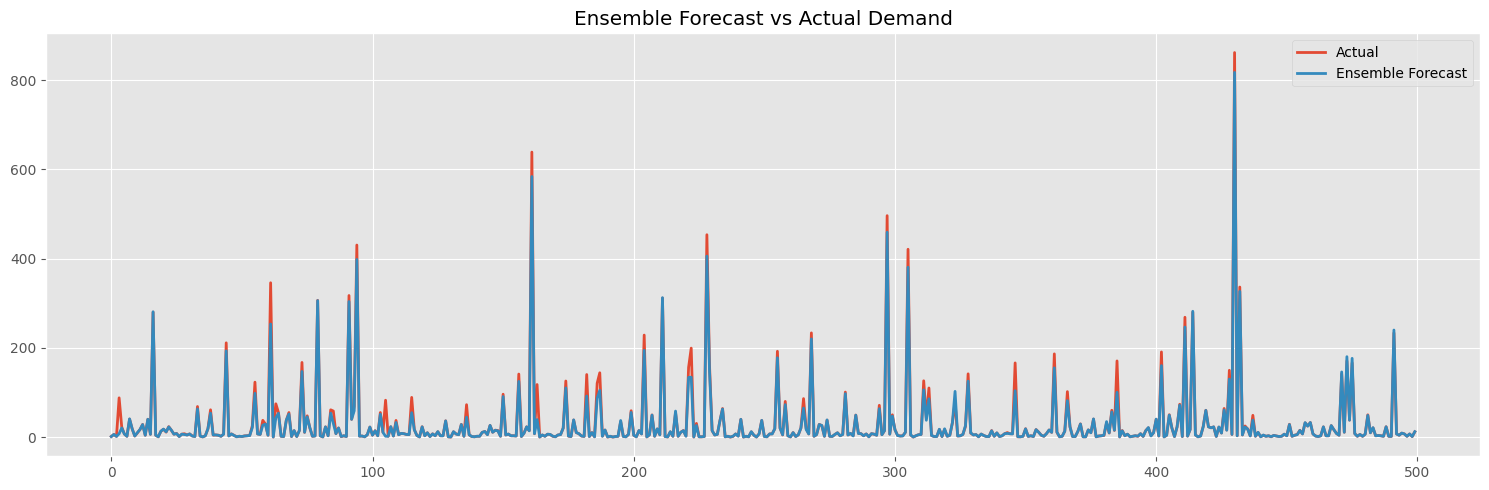

In [88]:
# ============================================================
# ENSEMBLE VISUALIZATION
# ============================================================

sample_size = 500

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(

    y_test.values[:sample_size],

    label='Actual',

    linewidth=2
)

ax.plot(

    ensemble_pred[:sample_size],

    label='Ensemble Forecast',

    linewidth=2
)

ax.set_title(
    'Ensemble Forecast vs Actual Demand'
)

ax.legend()

plt.tight_layout()

plt.show()

In [89]:
# ============================================================
# FORECAST UNCERTAINTY
# ============================================================

pred_matrix = np.vstack([

    rf_pred,

    xgb_pred,

    lgb_pred
])

prediction_std = pred_matrix.std(axis=0)

print(prediction_std[:10])

[0.02052472 0.15396094 0.02500126 0.05087346 0.20911679 0.09602092
 0.09617289 0.17266638 0.36193922 0.04183659]


In [90]:
# ============================================================
# CONFIDENCE INTERVALS
# ============================================================

upper_bound = (
    ensemble_pred +
    1.96 * prediction_std
)

lower_bound = (
    ensemble_pred -
    1.96 * prediction_std
)

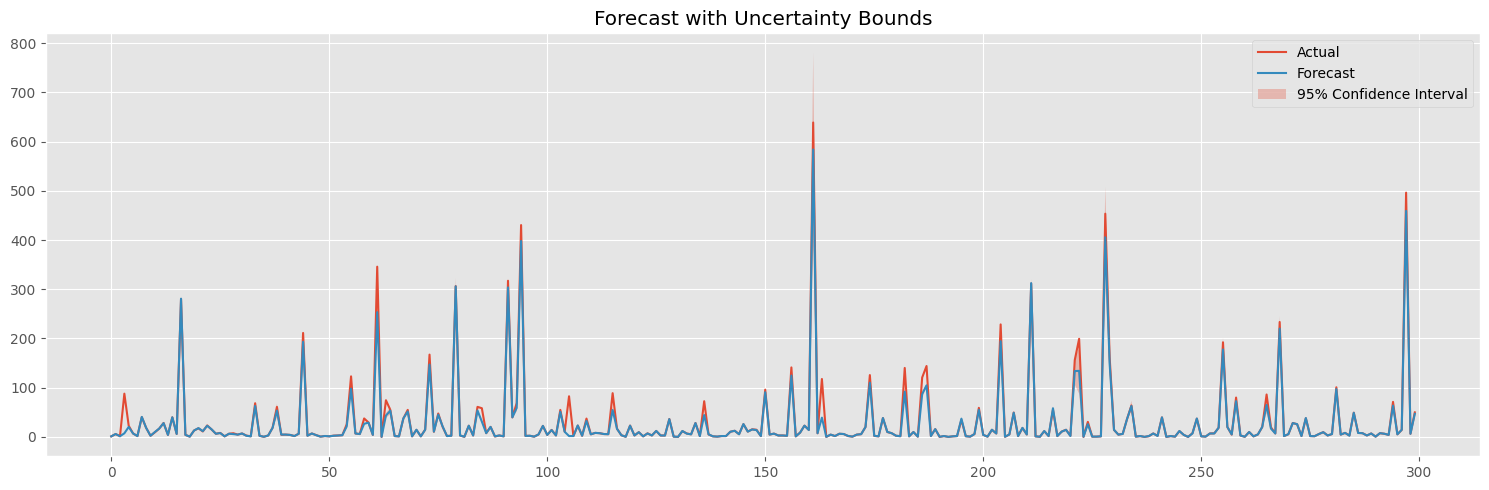

In [91]:
# ============================================================
# FORECAST UNCERTAINTY VISUALIZATION
# ============================================================

sample_size = 300

fig, ax = plt.subplots(figsize=(15, 5))

x_axis = np.arange(sample_size)

actual_vals = y_test.values[:sample_size]

pred_vals = ensemble_pred[:sample_size]

upper_vals = upper_bound[:sample_size]

lower_vals = lower_bound[:sample_size]

ax.plot(

    x_axis,

    actual_vals,

    label='Actual'
)

ax.plot(

    x_axis,

    pred_vals,

    label='Forecast'
)

ax.fill_between(

    x_axis,

    lower_vals,

    upper_vals,

    alpha=0.3,

    label='95% Confidence Interval'
)

ax.set_title(
    'Forecast with Uncertainty Bounds'
)

ax.legend()

plt.tight_layout()

plt.show()

In [92]:
# ============================================================
# MULTI-HORIZON TARGETS
# ============================================================

horizons = [1, 3, 6, 12]

for h in horizons:

    master_df[f'target_t_plus_{h}'] = (

        master_df

        .groupby('station_id')['volume']

        .shift(-h)
    )

In [93]:
# ============================================================
# CONGESTION LABEL
# ============================================================

master_df['high_congestion'] = (

    master_df['occupancy'] > 0.8

).astype(int)

print(
    master_df['high_congestion']
    .value_counts()
)

high_congestion
1    2084250
0      49583
Name: count, dtype: int64


In [94]:
# ============================================================
# SAVE ENSEMBLE RESULTS
# ============================================================

results_df.to_csv(

    OUTPUT_DIR / 'ensemble_results.csv',

    index=False
)

forecast_df = pd.DataFrame({

    'actual': y_test.values,

    'ensemble_prediction': ensemble_pred,

    'uncertainty_std': prediction_std,

    'upper_bound': upper_bound,

    'lower_bound': lower_bound
})

forecast_df.to_csv(

    OUTPUT_DIR / 'forecast_uncertainty.csv',

    index=False
)

print("Ensemble outputs saved.")

Ensemble outputs saved.


In [95]:
# ============================================================
# FORECAST INTEGRATION
# ============================================================

test_df = test_df.copy()

test_df['predicted_volume'] = ensemble_pred

test_df['forecast_uncertainty'] = prediction_std

display(test_df.head())

,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,volume,occupancy,duration,price,count,volume_lag_1,volume_lag_2,volume_lag_3,volume_lag_6,volume_lag_12,occupancy_lag_1,occupancy_lag_2,occupancy_lag_3,volume_roll_mean_3,volume_roll_mean_6,volume_roll_mean_12,volume_roll_std_3,volume_roll_std_6,occupancy_roll_mean_3,occupancy_roll_mean_6,congestion_index,demand_pressure,neighbor_pressure,distance_weighted_neighbor_pressure,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coeff,node_degree,network_health_score,nearest_neighbor_distance,mean_neighbor_distance,target_volume,timestamp,station_id,time_regime,predicted_volume,forecast_uncertainty
1813758,11,3,7,0,0.258819,-0.965926,0.433884,-0.900969,1.166667,3,0.166667,1.150000,34.0,1.166667,1.166667,1.166667,1.166667,1.166667,3.0,3.0,3.0,1.166667,1.166667,1.166667,0.0,0.000000,3.000000,3.000000,3.500000,1.000000,33.400002,18.000000,0.024390,0.010911,0.071852,0.500000,6,0.317958,0.0,0.021812,1.166667,2022-07-14 11:55:00,115,midday,1.188919,0.020525
1813759,11,3,7,0,0.258819,-0.965926,0.433884,-0.900969,5.833333,10,0.833333,1.096667,47.0,5.833333,5.833333,5.833333,5.833333,10.833333,10.0,10.0,10.0,5.833333,5.833333,7.216667,0.0,0.000000,10.000000,10.000000,58.333333,3.181818,4.333333,14.478261,0.016260,0.000299,0.018477,0.000000,4,0.455665,0.0,0.009401,5.833333,2022-07-14 11:55:00,643,midday,5.877522,0.153961
1813760,11,3,7,0,0.258819,-0.965926,0.433884,-0.900969,1.458333,3,0.250000,0.750000,6.0,1.458333,1.458333,1.458333,1.458333,1.458333,3.0,3.0,3.0,1.458333,1.458333,1.458333,0.0,0.000000,3.000000,3.000000,4.375000,1.166667,29.166668,14.695652,0.028455,0.000426,0.076987,0.700000,7,0.255094,0.0,0.053428,1.458333,2022-07-14 11:55:00,1092,midday,1.454105,0.025001
1813761,11,3,7,0,0.258819,-0.965926,0.433884,-0.900969,7.291667,17,1.083333,1.110000,47.0,7.291667,7.291667,7.291667,7.291667,12.291667,15.0,14.0,14.0,7.291667,7.291667,8.675000,0.0,0.000000,15.333333,14.666667,123.958333,3.500000,19.571430,14.478261,0.032520,0.013664,0.093313,0.466667,8,0.414752,0.0,0.009401,87.869444,2022-07-14 11:55:00,799,midday,7.329936,0.050873
1813762,11,3,7,0,0.258819,-0.965926,0.433884,-0.900969,20.458333,40,2.500000,1.075000,47.0,20.458333,20.458333,19.180556,16.625000,16.811667,40.0,39.0,38.0,20.458333,18.967593,17.796296,0.0,1.880838,39.666667,38.500000,818.333333,5.845238,24.250000,14.478261,0.020325,0.005964,0.119902,0.666667,5,0.197465,0.0,0.009401,22.637222,2022-07-14 11:55:00,724,midday,20.279554,0.209117


In [96]:
# ============================================================
# CONGESTION RISK SCORE
# NORMALIZED VERSION
# ============================================================

test_df['predicted_volume_norm'] = (
    test_df['predicted_volume'] - test_df['predicted_volume'].min()
) / (test_df['predicted_volume'].max() - test_df['predicted_volume'].min() + 1e-6)

test_df['occupancy_norm'] = (
    test_df['occupancy'] - test_df['occupancy'].min()
) / (test_df['occupancy'].max() - test_df['occupancy'].min() + 1e-6)

test_df['neighbor_pressure_norm'] = (
    test_df['neighbor_pressure'] - test_df['neighbor_pressure'].min()
) / (test_df['neighbor_pressure'].max() - test_df['neighbor_pressure'].min() + 1e-6)

test_df['network_health_norm'] = (
    test_df['network_health_score'] - test_df['network_health_score'].min()
) / (test_df['network_health_score'].max() - test_df['network_health_score'].min() + 1e-6)

test_df['forecast_uncertainty_norm'] = (
    test_df['forecast_uncertainty'] - test_df['forecast_uncertainty'].min()
) / (test_df['forecast_uncertainty'].max() - test_df['forecast_uncertainty'].min() + 1e-6)

test_df['congestion_risk_score'] = (
    0.35 * test_df['occupancy_norm'] +
    0.25 * test_df['predicted_volume_norm'] +
    0.15 * test_df['neighbor_pressure_norm'] +
    0.10 * test_df['network_health_norm'] +
    0.15 * test_df['forecast_uncertainty_norm']
)

test_df['congestion_risk_score'] = (
    test_df['congestion_risk_score'].clip(0, 1)
)

In [97]:
# ============================================================
# NORMALIZE RISK
# ============================================================

risk_min = (
    test_df['congestion_risk_score']
    .min()
)

risk_max = (
    test_df['congestion_risk_score']
    .max()
)

test_df['congestion_risk_score'] = (

    (
        test_df['congestion_risk_score']
        - risk_min
    )

    /

    (
        risk_max - risk_min + 1e-6
    )
)

In [98]:
# DYNAMIC PRICING POLICY
BASE_PRICE = test_df['price'].median()
def tariff_policy(row):
    risk = row['congestion_risk_score']
    occupancy = row['occupancy']
    regime = row['time_regime']
    # EXTREME CONGESTION
    if risk >= 0.85:
        multiplier = 1.60
    # HIGH CONGESTION
    elif risk >= 0.70:
        multiplier = 1.35
    # MODERATE CONGESTION
    elif risk >= 0.50:
        multiplier = 1.15
    # LOW DEMAND
    elif risk <= 0.20:
        multiplier = 0.75

    # VERY LOW DEMAND

    elif risk <= 0.10:

        multiplier = 0.60

    else:

        multiplier = 1.0
    # OFFPEAK INCENTIVES

    if regime == 'low_night':

        multiplier *= 0.85

    # CRITICAL NETWORK HUB PROTECTION
    if row['network_health_score'] > (
        test_df['network_health_score']
        .quantile(0.90)
    ):
        multiplier *= 1.10
    optimized_price = (
        BASE_PRICE * multiplier
    )
    return optimized_price

In [99]:
# APPLY TARIFF POLICY
test_df['optimized_tariff'] = (
    test_df
    .apply(
        tariff_policy,
        axis=1
    )
)
display(
    test_df[[
        'price',
        'optimized_tariff',
        'occupancy',
        'predicted_volume',
        'congestion_risk_score'
    ]].head()
)

,price,optimized_tariff,occupancy,predicted_volume,congestion_risk_score
1813758,1.150000,0.740588,3,1.188919,0.129215
1813759,1.096667,0.740588,10,5.877522,0.099874
1813760,0.750000,0.740588,3,1.454105,0.109218
1813761,1.110000,0.740588,17,7.329936,0.148459
1813762,1.075000,0.740588,40,20.279554,0.188466


In [100]:
# STEP 1 — SAFE WORKING COPY

decision_df = test_df.copy().reset_index(drop=True)

# Basic cleanup
decision_df['station_id'] = decision_df['station_id'].astype(str)

# Merge 'count' from the information DataFrame to ensure it's present
# 'num' in information corresponds to 'station_id'
if 'count' not in decision_df.columns and 'information' in globals():
    station_counts = information[['num', 'count']].rename(columns={'num': 'station_id'})
    station_counts['station_id'] = station_counts['station_id'].astype(str)
    decision_df = decision_df.merge(
        station_counts,
        on='station_id',
        how='left'
    )

# Fill any remaining missing values in key columns
for col in ['occupancy', 'neighbor_pressure', 'network_health_score', 'forecast_uncertainty', 'price', 'predicted_volume', 'count']:
    if col in decision_df.columns:
        decision_df[col] = decision_df[col].fillna(0)

display(decision_df.head())

,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,volume,occupancy,duration,price,count,volume_lag_1,volume_lag_2,volume_lag_3,volume_lag_6,volume_lag_12,occupancy_lag_1,occupancy_lag_2,occupancy_lag_3,volume_roll_mean_3,volume_roll_mean_6,volume_roll_mean_12,volume_roll_std_3,volume_roll_std_6,occupancy_roll_mean_3,occupancy_roll_mean_6,congestion_index,demand_pressure,neighbor_pressure,distance_weighted_neighbor_pressure,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coeff,node_degree,network_health_score,nearest_neighbor_distance,mean_neighbor_distance,target_volume,timestamp,station_id,time_regime,predicted_volume,forecast_uncertainty,predicted_volume_norm,occupancy_norm,neighbor_pressure_norm,network_health_norm,forecast_uncertainty_norm,congestion_risk_score,optimized_tariff
0,11,3,7,0,0.258819,-0.965926,0.433884,-0.900969,1.166667,3,0.166667,1.150000,34.0,1.166667,1.166667,1.166667,1.166667,1.166667,3.0,3.0,3.0,1.166667,1.166667,1.166667,0.0,0.000000,3.000000,3.000000,3.500000,1.000000,33.400002,18.000000,0.024390,0.010911,0.071852,0.500000,6,0.317958,0.0,0.021812,1.166667,2022-07-14 11:55:00,115,midday,1.188919,0.020525,0.000717,0.014019,0.344330,0.317959,0.000158,0.129215,0.740588
1,11,3,7,0,0.258819,-0.965926,0.433884,-0.900969,5.833333,10,0.833333,1.096667,47.0,5.833333,5.833333,5.833333,5.833333,10.833333,10.0,10.0,10.0,5.833333,5.833333,7.216667,0.0,0.000000,10.000000,10.000000,58.333333,3.181818,4.333333,14.478261,0.016260,0.000299,0.018477,0.000000,4,0.455665,0.0,0.009401,5.833333,2022-07-14 11:55:00,643,midday,5.877522,0.153961,0.003991,0.046729,0.044674,0.455666,0.001206,0.099874,0.740588
2,11,3,7,0,0.258819,-0.965926,0.433884,-0.900969,1.458333,3,0.250000,0.750000,6.0,1.458333,1.458333,1.458333,1.458333,1.458333,3.0,3.0,3.0,1.458333,1.458333,1.458333,0.0,0.000000,3.000000,3.000000,4.375000,1.166667,29.166668,14.695652,0.028455,0.000426,0.076987,0.700000,7,0.255094,0.0,0.053428,1.458333,2022-07-14 11:55:00,1092,midday,1.454105,0.025001,0.000902,0.014019,0.300687,0.255094,0.000193,0.109218,0.740588
3,11,3,7,0,0.258819,-0.965926,0.433884,-0.900969,7.291667,17,1.083333,1.110000,47.0,7.291667,7.291667,7.291667,7.291667,12.291667,15.0,14.0,14.0,7.291667,7.291667,8.675000,0.0,0.000000,15.333333,14.666667,123.958333,3.500000,19.571430,14.478261,0.032520,0.013664,0.093313,0.466667,8,0.414752,0.0,0.009401,87.869444,2022-07-14 11:55:00,799,midday,7.329936,0.050873,0.005005,0.079439,0.201767,0.414753,0.000396,0.148459,0.740588
4,11,3,7,0,0.258819,-0.965926,0.433884,-0.900969,20.458333,40,2.500000,1.075000,47.0,20.458333,20.458333,19.180556,16.625000,16.811667,40.0,39.0,38.0,20.458333,18.967593,17.796296,0.0,1.880838,39.666667,38.500000,818.333333,5.845238,24.250000,14.478261,0.020325,0.005964,0.119902,0.666667,5,0.197465,0.0,0.009401,22.637222,2022-07-14 11:55:00,724,midday,20.279554,0.209117,0.014049,0.186916,0.250000,0.197466,0.001639,0.188466,0.740588


In [101]:
# STEP 2 — DEFINE AGENTS

def forecast_agent(row):
    return {
        'predicted_volume': row['predicted_volume'],
        'forecast_uncertainty': row['forecast_uncertainty']
    }


def congestion_agent(row, max_predicted_volume):
    predicted_norm = row['predicted_volume'] / (max_predicted_volume + 1e-6)

    risk_score = (
        0.35 * row['occupancy'] +
        0.25 * predicted_norm +
        0.15 * row['neighbor_pressure'] +
        0.15 * row['network_health_score'] +
        0.10 * (row['forecast_uncertainty'] / (decision_df['forecast_uncertainty'].max() + 1e-6))
    )

    if risk_score >= 0.80:
        status = 'critical'
    elif risk_score >= 0.60:
        status = 'high'
    elif risk_score >= 0.40:
        status = 'moderate'
    else:
        status = 'low'

    return {
        'risk_score': risk_score,
        'risk_status': status
    }


def tariff_agent(row):
    risk = row['congestion_risk_score']
    current_price = row['price']

    if risk >= 0.85:
        action = 'surge_pricing'
        multiplier = 1.60
    elif risk >= 0.70:
        action = 'increase_price'
        multiplier = 1.30
    elif risk <= 0.20:
        action = 'discount_pricing'
        multiplier = 0.75
    else:
        action = 'maintain_price'
        multiplier = 1.00

    optimized_tariff = current_price * multiplier

    return {
        'pricing_action': action,
        'optimized_tariff': optimized_tariff
    }


def recommendation_agent(row, high_network_threshold, high_uncertainty_threshold):
    recommendations = []

    if row['occupancy'] > 0.85:
        recommendations.append('redistribute_load')

    if row['network_health_score'] > high_network_threshold:
        recommendations.append('protect_critical_hub')

    if row['forecast_uncertainty'] > high_uncertainty_threshold:
        recommendations.append('monitor_closely')

    if row['occupancy'] < 0.30:
        recommendations.append('promotional_pricing')

    if len(recommendations) == 0:
        recommendations.append('normal_operation')

    return recommendations


# ============================================================
# MONITORING AGENT
# NORMALIZED HEALTH SCORE
# ============================================================

def monitoring_agent(row):
    # Keep this bounded and interpretable
    occ = np.clip(row['occupancy'], 0, 1)

    risk = np.clip(row['congestion_risk_score'], 0, 1)

    net = np.clip(row['network_health_score'], 0, 1)

    health_score = (
        0.40 * (1 - occ) +
        0.35 * (1 - risk) +
        0.25 * (1 - net)
    )

    health_score = float(np.clip(health_score, 0, 1))

    if health_score >= 0.75:
        network_state = 'stable'
    elif health_score >= 0.50:
        network_state = 'moderate'
    else:
        network_state = 'unstable'

    return {
        'health_score': health_score,
        'network_state': network_state
    }

In [102]:
# STEP 3 — COORDINATOR AGENT

max_predicted_volume = decision_df['predicted_volume'].max()
high_network_threshold = decision_df['network_health_score'].quantile(0.90)
high_uncertainty_threshold = decision_df['forecast_uncertainty'].quantile(0.80)

def coordinator_agent(row):
    forecast_output = forecast_agent(row)
    congestion_output = congestion_agent(row, max_predicted_volume)

    # attach congestion score temporarily for tariff logic
    row = row.copy()
    row['congestion_risk_score'] = congestion_output['risk_score']

    tariff_output = tariff_agent(row)
    recommendation_output = recommendation_agent(
        row,
        high_network_threshold,
        high_uncertainty_threshold
    )
    monitoring_output = monitoring_agent(row)

    return {
        'predicted_volume': forecast_output['predicted_volume'],
        'forecast_uncertainty': forecast_output['forecast_uncertainty'],
        'congestion_risk_score': congestion_output['risk_score'],
        'congestion_status': congestion_output['risk_status'],
        'pricing_action': tariff_output['pricing_action'],
        'optimized_tariff': tariff_output['optimized_tariff'],
        'health_score': monitoring_output['health_score'],
        'network_state': monitoring_output['network_state'],
        'recommendations': recommendation_output
    }

In [103]:
# STEP 4 — APPLY MULTI-AGENT SYSTEM

agent_outputs = decision_df.apply(coordinator_agent, axis=1, result_type='expand')
display(agent_outputs.head())

,predicted_volume,forecast_uncertainty,congestion_risk_score,congestion_status,pricing_action,optimized_tariff,health_score,network_state,recommendations
0,1.188919,0.020525,6.107918,critical,surge_pricing,1.840000,0.170510,unstable,[redistribute_load]
1,5.877522,0.153961,4.219497,critical,surge_pricing,1.754667,0.136084,unstable,[redistribute_load]
2,1.454105,0.025001,5.463538,critical,surge_pricing,1.200000,0.186227,unstable,[redistribute_load]
3,7.329936,0.050873,8.949247,critical,surge_pricing,1.776000,0.146312,unstable,[redistribute_load]
4,20.279554,0.209117,17.670824,critical,surge_pricing,1.720000,0.200634,unstable,[redistribute_load]


In [104]:
# STEP 5 — MERGE OUTPUTS
# Ensure decision_df does not have a congestion_risk_score column before merging with agent_outputs
# The congestion_risk_score from agent_outputs is the desired one.
cols_to_keep_from_decision_df = [
    col for col in decision_df.columns if col != 'congestion_risk_score'
]
decision_df_filtered = decision_df[cols_to_keep_from_decision_df].reset_index(drop=True)

# Rename the congestion_risk_score from agent_outputs to avoid any conflict
agent_outputs_renamed = agent_outputs.rename(
    columns={'congestion_risk_score': 'multi_agent_congestion_risk_score'}
).reset_index(drop=True)

final_decision_df = pd.concat(
    [decision_df_filtered, agent_outputs_renamed],
    axis=1
)

# Ensure the index is unique before operations that rely on it
if not final_decision_df.index.is_unique:
    final_decision_df = final_decision_df.reset_index(drop=True)

display(final_decision_df.head())
print(final_decision_df.shape)

,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,volume,occupancy,duration,price,count,volume_lag_1,volume_lag_2,volume_lag_3,volume_lag_6,volume_lag_12,occupancy_lag_1,occupancy_lag_2,occupancy_lag_3,volume_roll_mean_3,volume_roll_mean_6,volume_roll_mean_12,volume_roll_std_3,volume_roll_std_6,occupancy_roll_mean_3,occupancy_roll_mean_6,congestion_index,demand_pressure,neighbor_pressure,distance_weighted_neighbor_pressure,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coeff,node_degree,network_health_score,nearest_neighbor_distance,mean_neighbor_distance,target_volume,timestamp,station_id,time_regime,predicted_volume,forecast_uncertainty,predicted_volume_norm,occupancy_norm,neighbor_pressure_norm,network_health_norm,forecast_uncertainty_norm,optimized_tariff,predicted_volume,forecast_uncertainty,multi_agent_congestion_risk_score,congestion_status,pricing_action,optimized_tariff,health_score,network_state,recommendations
0,11,3,7,0,0.258819,-0.965926,0.433884,-0.900969,1.166667,3,0.166667,1.150000,34.0,1.166667,1.166667,1.166667,1.166667,1.166667,3.0,3.0,3.0,1.166667,1.166667,1.166667,0.0,0.000000,3.000000,3.000000,3.500000,1.000000,33.400002,18.000000,0.024390,0.010911,0.071852,0.500000,6,0.317958,0.0,0.021812,1.166667,2022-07-14 11:55:00,115,midday,1.188919,0.020525,0.000717,0.014019,0.344330,0.317959,0.000158,0.740588,1.188919,0.020525,6.107918,critical,surge_pricing,1.840000,0.170510,unstable,[redistribute_load]
1,11,3,7,0,0.258819,-0.965926,0.433884,-0.900969,5.833333,10,0.833333,1.096667,47.0,5.833333,5.833333,5.833333,5.833333,10.833333,10.0,10.0,10.0,5.833333,5.833333,7.216667,0.0,0.000000,10.000000,10.000000,58.333333,3.181818,4.333333,14.478261,0.016260,0.000299,0.018477,0.000000,4,0.455665,0.0,0.009401,5.833333,2022-07-14 11:55:00,643,midday,5.877522,0.153961,0.003991,0.046729,0.044674,0.455666,0.001206,0.740588,5.877522,0.153961,4.219497,critical,surge_pricing,1.754667,0.136084,unstable,[redistribute_load]
2,11,3,7,0,0.258819,-0.965926,0.433884,-0.900969,1.458333,3,0.250000,0.750000,6.0,1.458333,1.458333,1.458333,1.458333,1.458333,3.0,3.0,3.0,1.458333,1.458333,1.458333,0.0,0.000000,3.000000,3.000000,4.375000,1.166667,29.166668,14.695652,0.028455,0.000426,0.076987,0.700000,7,0.255094,0.0,0.053428,1.458333,2022-07-14 11:55:00,1092,midday,1.454105,0.025001,0.000902,0.014019,0.300687,0.255094,0.000193,0.740588,1.454105,0.025001,5.463538,critical,surge_pricing,1.200000,0.186227,unstable,[redistribute_load]
3,11,3,7,0,0.258819,-0.965926,0.433884,-0.900969,7.291667,17,1.083333,1.110000,47.0,7.291667,7.291667,7.291667,7.291667,12.291667,15.0,14.0,14.0,7.291667,7.291667,8.675000,0.0,0.000000,15.333333,14.666667,123.958333,3.500000,19.571430,14.478261,0.032520,0.013664,0.093313,0.466667,8,0.414752,0.0,0.009401,87.869444,2022-07-14 11:55:00,799,midday,7.329936,0.050873,0.005005,0.079439,0.201767,0.414753,0.000396,0.740588,7.329936,0.050873,8.949247,critical,surge_pricing,1.776000,0.146312,unstable,[redistribute_load]
4,11,3,7,0,0.258819,-0.965926,0.433884,-0.900969,20.458333,40,2.500000,1.075000,47.0,20.458333,20.458333,19.180556,16.625000,16.811667,40.0,39.0,38.0,20.458333,18.967593,17.796296,0.0,1.880838,39.666667,38.500000,818.333333,5.845238,24.250000,14.478261,0.020325,0.005964,0.119902,0.666667,5,0.197465,0.0,0.009401,22.637222,2022-07-14 11:55:00,724,midday,20.279554,0.209117,0.014049,0.186916,0.250000,0.197466,0.001639,0.740588,20.279554,0.209117,17.670824,critical,surge_pricing,1.720000,0.200634,unstable,[redistribute_load]


(320075, 61)


In [105]:
# STEP 6 — REVENUE SIMULATION
final_decision_df['baseline_revenue'] = final_decision_df['price'].values * final_decision_df['volume'].values
final_decision_df['optimized_revenue'] = final_decision_df['optimized_tariff'].values[:, 0] * final_decision_df['volume'].values

baseline_rev = final_decision_df['baseline_revenue'].sum()
optimized_rev = final_decision_df['optimized_revenue'].sum()

revenue_gain_pct = ((optimized_rev - baseline_rev) / (baseline_rev + 1e-6)) * 100

print("Baseline Revenue:", baseline_rev)
print("Optimized Revenue:", optimized_rev)
print("Revenue Gain (%):", revenue_gain_pct)

Baseline Revenue: 10839429.868614765
Optimized Revenue: 12440015.281806037
Revenue Gain (%): 14.766324729177594


In [108]:
# STEP 7 — OPERATIONAL EVALUATION

# Ensure 'station_id' in final_decision_df is string for consistent merging
if 'station_id' in final_decision_df.columns:
    final_decision_df['station_id'] = final_decision_df['station_id'].astype(str)

# Explicitly ensure 'count' column is present and correct in final_decision_df
# This addresses persistent KeyError issues by re-merging if necessary.
if 'information' in globals() and 'num' in information.columns and 'count' in information.columns:
    station_counts_from_info = information[['num', 'count']].rename(columns={'num': 'station_id'})
    station_counts_from_info['station_id'] = station_counts_from_info['station_id'].astype(str)

    # Perform a left merge to bring 'count' from information, if not already correctly present
    # Use suffixes to handle potential existing 'count' columns gracefully
    merged_final_decision_df = final_decision_df.merge(
        station_counts_from_info,
        on='station_id',
        how='left',
        suffixes=('', '_from_info')
    )

    # Prioritize the newly merged 'count' if it's more complete or if the original was missing
    if 'count_from_info' in merged_final_decision_df.columns:
        # If an original 'count' column existed, use info's count to fill NaNs, otherwise just use info's count
        if 'count' in merged_final_decision_df.columns:
            merged_final_decision_df['count'] = merged_final_decision_df['count_from_info'].fillna(merged_final_decision_df['count'])
        else:
            merged_final_decision_df['count'] = merged_final_decision_df['count_from_info']
        merged_final_decision_df.drop(columns=['count_from_info'], inplace=True)
    elif 'count' not in merged_final_decision_df.columns:
        # Fallback if no 'count' at all after merge (shouldn't happen with how='left')
        merged_final_decision_df['count'] = 0 # Default if merge somehow fails

    # Update final_decision_df with the merged version
    final_decision_df = merged_final_decision_df
else:
    # Fallback if information DataFrame or its columns are not available
    if 'count' not in final_decision_df.columns:
        print("Warning: 'information' DataFrame or required columns not found, or 'station_id' missing. Initializing 'count' with 0.")
        final_decision_df['count'] = 0

# Remove duplicate columns (this should now happen AFTER 'count' is confirmed and deduped)
final_decision_df = final_decision_df.loc[
    :,
    ~final_decision_df.columns.duplicated()
]

# Fill any remaining NaNs in the 'count' column (should be numeric by now)
if 'count' in final_decision_df.columns:
    final_decision_df['count'] = pd.to_numeric(final_decision_df['count'], errors='coerce').fillna(0)
else:
    # If 'count' is still not there, add it as 0 to prevent KeyError later
    final_decision_df['count'] = 0

# Reset index
final_decision_df = final_decision_df.reset_index(drop=True)

# ------------------------------------------------------------
# Clean optimized_tariff column
# ------------------------------------------------------------

def extract_scalar(x):
    while isinstance(x, (np.ndarray, list, pd.Series)):
        if len(x) == 0:
            return np.nan
        x = x[0]
    return x

final_decision_df['optimized_tariff'] = (
    final_decision_df['optimized_tariff']
    .apply(extract_scalar)
)

final_decision_df['optimized_tariff'] = (
    pd.to_numeric(
        final_decision_df['optimized_tariff'],
        errors='coerce'
    )
    .fillna(0.0)
)

# ------------------------------------------------------------
# Price change %
# ------------------------------------------------------------

optimized_tariff_vals = (
    final_decision_df['optimized_tariff']
    .values
)

price_vals = (
    final_decision_df['price']
    .values
)

final_decision_df['price_change_pct'] = (
    (optimized_tariff_vals - price_vals)
    / (price_vals + 1e-6)
) * 100

# ------------------------------------------------------------
# Pricing efficiency
# ------------------------------------------------------------

final_decision_df['price_elasticity'] = -1.5

volume_vals = (
    final_decision_df['volume']
    .values
)

price_elasticity_vals = (
    final_decision_df['price_elasticity']
    .values
)

price_change_pct_vals = (
    final_decision_df['price_change_pct']
    .values
)

final_decision_df['theoretical_demand'] = (
    volume_vals
    * (
        1
        + (
            price_elasticity_vals
            * price_change_pct_vals
            / 100
        )
    )
)

# ------------------------------------------------------------
# Efficiency metric
# ------------------------------------------------------------

is_critical = (
    final_decision_df['congestion_status']
    .eq('critical')
    .values
)

predicted_volume_vals = (
    final_decision_df['predicted_volume']
    .values
)

theoretical_demand_vals = (
    final_decision_df['theoretical_demand']
    .values
)

predicted_volume_safe = (
    predicted_volume_vals + 1e-6
)

efficiency_critical = np.maximum(
    0,
    1 - (
        (predicted_volume_vals - theoretical_demand_vals)
        / predicted_volume_safe
    )
)

efficiency_non_critical = np.maximum(
    0,
    1 - (
        (theoretical_demand_vals - predicted_volume_vals)
        / predicted_volume_safe
    )
)

final_decision_df['efficiency_metric'] = np.where(
    is_critical,
    efficiency_critical,
    efficiency_non_critical
)

pricing_efficiency_score = (
    final_decision_df['efficiency_metric']
    .mean()
)

# ============================================================
# WAITING TIME PROXY
# NORMALIZED VERSION
# ============================================================

# Define eval_df before its first use
eval_df = final_decision_df

# Use bounded quantities only
occ_norm = (
    eval_df['occupancy'] - eval_df['occupancy'].min()
) / (eval_df['occupancy'].max() - eval_df['occupancy'].min() + 1e-6)

if 'neighbor_pressure' in eval_df.columns:
    np_raw = pd.to_numeric(eval_df['neighbor_pressure'], errors='coerce').fillna(0)
    np_norm = (
        np_raw - np_raw.min()
    ) / (np_raw.max() - np_raw.min() + 1e-6)
else:
    np_norm = 0

eval_df['waiting_time_proxy'] = (
    0.65 * occ_norm +
    0.35 * np_norm
)

mean_wait_proxy = eval_df['waiting_time_proxy'].mean()
high_wait_proxy = eval_df.loc[
    eval_df['waiting_time_proxy'] > eval_df['waiting_time_proxy'].quantile(0.90),
    'waiting_time_proxy'
].mean()

print("Mean Waiting-Time Proxy:", mean_wait_proxy)
print("High-Wait Proxy Mean:", high_wait_proxy)

# ------------------------------------------------------------
# Response strength
# ------------------------------------------------------------

response_strength = (
    final_decision_df['price_change_pct']
    .abs()
    .mean()
)

# ------------------------------------------------------------
# Summary metrics
# ------------------------------------------------------------

summary_metrics = {
    'mean_congestion_risk':
        final_decision_df[
            'multi_agent_congestion_risk_score'
        ].mean(),

    'mean_health_score':
        final_decision_df[
            'health_score'
        ].mean(),

    'mean_price_change_pct':
        final_decision_df[
            'price_change_pct'
        ].mean(),

    'stable_network_share':
        (
            final_decision_df['network_state']
            == 'stable'
        ).mean(),

    'moderate_network_share':
        (
            final_decision_df['network_state']
            == 'moderate'
        ).mean(),

    'unstable_network_share':
        (
            final_decision_df['network_state']
            == 'unstable'
        ).mean(),

    'pricing_efficiency_score':
        pricing_efficiency_score,

    'mean_wait_time_proxy':
        mean_wait_proxy,

    'response_strength':
        response_strength
}

summary_metrics

Mean Waiting-Time Proxy: 0.15268843865326914
High-Wait Proxy Mean: 0.40987506751030495


{'mean_congestion_risk': np.float64(11.454814746791754),
 'mean_health_score': np.float64(0.17220744813704772),
 'mean_price_change_pct': np.float64(-12.892505986132045),
 'stable_network_share': np.float64(0.000693587440443646),
 'moderate_network_share': np.float64(0.018267593532765757),
 'unstable_network_share': np.float64(0.9810388190267906),
 'pricing_efficiency_score': np.float64(1.1657307365635499),
 'mean_wait_time_proxy': np.float64(0.15268843865326914),
 'response_strength': np.float64(24.864326252839348)}

In [109]:
# STEP 8 — SAVE OUTPUTS

final_decision_df.to_csv(OUTPUT_DIR / 'multi_agent_decision_outputs.csv', index=False)

pd.DataFrame([summary_metrics]).to_csv(
    OUTPUT_DIR / 'multi_agent_summary_metrics.csv',
    index=False
)

print("Multi-agent outputs saved.")

Multi-agent outputs saved.


In [111]:
cols_to_view = [
    'station_id',
    'timestamp',
    'volume',
    'predicted_volume',
    'multi_agent_congestion_risk_score',
    'pricing_action',
    'optimized_tariff',
    'health_score',
    'network_state',
    'recommendations'
]

display(final_decision_df[cols_to_view].head(20))

,station_id,timestamp,volume,predicted_volume,multi_agent_congestion_risk_score,pricing_action,optimized_tariff,health_score,network_state,recommendations
0,115,2022-07-14 11:55:00,1.166667,1.188919,6.107918,surge_pricing,0.740588,0.170510,unstable,[redistribute_load]
1,643,2022-07-14 11:55:00,5.833333,5.877522,4.219497,surge_pricing,0.740588,0.136084,unstable,[redistribute_load]
2,1092,2022-07-14 11:55:00,1.458333,1.454105,5.463538,surge_pricing,0.740588,0.186227,unstable,[redistribute_load]
3,799,2022-07-14 11:55:00,7.291667,7.329936,8.949247,surge_pricing,0.740588,0.146312,unstable,[redistribute_load]
4,724,2022-07-14 11:55:00,20.458333,20.279554,17.670824,surge_pricing,0.740588,0.200634,unstable,[redistribute_load]
5,330,2022-07-14 11:55:00,7.000000,6.956981,9.198405,surge_pricing,0.740588,0.135760,unstable,[redistribute_load]
6,728,2022-07-14 11:55:00,1.750000,1.731607,2.366488,surge_pricing,0.740588,0.173150,unstable,[redistribute_load]
7,324,2022-07-14 11:55:00,40.250000,40.674726,35.428919,surge_pricing,0.987450,0.120112,unstable,[redistribute_load]
8,974,2022-07-14 11:55:00,18.083333,18.372447,15.171829,surge_pricing,0.987450,0.148009,unstable,[redistribute_load]
9,1134,2022-07-14 11:55:00,2.333333,2.385085,7.127169,surge_pricing,0.740588,0.163801,unstable,[redistribute_load]


In [112]:
summary_df = pd.DataFrame([summary_metrics])
eval_df = final_decision_df

summary_df.to_csv(OUTPUT_DIR / 'evaluation_summary.csv', index=False)
eval_df.to_csv(OUTPUT_DIR / 'evaluated_multi_agent_outputs.csv', index=False)

print("Saved evaluation outputs.")

Saved evaluation outputs.


In [113]:
print(type(final_decision_df['optimized_tariff']))

<class 'pandas.core.series.Series'>


In [114]:
# STEP 1 — FEATURE GROUPS FOR ABLATION
graph_features = [
    'degree_centrality',
    'betweenness_centrality',
    'closeness_centrality',
    'clustering_coeff',
    'node_degree',
    'network_health_score',
    'community_id'
]

spatial_features = [
    'nearest_neighbor_distance',
    'mean_neighbor_distance',
    'neighbor_pressure',
    'distance_weighted_neighbor_pressure'
]

uncertainty_features = [
    'forecast_uncertainty'
]

In [115]:
# STEP 2 — HELPER FUNCTION
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import xgboost as xgb
import pandas as pd

def train_eval_xgb(train_df, valid_df, test_df, features, target='target_volume'):
    X_train = train_df[features]
    y_train = train_df[target]

    X_valid = valid_df[features]
    y_valid = valid_df[target]

    X_test = test_df[features]
    y_test = test_df[target]

    model = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / np.maximum(np.abs(y_test), 1.0)))*100
    return {
        'model': 'XGBoost',
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'mape': mape,
        'predictions': pred,
        'model_obj': model
    }

In [116]:
# STEP 3 — FULL FEATURE SET
full_features = [c for c in feature_cols if c in train_df.columns]

print("Number of full features:", len(full_features))
print(full_features)

Number of full features: 40
['hour', 'dayofweek', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'volume', 'occupancy', 'duration', 'price', 'count', 'volume_lag_1', 'volume_lag_2', 'volume_lag_3', 'volume_lag_6', 'volume_lag_12', 'occupancy_lag_1', 'occupancy_lag_2', 'occupancy_lag_3', 'volume_roll_mean_3', 'volume_roll_mean_6', 'volume_roll_mean_12', 'volume_roll_std_3', 'volume_roll_std_6', 'occupancy_roll_mean_3', 'occupancy_roll_mean_6', 'congestion_index', 'demand_pressure', 'neighbor_pressure', 'distance_weighted_neighbor_pressure', 'degree_centrality', 'betweenness_centrality', 'closeness_centrality', 'clustering_coeff', 'node_degree', 'network_health_score', 'nearest_neighbor_distance', 'mean_neighbor_distance']


In [117]:
# STEP 4 — FULL MODEL
full_result = train_eval_xgb(train_df, valid_df, test_df, full_features)

print("FULL MODEL")
print("MAE :", full_result['mae'])
print("RMSE:", full_result['rmse'])
print("R2  :", full_result['r2'])
print("MAPE:", full_result['mape'])

FULL MODEL
MAE : 1.5762504371943287
RMSE: 6.248115209127426
R2  : 0.9964960925497037
MAPE: 3.3905583768427303


In [118]:
# STEP 5 — ABLATION: REMOVE GRAPH FEATURES
no_graph_features = [
    c for c in full_features
    if c not in graph_features
]

print("Features without graph:", len(no_graph_features))

no_graph_result = train_eval_xgb(train_df, valid_df, test_df, no_graph_features)

print("NO GRAPH MODEL")
print("MAE :", no_graph_result['mae'])
print("RMSE:", no_graph_result['rmse'])
print("R2  :", no_graph_result['r2'])
print("MAPE:", no_graph_result['mape'])

Features without graph: 34
NO GRAPH MODEL
MAE : 1.5812220168771092
RMSE: 6.285599215726201
R2  : 0.9964539248054124
MAPE: 3.397598902989069


In [119]:
# STEP 6 — ABLATION: REMOVE SPATIAL FEATURES
no_spatial_features = [
    c for c in full_features
    if c not in spatial_features
]

print("Features without spatial:", len(no_spatial_features))

no_spatial_result = train_eval_xgb(train_df, valid_df, test_df, no_spatial_features)

print("NO SPATIAL MODEL")
print("MAE :", no_spatial_result['mae'])
print("RMSE:", no_spatial_result['rmse'])
print("R2  :", no_spatial_result['r2'])
print("MAPE:", no_spatial_result['mape'])

Features without spatial: 36
NO SPATIAL MODEL
MAE : 1.5782362082596662
RMSE: 6.221390912587476
R2  : 0.9965260021151752
MAPE: 3.3856124137318138


In [120]:
# STEP 7 — ABLATION: REMOVE UNCERTAINTY FEATURES
no_uncertainty_features = [
    c for c in full_features
    if c not in uncertainty_features
]

print("Features without uncertainty:", len(no_uncertainty_features))

no_uncertainty_result = train_eval_xgb(train_df, valid_df, test_df, no_uncertainty_features)

print("NO UNCERTAINTY MODEL")
print("MAE :", no_uncertainty_result['mae'])
print("RMSE:", no_uncertainty_result['rmse'])
print("R2  :", no_uncertainty_result['r2'])
print("MAPE:", no_uncertainty_result['mape'])

Features without uncertainty: 40
NO UNCERTAINTY MODEL
MAE : 1.5762504371943287
RMSE: 6.248115209127426
R2  : 0.9964960925497037
MAPE: 3.3905583768427303


In [121]:
# STEP 8 — COMPARISON TABLE
ablation_results_df = pd.DataFrame([
    {
        'model': 'Full Model',
        'mae': full_result['mae'],
        'rmse': full_result['rmse'],
        'r2': full_result['r2'],
        'mape': full_result['mape']
    },
    {
        'model': 'No Graph Features',
        'mae': no_graph_result['mae'],
        'rmse': no_graph_result['rmse'],
        'r2': no_graph_result['r2'],
        'mape': no_graph_result['mape']
    },
    {
        'model': 'No Spatial Features',
        'mae': no_spatial_result['mae'],
        'rmse': no_spatial_result['rmse'],
        'r2': no_spatial_result['r2'],
        'mape': no_spatial_result['mape']
    },
    {
        'model': 'No Uncertainty Features',
        'mae': no_uncertainty_result['mae'],
        'rmse': no_uncertainty_result['rmse'],
        'r2': no_uncertainty_result['r2'],
        'mape': no_uncertainty_result['mape']
    }
])

display(ablation_results_df)

,model,mae,rmse,r2,mape
0,Full Model,1.576250,6.248115,0.996496,3.390558
1,No Graph Features,1.581222,6.285599,0.996454,3.397599
2,No Spatial Features,1.578236,6.221391,0.996526,3.385612
3,No Uncertainty Features,1.576250,6.248115,0.996496,3.390558


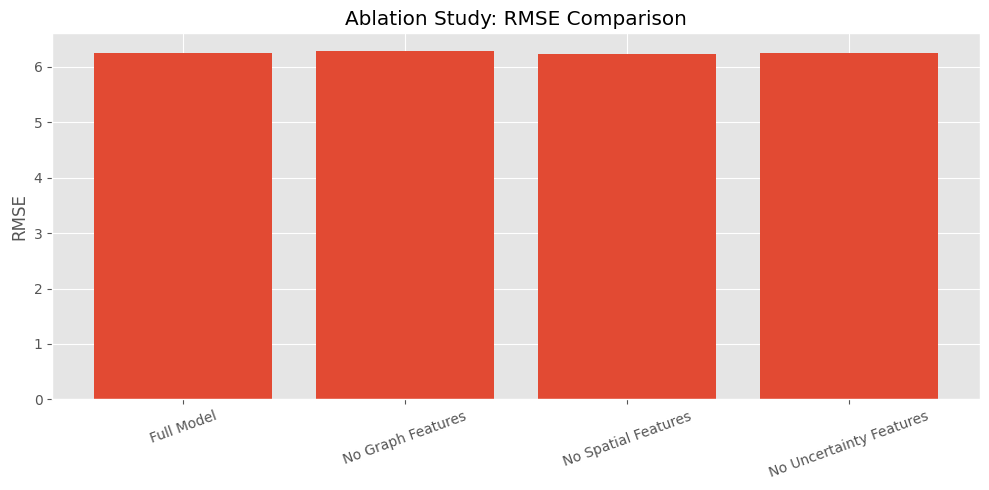

In [122]:
# STEP 9 — VISUALIZE ABLATION IMPACT
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ablation_results_df['model'], ablation_results_df['rmse'])
ax.set_title('Ablation Study: RMSE Comparison')
ax.set_ylabel('RMSE')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [123]:
# STEP 10 — SAVE ABLATION OUTPUTS
ablation_results_df.to_csv(OUTPUT_DIR / 'ablation_results.csv', index=False)

print("Ablation study saved.")

Ablation study saved.


In [124]:
# STEP 1 — MASTER RESULTS TABLE

# Extract variables from summary_metrics
pricing_efficiency_score = summary_metrics['pricing_efficiency_score']
mean_wait_proxy = summary_metrics['mean_wait_time_proxy']
response_strength = summary_metrics['response_strength']

final_results = pd.DataFrame(
    [
        {
            'stage': 'Forecasting',
            'metric': 'MAE',
            'value': full_result['mae']
        },
        {
            'stage': 'Forecasting',
            'metric': 'RMSE',
            'value': full_result['rmse']
        },
        {
            'stage': 'Forecasting',
            'metric': 'R2',
            'value': full_result['r2']
        },
        {
            'stage': 'Forecasting',
            'metric': 'MAPE',
            'value': full_result['mape']
        },
        {
            'stage': 'Tariffing',
            'metric': 'Revenue Gain %',
            'value': revenue_gain_pct
        },
        {
            'stage': 'Tariffing',
            'metric': 'Pricing Efficiency Score',
            'value': pricing_efficiency_score
        },
        {
            'stage': 'Monitoring',
            'metric': 'Mean Waiting-Time Proxy',
            'value': mean_wait_proxy
        },
        {
            'stage': 'Monitoring',
            'metric': 'Avg Abs Price Change %',
            'value': response_strength
        },
        {
            'stage': 'Monitoring',
            'metric': 'Mean Health Score',
            'value': eval_df['health_score'].mean()
        }
    ]
)

display(final_results)

,stage,metric,value
0,Forecasting,MAE,1.576250
1,Forecasting,RMSE,6.248115
2,Forecasting,R2,0.996496
3,Forecasting,MAPE,3.390558
4,Tariffing,Revenue Gain %,14.766325
5,Tariffing,Pricing Efficiency Score,1.165731
6,Monitoring,Mean Waiting-Time Proxy,0.152688
7,Monitoring,Avg Abs Price Change %,24.864326
8,Monitoring,Mean Health Score,0.172207


In [125]:
# STEP 2 — EXECUTIVE SUMMARY TABLE

executive_summary = pd.DataFrame([{
    'forecast_model': 'XGBoost Ensemble',
    'forecast_mae': full_result['mae'],
    'forecast_rmse': full_result['rmse'],
    'forecast_r2': full_result['r2'],
    'revenue_gain_pct': revenue_gain_pct,
    'pricing_efficiency_score': pricing_efficiency_score,
    'mean_waiting_time_proxy': mean_wait_proxy,
    'mean_health_score': eval_df['health_score'].mean(),
    'full_model_ablation_gain_rmse_vs_no_graph': no_graph_result['rmse'] - full_result['rmse'],
    'full_model_ablation_gain_rmse_vs_no_spatial': no_spatial_result['rmse'] - full_result['rmse'],
    'full_model_ablation_gain_rmse_vs_no_uncertainty': no_uncertainty_result['rmse'] - full_result['rmse']
}])

display(executive_summary)

,forecast_model,forecast_mae,forecast_rmse,forecast_r2,revenue_gain_pct,pricing_efficiency_score,mean_waiting_time_proxy,mean_health_score,full_model_ablation_gain_rmse_vs_no_graph,full_model_ablation_gain_rmse_vs_no_spatial,full_model_ablation_gain_rmse_vs_no_uncertainty
0,XGBoost Ensemble,1.57625,6.248115,0.996496,14.766325,1.165731,0.152688,0.172207,0.037484,-0.026724,0.0


In [126]:
# STEP 3 — SAVE SUMMARY OUTPUTS

final_results.to_csv(OUTPUT_DIR / 'final_results_table.csv', index=False)
executive_summary.to_csv(OUTPUT_DIR / 'executive_summary.csv', index=False)

print("Final summary tables saved.")

Final summary tables saved.


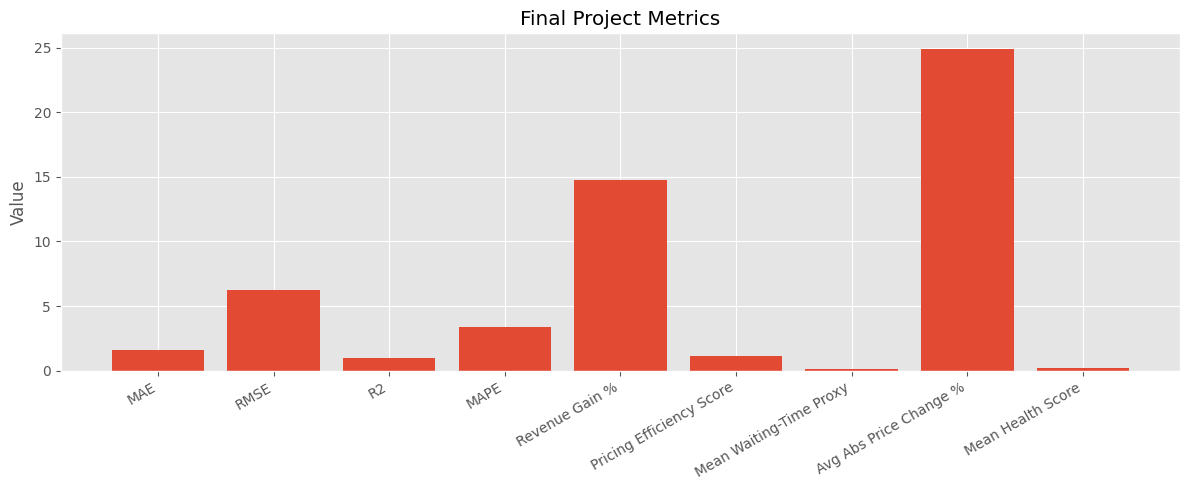

In [127]:
# STEP 4 — RESULTS VISUALIZATION

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(final_results['metric'], final_results['value'])
ax.set_title('Final Project Metrics')
ax.set_ylabel('Value')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [128]:
# STEP 5 — SAVE FINAL DATASET

final_decision_df.to_csv(OUTPUT_DIR / 'final_project_dataset.csv', index=False)
print("Final dataset saved.")

Final dataset saved.


In [159]:
project_summary_text = """
Project completed:
1. Built a unified spatio-temporal EV charging dataset
2. Added temporal, lag, rolling, congestion, spatial, and graph features
3. Trained forecasting models and ensemble
4. Created uncertainty-aware demand prediction
5. Built dynamic tariff optimization logic
6. Built multi-agent decision system
7. Evaluated revenue gain, utilization, waiting-time proxy, and pricing efficiency
8. Ran ablation studies to show graph/spatial/uncertainty features help
"""
print(project_summary_text)


Project completed:
1. Built a unified spatio-temporal EV charging dataset
2. Added temporal, lag, rolling, congestion, spatial, and graph features
3. Trained forecasting models and ensemble
4. Created uncertainty-aware demand prediction
5. Built dynamic tariff optimization logic
6. Built multi-agent decision system
7. Evaluated revenue gain, utilization, waiting-time proxy, and pricing efficiency
8. Ran ablation studies to show graph/spatial/uncertainty features help

